In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from fermion_tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import digamma
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

BOUNDARY_COND = 'PBC'
base_dir = "../results/" + BOUNDARY_COND + '/'

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Fermions/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/


In [2]:
def NonGaussianity(x, m=4, ens=1, filling=0.5):
    Hn = - filling * np.log(filling) - (1-filling) * np.log(1-filling)
    y = 0
    if ens:
        for k in range(1, m+1):
            val = gamma_fun(2*k - 1) / gamma_fun(k + 1)
            for s in range(k, 2*k):
                # print(k, s)
                val = val / (s + x)
            y += val
        return Hn - (np.log(2) - y)
    else:
        y = 3 / 2 / (x + 2)
        if m > 1: y += 3/12 * (9*x + 26) / ( (x+2)*(x+4)*(x+6) )
        if m > 2: y += 135/30 * (3*x**2 + 26*x + 48) / ( (x+2)*(x+4)*(x+6)*(x+8)*(x+10) )
        if m > 3: y += 9/56 * (945*x**3 + 1701*x**2+11705*x+210874) / ( (x+2)*(x+4)*(x+6)*(x+8)*(x+10)*(x+12)*(x+14) )
        return Hn - (np.log(2) - y)


In [3]:

def FF_terms(f, x, n):
    if n == 1:  return 2/(1+x) * f
    if n == 2:  return (8/3 * f**2 - 3*f**3) * 4*(5+x) / ( (1+x)*(2+x)*(3+x) ) + 12/( (2+x)*(3+x) ) * f**3
    if n == 3:  return ( (11*f**3 - 36*f**4 + 30*f**5) * 8*(x**2 + 15*x + 74) + (12*f**4 - 15*f**5) * 24*(x + 14)*(x + 1) + f**5 * 120*(x+1)*(x+2)) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) )
    if n == 4:  
        res = 908/15  * 16*(x**3 + 30*x**2 + 371*x + 2118)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**4\
                    -   1296/5  * 24*(x + 9)                            / ( (1+x)*(3+x)*(4+x)*(5+x) )                   * f**5\
                    +   5816/63 * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**6\
                    +   1024/3  * 240*(x + 13)                          / ( (1+x)*(4+x)*(5+x)*(x+6)*(x+7) )             * f**6\
                    -   272     * 1680                                  / ( (4+x)*(5+x)*(x+6)*(x+7) )                   * f**7
        if f >= 1/4 and f < 1/3:    res += (8192/315*f**6 - 2048/45*f**5 + 512/15*f**4 - 128/9*f**3 + 32/9*f**2 - 8/15*f + 2/45 - 1/(630*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)   / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) 
        if f >= 1/3 and f <= 1/2:   res += (12136/63*f**6 - 13712/45*f**5 + 556/3*f**4 - 452/9*f**3 + 32/9*f**2 + 16/15*f - 2/9 + 1/(90*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) )
        return res
    else:       return 0

def correction(n=4):
    return np.log(2) - np.sum( [1 / (2 * k * (2 * k - 1)) for k in range(1, n)] )

def leading_FF_terms(f, x, n=4):

    res = FF_terms(f=f, x=x, n=1) / 2
    if n >= 2:  res += FF_terms(f=f, x=x, n=2) / 12
    if n >= 3:  res += FF_terms(f=f, x=x, n=3) / 30
    if n >= 4:  res += FF_terms(f=f, x=x, n=4) / 56
    return res

def FF_upper_bound(f, x, n):
    return 1 - leading_FF_terms(f, x, n=n) / (np.log(2))

def FF_lower_bound(f, x, n):
    return 1 - (leading_FF_terms(f=f, x=x, n=n) + FF_terms(f=f, x=x, n=n) * correction(n=n+1)) / (np.log(2))


In [ ]:
## 

## PBC

[3432] 3432.0
[11250] 12870.0
[48620] 48620.0
[166252] 184756.0
[705432] 705432.0
[2478716] 2704156.0
[10400600] 10400600.0


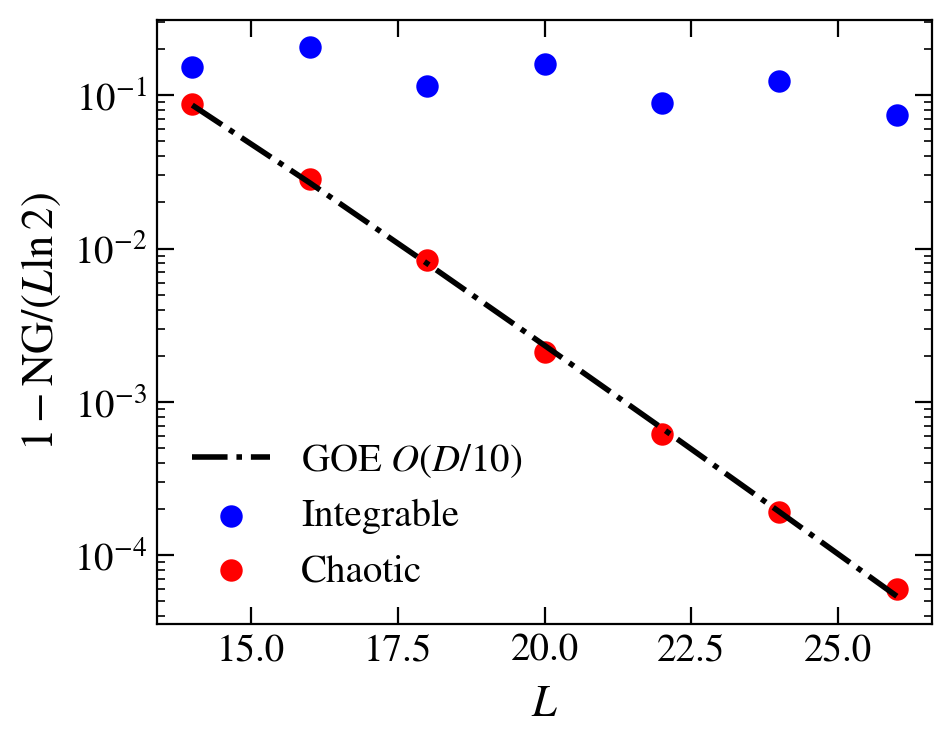

In [7]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200, sharey=True)

nx = 1/2

for iin, n in enumerate( [nx] ):
    f = 1
    sizes = np.arange(14, 27, 2) if n == 1/2 else np.arange(15, 29, 3)


    NonGauss_int = np.zeros(sizes.shape)
    NonGauss_ch = np.zeros(sizes.shape)
    dims = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        
        real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
        
        dim_tot = 0
        dim_tot2 = 0
        for [ks, ps, zxs] in real_sec+imag_sec:
        # for [ks, ps, zxs] in real_sec:
        # for [ks, ps, zxs] in [ [1,1,1] ]:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            V1 = 1.1
            V2 = 0
            t2 = 0
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    try:
                        dim = np.array(file.get('D')[0])
                    except TypeError:
                        dim = Ex.size
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    dims[iiL] = dim
                    if x.size > 0:
                        a=1
                        # print(L, ks, ps)
                    else:
                        NG = np.array(file.get('Non-Gaussianity')[0]) / (L * np.log(2))
                        NonGauss_int[iiL] += dim * factor * np.mean(NG)
                        dim_tot += factor * dim
            else:
                print(name)
            
            V1 = 0.55
            V2 = 2
            t2 = 2
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    try:
                        dim = np.array(file.get('D')[0])
                    except TypeError:
                        dim = Ex.size
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        # print(L, ks, ps)
                    else:
                        NG = np.array(file.get('Non-Gaussianity')[0]) / (L * np.log(2))
                        NonGauss_ch[iiL] += dim * factor * np.mean(NG)
                        # NonGauss_ch[iiL] += factor * np.mean(NG)
                        dim_tot2 += factor * dim
            else:
                print(name)
        NonGauss_int[iiL] /= dim_tot
        NonGauss_ch[iiL] /= dim_tot2
        print(dim_tot, binom(L, N))
    axis.scatter(sizes, 1 - NonGauss_int, s=50, label='Integrable', color='blue', marker='s' if iin else 'o', facecolor='None' if iin else 'blue')
    axis.scatter(sizes, 1 - NonGauss_ch,  s=50, label='Chaotic'   , color='red',  marker='s' if iin else 'o', facecolor='None' if iin else 'red')

# print(1 - NonGauss_ch)

# z = np.linspace(0.001, 0.1, 1000)
# z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
# axis.plot(z, 1-NonGaussianity(0.4/z, n=10, ens=1), ls='--', color='gray', lw=2)
# axis.plot(z, 1-NonGaussianity(1/3/z, n=20, ens=1), ls='--', color='gray', lw=2, label=r"GUE $O(L/2)$")
axis.plot(sizes, 1 - NonGaussianity( dims/10, n=4, ens=0), ls='-.', color='k', lw=2, label=r"GOE $O(D/10)$")
# axis.plot(sizes, 1 - NonGaussianity( dims/16, n=4, ens=1), ls='--', color='green', lw=2, label=r"GUE $O(D/16)$")
# axis.plot(z, 1-NonGaussianity(0.1 * 2**(1/z), n=2, ens=0), ls=':', color='red', lw=2)

# axis.axhline(y = 1-NonGaussianity(22, n=3, ens=0), ls='--', color='gray')
fig_help.set_plot_elements(axis, ylabel=r"$1-{\rm NG}/(L\ln{2})$", xlabel=r"$L$", font_size=14, set_legend=True, xscale='linear', yscale='log')
axis.set_ylim(0, None)

# print(0.08186246*9, 0.08186246*27, 0.08186246*11)

fig.savefig("plots_mixing/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

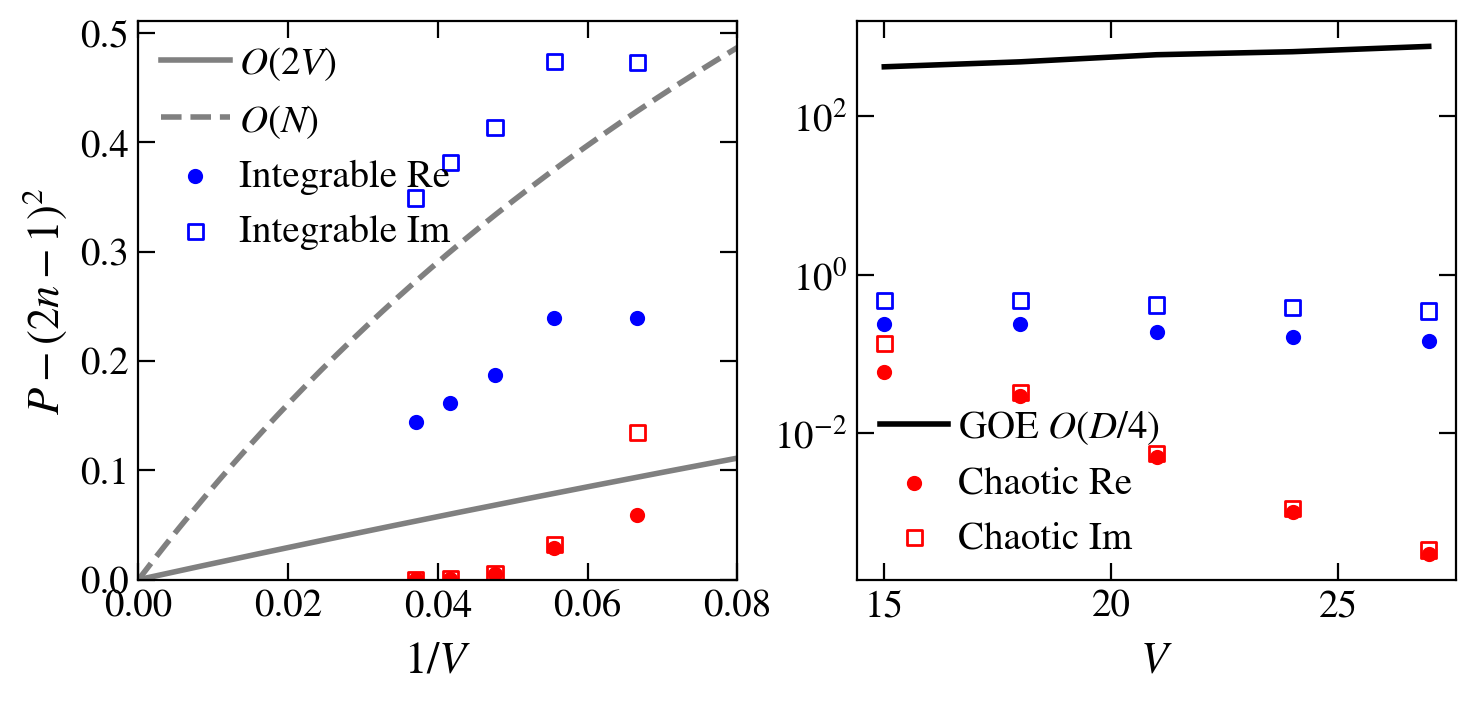

In [148]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)

n = 1/3
f = 1
sizes = np.arange(14, 27, 2) if n == 1/2 else np.arange(15, 28, 3)

Purity_int_re = np.zeros(sizes.shape)
Purity_int_im = np.zeros(sizes.shape)
Purity_int_tot = np.zeros(sizes.shape)

Purity_ch_re = np.zeros(sizes.shape)
Purity_ch_im = np.zeros(sizes.shape)

Chaotic_GOE = np.zeros(sizes.shape)
Chaotic_GUE = np.zeros(sizes.shape)
dims = np.zeros(sizes.shape)
for iiL, L in enumerate(sizes):
    subsystem = np.arange(0, L, 1)
    N = int(n * L)
    LA = int(f * L) if f > 0 else 1
    idx = np.argmin( np.abs(subsystem - LA) )
    if LA == L: idx = -1
    real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
    
    dim_tot = 0
    dim_tot_im = 0
    dim_tot_ch = 0
    dim_tot_ch_im = 0
    for [ks, ps, zxs] in real_sec + imag_sec:
    # for [ks, ps, zxs] in imag_sec:
    # for [ks, ps, zxs] in [[0, 1, 1], [1, 1, 1]]:
        # if ks == L / 4: print("Omitting k=\pi/2 sector"); continue;
    # for [ks, ps, zxs] in [[1, 1, 1]]:
        factor = 1 if ks == 0 or ks == L / 2 else 2
        # print(L, ks, ps, factor)
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                x = counts[counts > 1]
                try:
                    dim = np.array(file.get('D')[0])
                except TypeError:
                    dim = Ex.size
                    
                if x.size > 0:
                    a=1
                    print(L, V2, ks, ps)#, x, Ex[indices[counts > 1]])
                else:
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    # print(L, ks, ps, np.mean(ratio_tmp))
                    # dim = Ex.size
                    P = np.array(file.get('Purity')[idx, :]) / LA - (2 * n - 1)**2
                    
                    if factor == 1:
                        Purity_int_re[iiL] += dim * factor * np.mean(P)
                        # print(L, ks, ps, dim, np.mean(P))
                        dim_tot += factor * dim
                    else:
                        Purity_int_im[iiL] += dim * factor * np.mean(P)
                        dim_tot_im += factor * dim
                        
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                x = counts[counts > 1]
                
                try:
                    dim = np.array(file.get('D')[0])
                    # print(L, ks, ps, dim)
                except TypeError:
                    dim = Ex.size
                dims[iiL] = dim
                
                if x.size > 0:
                    a=1
                    print(L, V2, ks, ps, Ex[indices[counts > 1]])
                else:
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    # print(L, ks, ps, np.mean(ratio_tmp))
                    # dim = Ex.size
                    P = np.array(file.get('Purity')[idx, :]) / LA - (2 * n - 1)**2
                    # axis[1].scatter(L, np.mean(P), marker='v', color='red', alpha=0.2)
                    
                    Chaotic_GOE[iiL] += dim * factor * 9 / (2 + dim/3)
                    if factor == 1:
                        Purity_ch_re[iiL] += dim * factor * np.mean(P)
                        dim_tot_ch += factor * dim
                    else:
                        Purity_ch_im[iiL] += dim * factor * np.mean(P)
                        Chaotic_GUE[iiL] += dim * factor
                        dim_tot_ch_im += factor * dim
        else:
            print(name)
    Purity_int_tot[iiL] = (Purity_int_re[iiL] + Purity_int_im[iiL]) / (dim_tot + dim_tot_im)
    
    if dim_tot > 0: Purity_int_re[iiL] /= dim_tot
    if dim_tot_im > 0: Purity_int_im[iiL] /= dim_tot_im
    if dim_tot_ch > 0: Purity_ch_re[iiL] /= dim_tot_ch
    if dim_tot_ch_im > 0: Purity_ch_im[iiL] /= dim_tot_ch_im
    # Purity_ch_tot[iiL] = (Purity_ch_re[iiL] + Purity_ch_im[iiL]) / (dim_tot + dim_tot_im)

axis[0].scatter(1/sizes, Purity_int_re, s=20, label='Integrable Re', color='blue')
axis[1].scatter(sizes, Purity_int_re, s=20, color='blue')

axis[0].scatter(1/sizes, Purity_ch_re, s=20, color='red')
# axis[1].scatter(sizes, Purity_ch_re, s=20, label='Chaotic Re', color='red')
axis[1].scatter(sizes, Purity_ch_re, s=20, label='Chaotic Re', color='red')

axis[0].scatter(1/sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None', label='Integrable Im')
axis[1].scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')

axis[0].scatter(1/sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')
# axis[1].scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None', label='Chaotic Im')
axis[1].scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None', label='Chaotic Im')

z = np.linspace(0, 0.08, 1000)
axis[0].plot(z, 3 / (2 + 2/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
# axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
axis[0].plot(z, 3 / (2 + n/z), ls='--', lw=2, color='gray', label=r"$O(N)$")
# axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
# axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
# def fit_purity(x: float, a: int, b: int):
#     return 9 / (2 + b * x)

# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = sizes[1:],
#                         ydata = Purity_int_im[1:],
#                         full_output=True, maxfev=10000)
# print("Imag", *pars)
# xx = np.linspace(0, max(1/sizes), 10000)
# axis[0].plot( xx, fit_purity(1/xx, *pars), ls='-',  color = 'blue')


# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = sizes[1:],
#                         ydata = Purity_int_re[1:],
#                         full_output=True, maxfev=10000)
# print("Real", *pars)
# axis[0].plot( xx, fit_purity(1/xx, *pars), ls='-.',  color = 'blue')

# xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = 2**sizes[1:],
#                         ydata = Purity_ch_re[1:],
#                         full_output=True, maxfev=10000)
# print(*pars)
# xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
# axis[1].plot(xx, fit_purity(2**xx, *pars), ls='-',  color = 'red')

axis[1].plot(sizes, Chaotic_GOE, ls='-', lw=2, color='k', label=r"GOE $O(D/4)$")
# axis[1].plot(sizes, Chaotic_GUE, ls=':',  lw=2, color='green', label=r"GUE $O(D/4)$")

fig_help.set_plot_elements(axis[0], ylabel=r"$P-(2n-1)^2$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.08), xscale='linear', yscale='linear')
fig_help.set_legend(axis[0], fontsize=14, loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, anchor=(-0.02, 1.02))
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$V$", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_legend(axis[1], fontsize=14, loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, anchor=(-0.02, -0.02))
axis[0].set_ylim(0, None)
fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

14 113
14 133
14 133
14 113
14 245
14 245
14 245
14 245
14 245
14 245
18 1317
18 1387
18 1387
18 1317
18 2700
18 2700
18 2703
18 2700
18 2700
18 2703
18 2700
18 2700
22 15907
22 16159
22 16159
22 15907
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
15 90
15 111
15 200
15 200
15 200
15 200
15 201
15 200
15 200
18 486
18 542
18 505
18 533
18 1035
18 1026
18 1038
18 1026
18 1035
18 1028
18 1035
18 1026
21 2709
21 2829
21 5537
21 5537
21 5537
21 5537
21 5537
21 5537
21 5538
21 5537
21 5537
21 5537
24 15168
24 15498
24 15251
24 15416
24 30624
24 30664
24 30624
24 30667
24 30624
Omitting k=\pi/2 sector
24 30624
24 30666
24 30624
24 30664
24 30624
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500


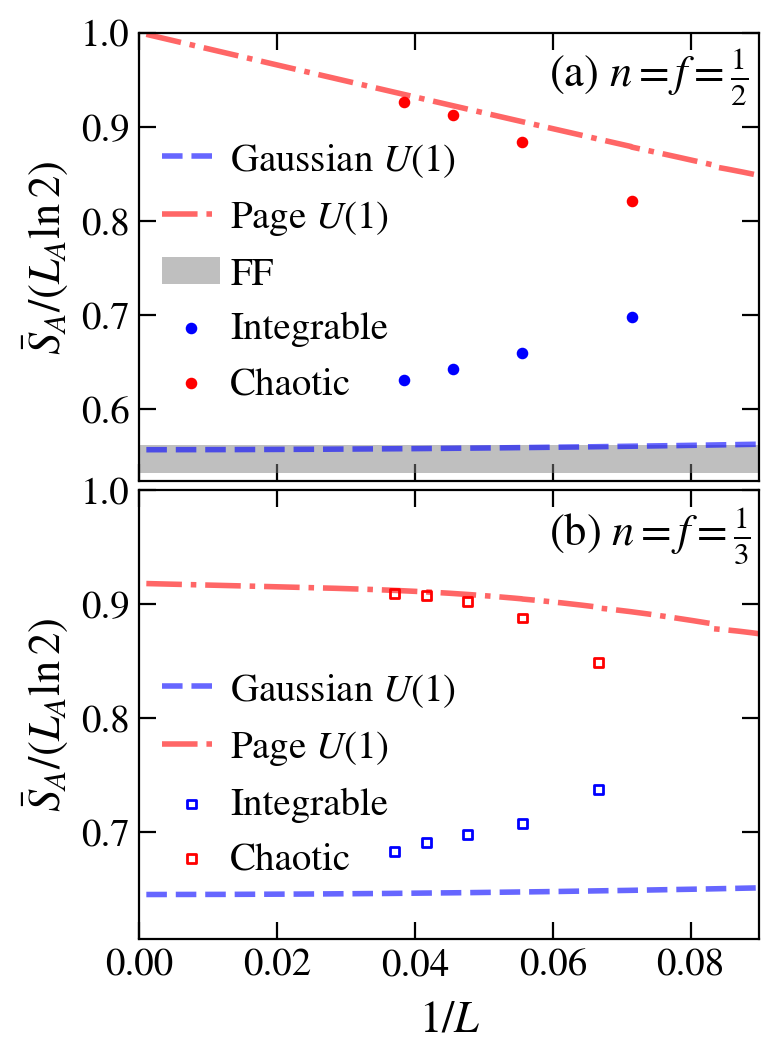

In [38]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True)

n = 1/2
for iin, n in enumerate([1/2, 1/3]):
    sizes = np.arange(14, 27, 4) if n == 1/2 else np.arange(15, 29, 3)


    Svn_int = np.zeros(sizes.shape)
    Svn_ch = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
        
        dim_tot = 0
        dim_tot2 = 0
        for [ks, ps, zxs] in real_sec+imag_sec:
        # for [ks, ps, zxs] in imag_sec:
        # for [ks, ps, zxs] in real_sec:
            if ks == L / 4: print("Omitting k=\pi/2 sector"); continue;
        # for [ks, ps, zxs] in [[1, 1, 1]]:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            # print(L, ks, ps, factor)
            V2 = 0
            t2 = 0
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        print(L, ks, ps)
                    else:
                        dim = Ex.size
                        print(L, dim)
                        Svn = np.array(file.get('entropy')[idx, :]) / (LA * np.log(2))
                        Svn_int[iiL] += dim * factor * np.mean(Svn[Svn.size//2-5 : Svn.size//2+5])
                        # Svn_int[iiL] += dim * factor * np.mean(Svn)
                        dim_tot += factor * dim                        
            else:
                print(name)
                
            V2 = 2
            t2 = 2
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        print(L, ks, ps)
                    else:
                        Svn = np.array(file.get('entropy')[idx, :]) / (LA * np.log(2))
                        Svn_ch[iiL] += dim * factor * np.mean(Svn[Svn.size//2-5 : Svn.size//2+5])
                        # Svn_ch[iiL] += dim * factor * np.mean(Svn)
                        dim_tot2 += factor * dim  
            else:
                print(name)
        Svn_ch[iiL] /= dim_tot2
        Svn_int[iiL] /= dim_tot
        # print(dim_tot, binom(L, N))
    axis[iin].scatter(1/sizes, Svn_int, s=10, label='Integrable', color='blue', marker='s' if iin else 'o', facecolor='None' if iin else 'blue')
    # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')

    p = axis[iin].scatter(1/sizes, Svn_ch, s=10, label='Chaotic', color='red', marker='s' if iin else 'o', facecolor='None' if iin else 'red')
    # axis.scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')

    z = np.linspace(1e-3, 0.1, 1000)
    Lz = 1/z
    yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * np.log(2))
    axis[iin].plot(z, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $U(1)$")
    axis[iin].plot(z, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * np.log(2)) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$")

    fig_help.set_plot_elements(axis[iin], ylabel=r"$\bar{S}_A/(L_A\ln{2})$", xlabel=r"$1/L$" if iin else "", font_size=14, set_legend=True, xlim=(0,0.09), ylim=(0.94 * min(yy[~np.isnan(yy)]), 1), xscale='linear', yscale='linear')

axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")

fig_help.set_legend(axis[0], fontsize=14, loc='lower left', ncol=1, anchor=(-0.02, 0.1))
fig_help.set_legend(axis[1], fontsize=14, loc='lower left', ncol=1, anchor=(-0.02, 0.06))

axis[0].annotate(r"(a) $n=f=\frac{1}{2}$", fontsize=16, xy=(0.66, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b) $n=f=\frac{1}{3}$", fontsize=16, xy=(0.66, 0.88), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

fig.savefig("plots_mixing/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
## CHECK V_1 = 1.1 for integrable case maybe it behaves better

16 4 1
20 5 1


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


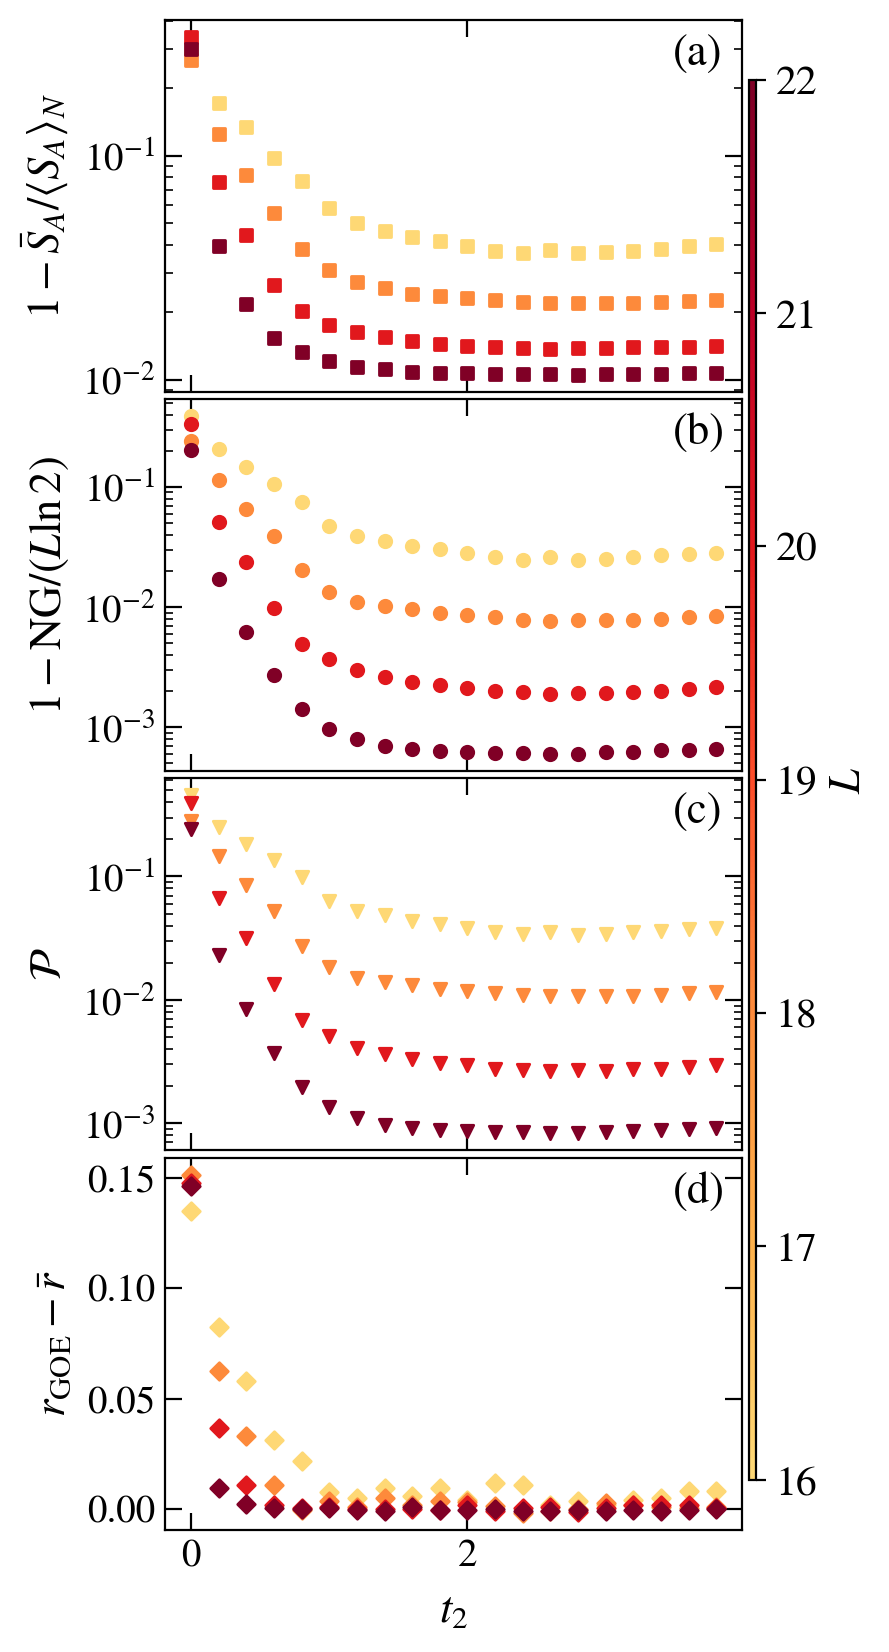

In [73]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=4, ncols=1, figsize=(3.5,10), dpi = 200, sharex=True)
axis = axis.flatten()

L = 20

sizes = np.arange(16, 23, 2)
norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.25, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

for sth in range(0, 1):
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L) if sizes.size > 1 else 'k'
        
        N = L//2
        LA = L//2

        subsystem = np.arange(0, L, 1)
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
                
        t2_vals = np.arange(0.0, 4, 0.2)
        Svn = np.zeros(t2_vals.shape)
        NG = np.zeros(t2_vals.shape)
        P = np.zeros(t2_vals.shape)
        r = np.zeros(t2_vals.shape)
            
        for iit, t2 in enumerate(t2_vals):
            V2 = 0.55*t2 if sth else t2
            real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
            
            dim_tot = 0
            for [ks, ps, zxs] in real_sec + imag_sec:
                factor = 1 if ks == 0 or ks == L / 2 else 2
                name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
                if exists(name):
                    with h5py.File(name, "r") as file:
                        Ex = np.array(file.get('energies')[0])
                        _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                        x = counts[counts > 1]
                        if x.size > 0:
                            a=1
                            print(L, ks, ps)
                        else:
                            Svn[iit] += dim * factor * np.mean(np.array(file.get('entropy')[idx, :])) / ent.page_U1(LA, L - LA, N)
                            NG[iit] += dim * factor * np.mean(np.array(file.get('Non-Gaussianity'))) / (L * np.log(2))
                            P[iit] += dim * factor * np.mean(np.array(file.get('Purity')[-1, :])) / L
                            dim_tot += factor * dim  
                            
                            gaps = np.diff(Ex)
                            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                            r[iit] +=  dim * factor * np.mean(ratio_tmp)
                else:
                    print(name)
            Svn[iit] /= dim_tot
            NG[iit] /= dim_tot
            P[iit] /= dim_tot
            r[iit] /= dim_tot
            
        axis[0].scatter(t2_vals, 1 - Svn,    s=20, color=col, facecolor = 'None' if sth else col, marker='s')
        axis[1].scatter(t2_vals, 1 - NG,     s=20, color=col, facecolor = 'None' if sth else col, marker='o')
        axis[2].scatter(t2_vals, P,          s=20, color=col, facecolor = 'None' if sth else col, marker='v')
        axis[3].scatter(t2_vals, 0.5307 - r, s=20, color=col, facecolor = 'None' if sth else col, marker='D')

fig_help.set_plot_elements(axis[0], ylabel=r"$1-\bar{S}_A/\langle S_A\rangle_N$", xlabel="", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$1-{\rm NG}/(L\ln{2})$", xlabel="", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[2], ylabel=r"$\mathcal{P}$", xlabel=r"$t_2$", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[3], ylabel=r"$r_{\rm GOE}-\bar{r}$", xlabel=r"$t_2$", font_size=14, set_legend=True, xscale='linear', yscale='linear')


axis[0].annotate(r"(a)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')
axis[2].annotate(r"(c)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')
axis[3].annotate(r"(d)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.31, hspace=0.02)
fig.savefig("plots_mixing/FigA1.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [61]:
L=12
N=6
t1=1
t2=0
V1=0.55
V2=0.0
mu=0

BOUNDARY_COND = 'ABC'

name = "../results/" + BOUNDARY_COND + '/' + 'Purity/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energies')[0])
        _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
        x = counts[counts > 1]
        print(x)
        gaps = np.diff(Ex)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        
        print(t1, t2, V1, V2, np.mean(ratio_tmp))
else:
    print(name)
    
t1=1
t2=2
V1=0.55
V2=2.0
mu=0

BOUNDARY_COND = 'ABC'

name = "../results/" + BOUNDARY_COND + '/' + 'Purity/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energies')[0])
        _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
        x = counts[counts > 1]
        print(x)
        gaps = np.diff(Ex)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        
        print(t1, t2, V1, V2, np.mean(ratio_tmp))
else:
    print(name)

[]
1 0 0.55 0.0 0.393123779288074
[]
1 2 0.55 2.0 0.5211244751984949


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


INT 14 0.40505028502067364
CH 14 0.5080680521263767
INT 16 0.39606614773919085
CH 16 0.5268369735378579
INT 18 0.3823900837986789
CH 18 0.5273626952632849
INT 20 0.3834897608470231
CH 20 0.5327077770732468
INT 22 0.38283899797573057
CH 22 0.5310604987490971
INT 24 0.38533421482104585
CH 24 0.5254814112009726


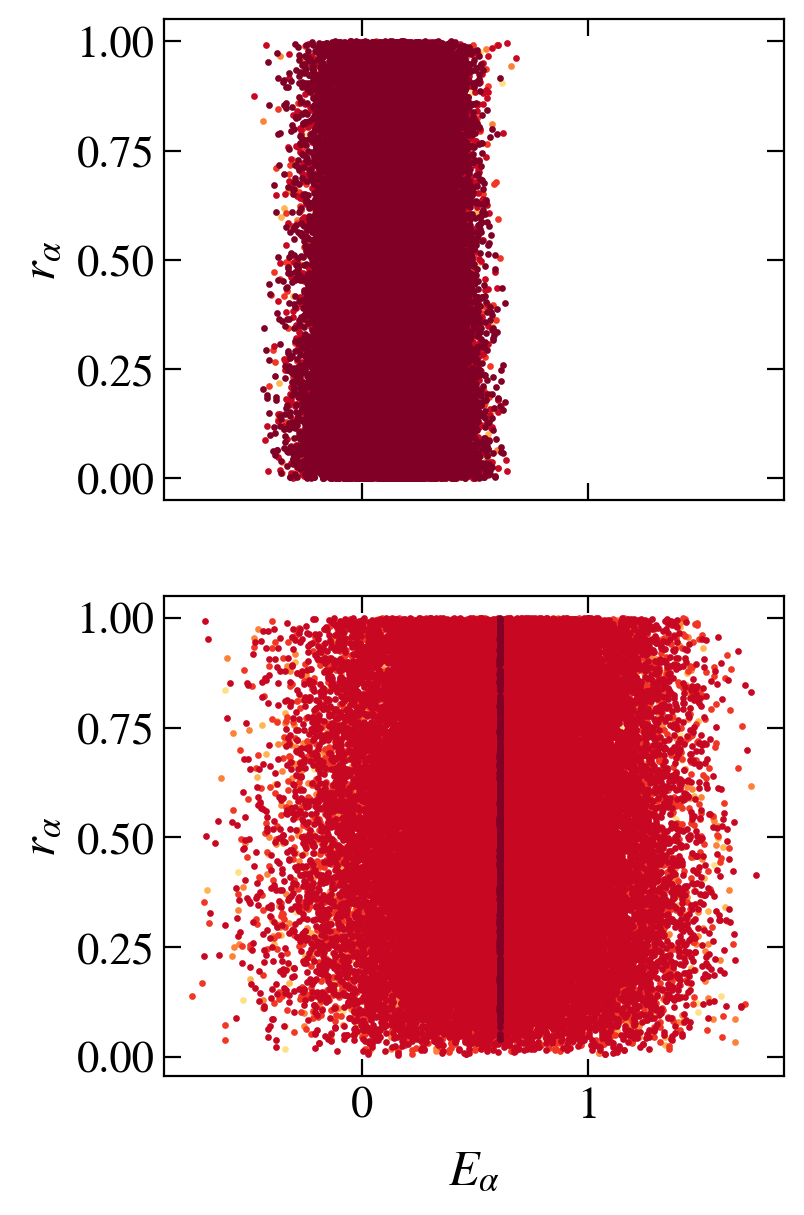

In [60]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,7), dpi = 200, sharex=True)
# ax2 = ax.inset_axes([0.065, 0.04, 0.49, 0.49])
# axis = [ax2, ax]

n = 1/2
f = 1
sizes = np.arange(14, 25, 2) if n == 1/2 else np.arange(14, 27, 3)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

BOUNDARY_COND = 'PBC'

for iiL, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    subsystem = np.arange(0, L, 1)
    N = int(n * L)
    LA = int(f * L) if f > 0 else 1
    idx = np.argmin( np.abs(subsystem - LA) )
    if LA == L: idx = -1
    
    for [ks, ps, zxs] in [[0,1,1]]:
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                axis[0].scatter(Ex[1:-1] / L, ratio_tmp, color=col, s=2)
                print('INT', L, np.mean(ratio_tmp))
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                axis[1].scatter(Ex[1:-1] / L, ratio_tmp, color=col, s=2)
                print('CH', L, np.mean(ratio_tmp))
        else:
            print(name)
    
fig_help.set_plot_elements(axis[0], ylabel=r"$r_\alpha$", xlabel=r"", font_size=16, set_legend=True, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$r_\alpha$", xlabel=r"$E_\alpha$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
fig_help.set_legend(axis[1], fontsize=16, loc = 'upper right', ncol=1, columnspacing=0.4, frameon=False, anchor=(1.02, 0.93))


## ABC

(3.3238633546761215e-06, 0.4034815435449444)

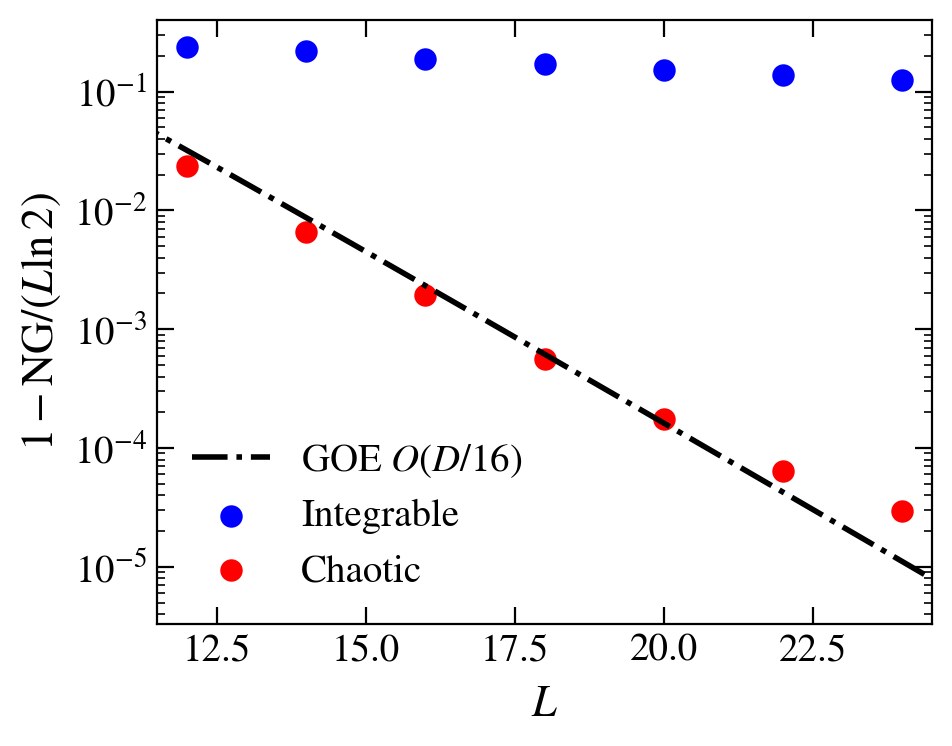

In [143]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200, sharey=True)

nx = 1/2


BOUNDARY_COND = 'ABC'
for iin, n in enumerate( [nx] ):
    f = 1
    sizes = np.arange(12, 25, 2)

    NonGauss_int = np.zeros(sizes.shape);   NonGauss_int.fill(np.nan)
    NonGauss_ch = np.zeros(sizes.shape);    NonGauss_ch.fill(np.nan)
    dims = np.zeros(sizes.shape)
    
    
    Hn = -n * np.log(n) - (1-n) * np.log(1-n)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
    
        V1 = 0.55
        V2 = 0
        t2 = 0
        term1 = n * np.log(n)
        term2 = (1-n) * np.log(1-n)
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = Ex.size
                dims[iiL] = binom(L, N)
                
                E_av = np.mean(Ex)
                idx = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                
                NG = np.array(file.get('Non-Gaussianity')[0]) / (L)
                NonGauss_int[iiL] = -(term1 + term2) - (np.mean(NG) if L > 18 else np.mean(NG[idx - num//2 : idx + num//2]))
        else:
            print(name)
        
        V1 = 0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = Ex.size
                
                E_av = np.mean(Ex)
                idx = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                # NG = np.array(file.get('Non-Gaussianity')[0]) / (L * np.log(2))
                NG = np.array(file.get('Non-Gaussianity')[0]) / (L)
                NonGauss_ch[iiL] = -(term1 + term2) - (np.mean(NG) if L > 18 else np.mean(NG[idx - num//2 : idx + num//2]))
        else:
            print(name)
            
    axis.scatter(sizes, NonGauss_int, s=50, label='Integrable', color='blue', marker='s' if iin else 'o', facecolor='None' if iin else 'blue')
    axis.scatter(sizes, NonGauss_ch,  s=50, label='Chaotic'   , color='red',  marker='s' if iin else 'o', facecolor='None' if iin else 'red')

# print(1 - NonGauss_ch)

# z = np.linspace(0.001, 0.1, 1000)
z = np.linspace(min(sizes)-1, max(sizes)+1, 100)
# print(NonGaussianity(0.4*z, m=4, ens=0))
# axis.plot(z, NonGaussianity(0.4*z, n=4, ens=0), ls='--', color='gray', lw=2)
# axis.plot(z, 1-NonGaussianity(1/3/z, n=20, ens=1), ls='--', color='gray', lw=2, label=r"GUE $O(L/2)$")
axis.plot(z, NonGaussianity( binom(z, z/2)/20, m=4, ens=0), ls='-.', color='k', lw=2, label=r"GOE $O(D/16)$")
# axis.plot(sizes, 1 - NonGaussianity( dims/16, n=4, ens=1), ls='--', color='green', lw=2, label=r"GUE $O(D/16)$")
# axis.plot(z, 1-NonGaussianity(0.1 * 2**(1/z), n=2, ens=0), ls=':', color='red', lw=2)

# axis.axhline(y = 1-NonGaussianity(22, n=3, ens=0), ls='--', color='gray')
fig_help.set_plot_elements(axis, ylabel=r"$1-{\rm NG}/(L\ln{2})$", xlabel=r"$L$", font_size=14, set_legend=True, xscale='linear', yscale='log')
axis.set_xlim(11.5, 24.5)
axis.set_ylim(0, None)

# print(0.08186246*9, 0.08186246*27, 0.08186246*11)

# fig.savefig("plots_mixing/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


Int 1.0 -1.2289553102891138
Ch 1.0 0.09116087656330454
Int 1.0 -0.13663058586350346
Ch 1.0 0.07400562949229379


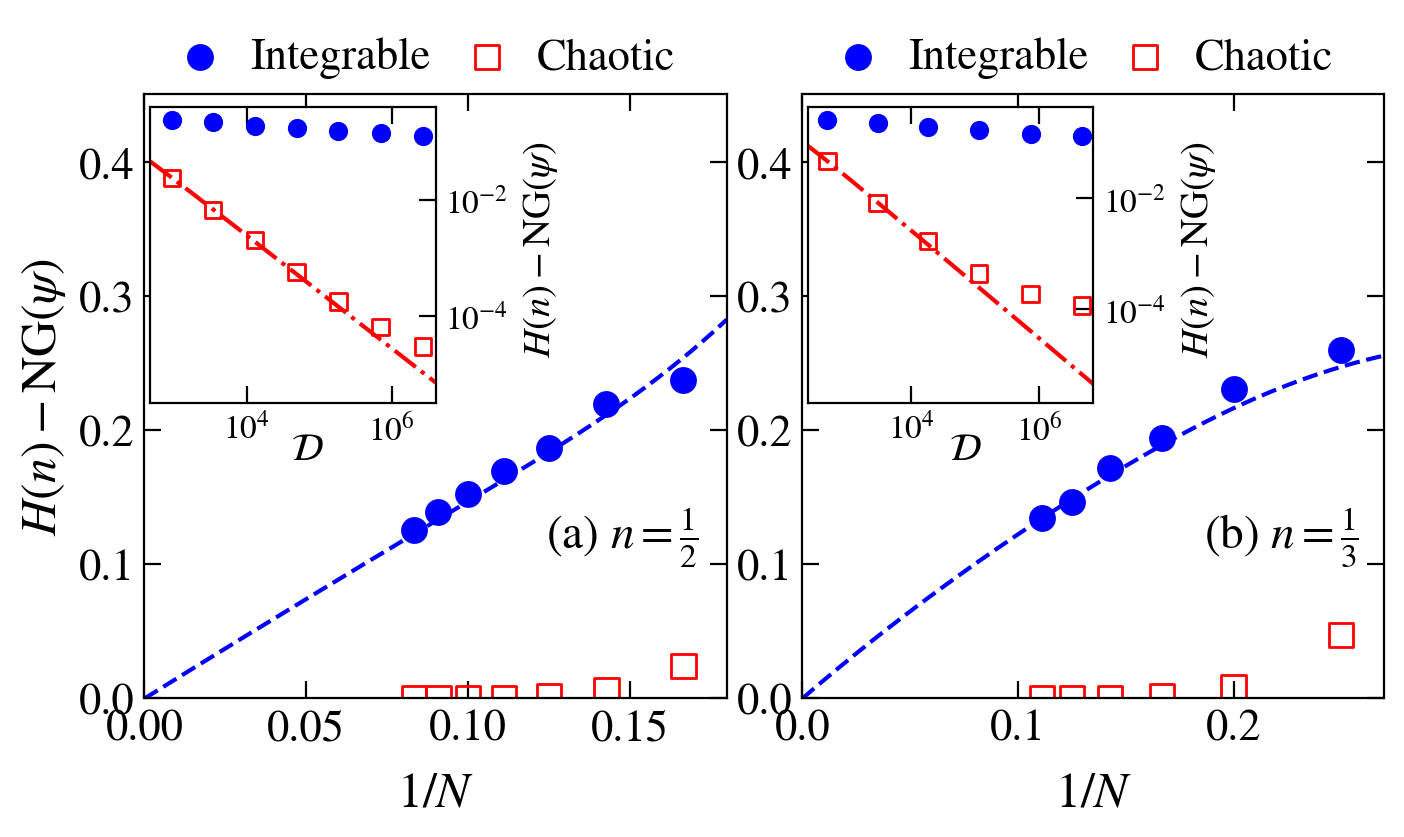

In [213]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=1, ncols=2, figsize=(8,4), dpi = 200, sharex=False)
# ax2 = ax.inset_axes([0.06, 0.04, 0.49, 0.45])
# axis = [ax2, ax]

n = 1/2
f = 1


for iin, n in enumerate([1/2, 1/3]):

    ax2 = axa[iin].inset_axes([0.01, 0.49, 0.49, 0.49])
    axis = [axa[iin], ax2]
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    dims = binom(sizes, n * sizes)
    
    NonGauss_int = np.zeros(sizes.shape);  NonGauss_int.fill(np.nan)
    NonGauss_ch = np.zeros(sizes.shape);   NonGauss_ch.fill(np.nan)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'
    
    term1 = n * np.log(n)
    term2 = (1-n) * np.log(1-n)
    Pinf = (2 * n - 1)**2
    Hn = -(term1 + term2)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
    
        # print("BCD", n, np.log(2) + (term1 + term2))
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = binom(L, N)#Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = int(min([1000, dim//10]))
                
                NG = Hn - np.array(file.get('Non-Gaussianity')[0]) / (L)
                NG = NG if dim > 7e4 else NG[idxE - num//2 : idxE + num//2]
                if NG.size > 1000 and dim > 7e4:
                    # print(idxE, idxE - 250, Ex.size)
                    NG = NG[idxE - 500 : idxE + 500]
                NonGauss_int[iiL] = np.mean(NG)
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = binom(L, N)#Ex.size
                
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = int(min([1000, dim//10]))
                          
                NG = Hn - np.array(file.get('Non-Gaussianity')[0]) / (L)
                NG = NG if dim > 7e4 else NG[idxE - num//2 : idxE + num//2]
                # print(idxE, idxE - 250, NG.size)
                if NG.size > 1000 and dim > 7e4:
                    NG = NG[idxE - 500 : idxE + 500]
                NonGauss_ch[iiL] = np.mean(NG)
        else:
            print(name)

    particle_num = sizes * n
    axis[0].scatter(1/particle_num, NonGauss_int, s=75, color='blue', label='Integrable')
    axis[1].scatter(binom(sizes,particle_num), NonGauss_int, s=35, color='blue')

    axis[0].scatter(1/particle_num, NonGauss_ch, s=75, color='red', marker='s', facecolor='None', label='Chaotic')
    axis[1].scatter(binom(sizes,particle_num), NonGauss_ch, s=35, color='red', marker='s', facecolor='None')

    # aveN = (2*n-1)**2
    
    # def kernel(x):
    #     return x * np.log(x)
    # term1 = kernel( (1 - aveN)/2 )
    # term2 = kernel( (1 + aveN)/2 )
    # print(n, 1 + (term1 + term2) / np.log(2))
    # axis[0].axhline(y = 1 + (term1 + term2) / np.log(2), ls=':', color='gray')
    # axis[1].axhline(y = 1 + (term1 + term2) / np.log(2), ls=':', color='gray')
    
    z = np.linspace(0, 0.1, 1000)
    # axis[0].plot(z, 9 / (2 + 1.5/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
    # # axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # axis[0].plot(z, 9 / (2 + 1/z), ls='--', lw=2, color='gray', label=r"$O(V)$")
    # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
    # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    
    # Purity = (1 - Pinf) * 3 / (x + 2) + L * 4*n*(1-n) / dim * (1 - 3 / (x+2))
    # axis[0].plot(x, np.sqrt(Purity) * np.arctanh(np.sqrt(Purity)) + np.log(1-Purity) / 2, ls='--', color=col)
    
    def fit_purity(x: float, a: int, b: int):
        dim = binom(x, x*n)
        prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * n * x))
        purity = Pinf + 3 * (1 - Pinf) / (2 + b + n * x) + prob 
        return Hn - np.log(2) + (np.sqrt(purity) * np.arctanh(np.sqrt(purity)) + np.log(1-purity) / 2)
    # def fit_purity(x, a, b):
    #     # return NonGaussianity(a * x + b, m=4, ens=1, filling=n)
    #     # return 3 / 2 / np.log(2) / (a * x)# - b / x**2 + c / x**3
    #     return (1 + (a * x - 1) * np.log(1 - 2 / (a*x + 1)) / 2) / np.log(2)

    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = sizes,
                            ydata = NonGauss_int,
                            full_output=True, maxfev=10000)
    print("Int", *pars)
    xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[0].plot( xx / n, fit_purity(1/xx, *pars), ls='--',  color = 'blue')

    def fit_purity(x: float, a: int, b: int):
        dim = binom(x, x*n)
        prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * dim))
        purity = Pinf + 3 * (1 - Pinf) / (2 + b * dim) + prob 
        return Hn - np.log(2) + np.sqrt(purity) * np.arctanh(np.sqrt(purity)) + np.log(1-purity) / 2

    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = sizes,
                            ydata = NonGauss_ch,
                            full_output=True, maxfev=10000)
    print("Ch", *pars)
    xx = np.linspace(min(sizes)-3, max(sizes)+1, 10000)
    # xx = binom(xx, xx*n)
    axis[1].plot(binom(xx, xx*n), fit_purity(xx, *pars), ls='-.',  color = 'red')

    fig_help.set_plot_elements(axis[0], ylabel=r"$H(n)-{\rm NG}(\psi)$" if iin==0 else "", xlabel=r"$1/N$", font_size=16, set_legend=True, xlim=(0, 0.09/n), xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[1], ylabel=r"$H(n)-{\rm NG}(\psi)$", xlabel=r"$\mathcal{D}$", font_size=12, set_legend=True, xscale='log', yscale='log')
    # fig_help.set_legend(axis[1], fontsize=14, loc = 'upper right', ncol=1, columnspacing=0.4, frameon=True, anchor=(1.02, 0.93))
    fig_help.set_legend(axis[0], fontsize=16, loc = 'lower left', ncol=2, columnspacing=0.4, frameon=False, anchor=(-.04, 0.96))
    
    axis[0].set_ylim(0, 0.45)
    # axis[1].set_ylim(5e-9, None)
    axis[1].set_xlim(min(dims)/2, max(dims)*1.5)


    # axis[1].xaxis.set_label_position("top")
    # axis[1].xaxis.tick_top()
    axis[1].yaxis.set_label_position("right")
    axis[1].yaxis.tick_right()
    axis[1].xaxis.set_label_coords(.55, -0.1)
    axis[1].yaxis.set_label_coords(1.3, .52)

fig.subplots_adjust(wspace = 0.13, hspace=0.02)
axa[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
axa[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
fig.savefig("plots_mixing/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


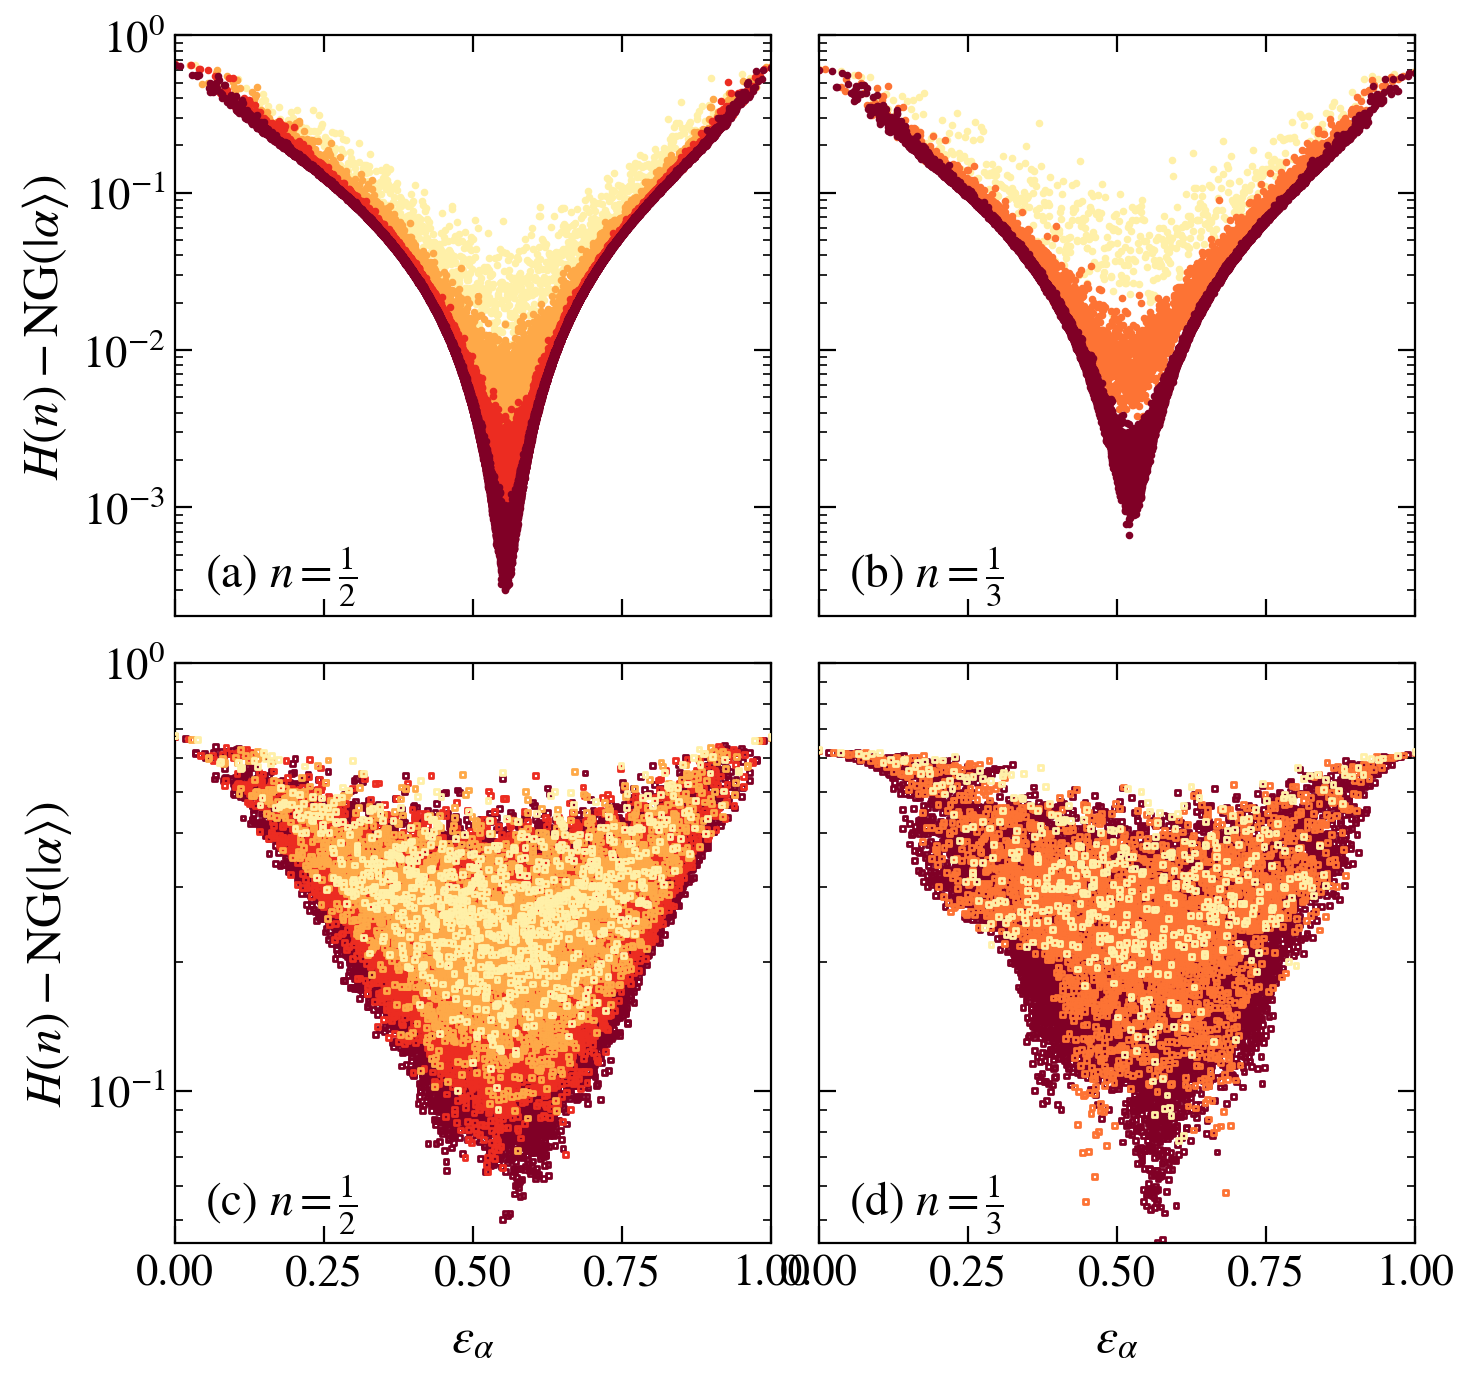

In [163]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

LOG = 1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=2, ncols=2, figsize=(8,8), dpi = 200, sharex=True, sharey='row')

for iin, n in enumerate([1/2, 1/3]):
    axis = axa[0][iin]
    axis2 = axa[1][iin]

    f = 1
    sizes = np.arange(12, 19, 2) if n == 1/2 else np.arange(12, 20, 3)
    norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes))


    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

    s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m_L.set_array([])
    BOUNDARY_COND = 'ABC'


    term1 = n * np.log(n)
    term2 = (1-n) * np.log(1-n)
    
    Hn = - term1 - term2
    for iiL, L in enumerate(sizes):
        col = s_m_L.to_rgba(L)
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        t2 = 2
        V2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Ex = (Ex - np.mean(Ex))
                Ex = Ex / np.std(Ex)
                Ex = (Ex - Ex[0]) / (Ex[-1] - Ex[0])
                NG = np.array(file.get('Non-Gaussianity'))[idx] / L# - (2 * n - 1)**2
                if LOG: NG = Hn - NG
                else:   NG = NG / Hn
                axis.scatter(Ex, NG, color = col, s=3, rasterized=True)
                
        else:
            print(name)
        V1=0.55
        V2 = 0
        t2 = 0
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Ex = (Ex - np.mean(Ex))
                Ex = Ex / np.std(Ex)
                Ex = (Ex - Ex[0]) / (Ex[-1] - Ex[0])
                NG = np.array(file.get('Non-Gaussianity'))[idx] / L# - (2 * n - 1)**2
                if LOG: NG = Hn - NG
                else:   NG = NG / Hn
                axis2.scatter(Ex, NG, color = col, s=3, rasterized=True, marker='s', facecolor='None', zorder = sizes[-1] - L)
        else:
            print(name)
    
    ylab = r"$H(n) - {\rm NG}(|\alpha\rangle)$" if LOG else r"${\rm NG}(|\alpha\rangle)/(VH(n))$"
    fig_help.set_plot_elements(axis, ylabel="" if iin else ylab, xlabel=r"", font_size=16, set_legend=True, xscale='linear', yscale='log' if LOG else 'linear')
    axis.set_xlim(0, 1)
    axis.set_ylim(None, 1)
    fig_help.set_plot_elements(axis2, ylabel="" if iin else ylab, xlabel=r"$\epsilon_\alpha$", font_size=16, set_legend=True, xscale='linear', yscale='log' if LOG else 'linear')
    axis2.set_xlim(0, 1)
    axis2.set_ylim(None, 1)

    # if iin: 
    #     z = np.linspace(0, 1,1000)
    #     # axis.plot(z, (2*z - 1)**2, color='blue', ls='--', lw=2)
    #     # axis2.plot(z, (2*z - 1)**2, color='blue', ls='--', lw=2)
    #     axis.axhline(y=(2*n-1)**2, ls='--', color='k')
    #     axis2.axhline(y=(2*n-1)**2, ls='--', color='k')
axa[0][0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
axa[0][1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
axa[1][0].annotate(r"(c) $n=\frac{1}{2}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
axa[1][1].annotate(r"(d) $n=\frac{1}{3}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.08, hspace=0.08)
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


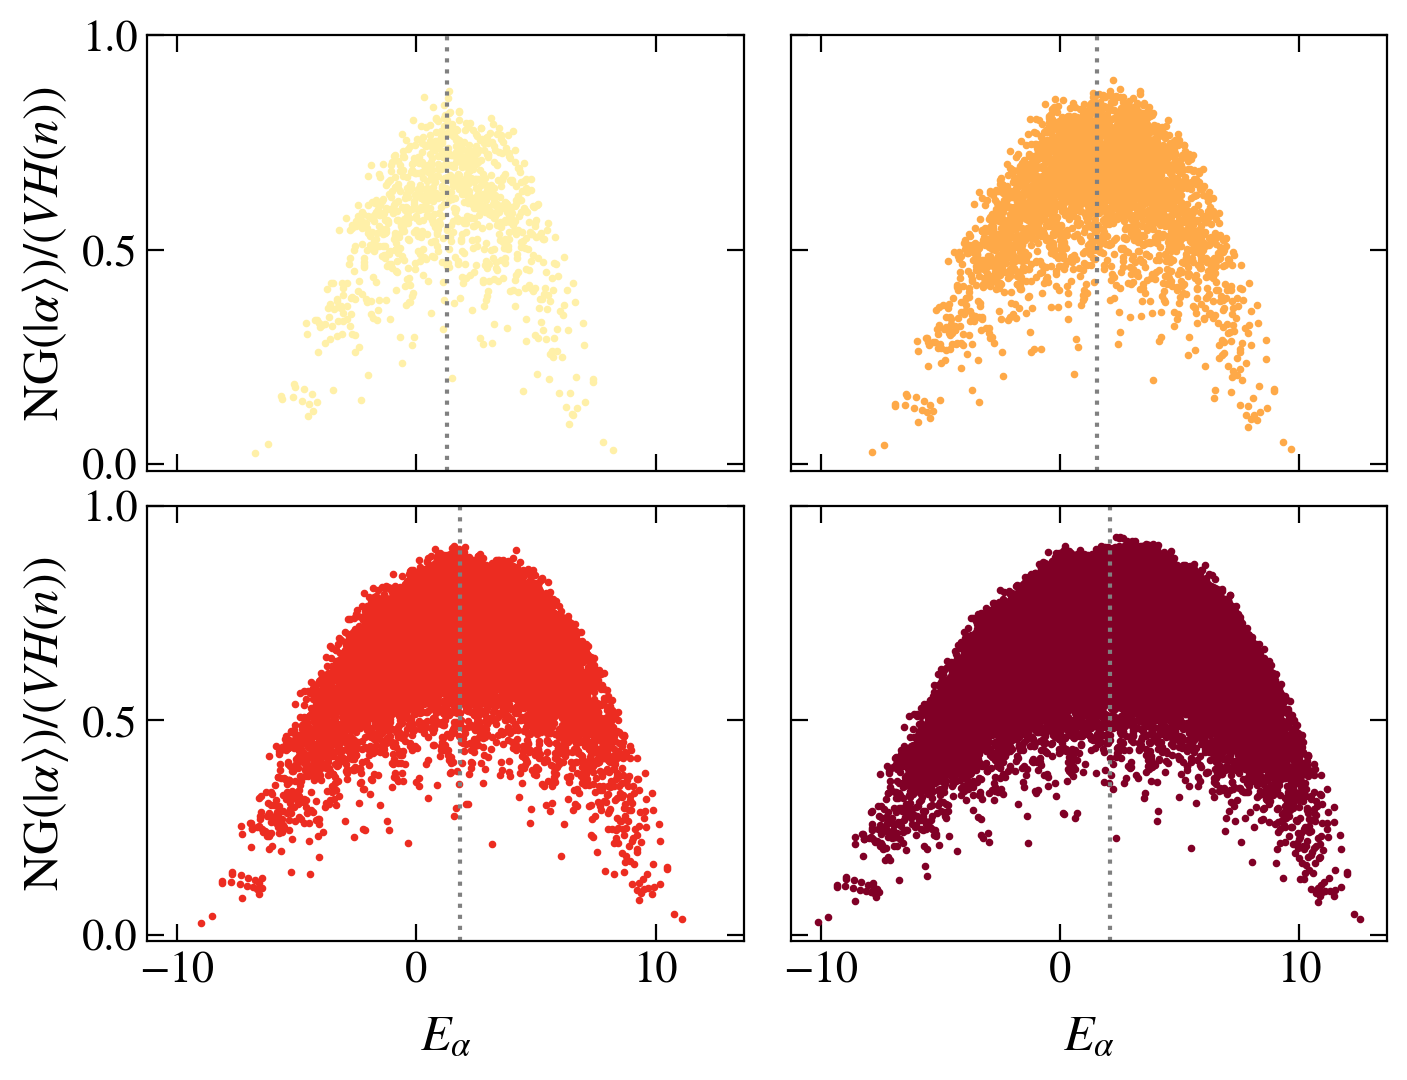

In [162]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

LOG = 0
INTEGRABLE = 1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(8,6), dpi = 200, sharex=True, sharey='row')

axis = axis.flatten()

f = 1
n = 1/2

sizes = np.arange(12, 19, 2) if n == 1/2 else np.arange(12, 20, 3)
norm = matplotlib.colors.Normalize(
            vmin=min(sizes),
            vmax=max(sizes))


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])
BOUNDARY_COND = 'ABC'


term1 = n * np.log(n)
term2 = (1-n) * np.log(1-n)

Hn = - term1 - term2
for iiL, L in enumerate(sizes):
    col = s_m_L.to_rgba(L)
    subsystem = np.arange(0, L, 1)
    N = int(n * L)
    LA = int(f * L) if f > 0 else 1
    idx = np.argmin( np.abs(subsystem - LA) )
    if LA == L: idx = -1
    
    V1 = 0.55
    t2 = 0 if INTEGRABLE else 2
    V2 = 0 if INTEGRABLE else 2
    name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energies')[0])
            # Ex = (Ex - np.mean(Ex))
            # Ex = Ex / np.std(Ex)
            # Ex = (Ex - Ex[0]) / (Ex[-1] - Ex[0])
            NG = np.array(file.get('Non-Gaussianity'))[idx] / L# - (2 * n - 1)**2
            if LOG: NG = Hn - NG
            else:   NG = NG / Hn
            axis[iiL].scatter(Ex, NG, color = col, s=3, rasterized=True)
            axis[iiL].axvline(x = np.mean(Ex), ls=':', color='gray')
    else:
        print(name)
    
    ylab = r"$H(n) - {\rm NG}(|\alpha\rangle)$" if LOG else r"${\rm NG}(|\alpha\rangle)/(VH(n))$"
    fig_help.set_plot_elements(axis[iiL], ylabel="" if iiL%2 else ylab, xlabel=r"$E_\alpha$" if iiL > 1 else "", font_size=16, set_legend=True, xscale='linear', yscale='log' if LOG else 'linear')
    # axis[iiL].set_xlim(0, 1)
    axis[iiL].set_ylim(None, 1)

    # if iin: 
    #     z = np.linspace(0, 1,1000)
    #     # axis.plot(z, (2*z - 1)**2, color='blue', ls='--', lw=2)
    #     # axis2.plot(z, (2*z - 1)**2, color='blue', ls='--', lw=2)
    #     axis.axhline(y=(2*n-1)**2, ls='--', color='k')
    #     axis2.axhline(y=(2*n-1)**2, ls='--', color='k')
# axa[0][0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
# axa[0][1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
# axa[1][0].annotate(r"(c) $n=\frac{1}{2}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
# axa[1][1].annotate(r"(d) $n=\frac{1}{3}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.08, hspace=0.08)
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


Int 1.0 -0.7695267658605063
Ch 1.0 0.09245255077819399
Ch2 0.006706314914918258 -11036579.549482733 1.0
993 493 2000
Int 1.0 0.44240625489636715
Ch 1.0 0.08400678326568238
Ch2 0.012197904794271037 -2978618.2679347694 1.0


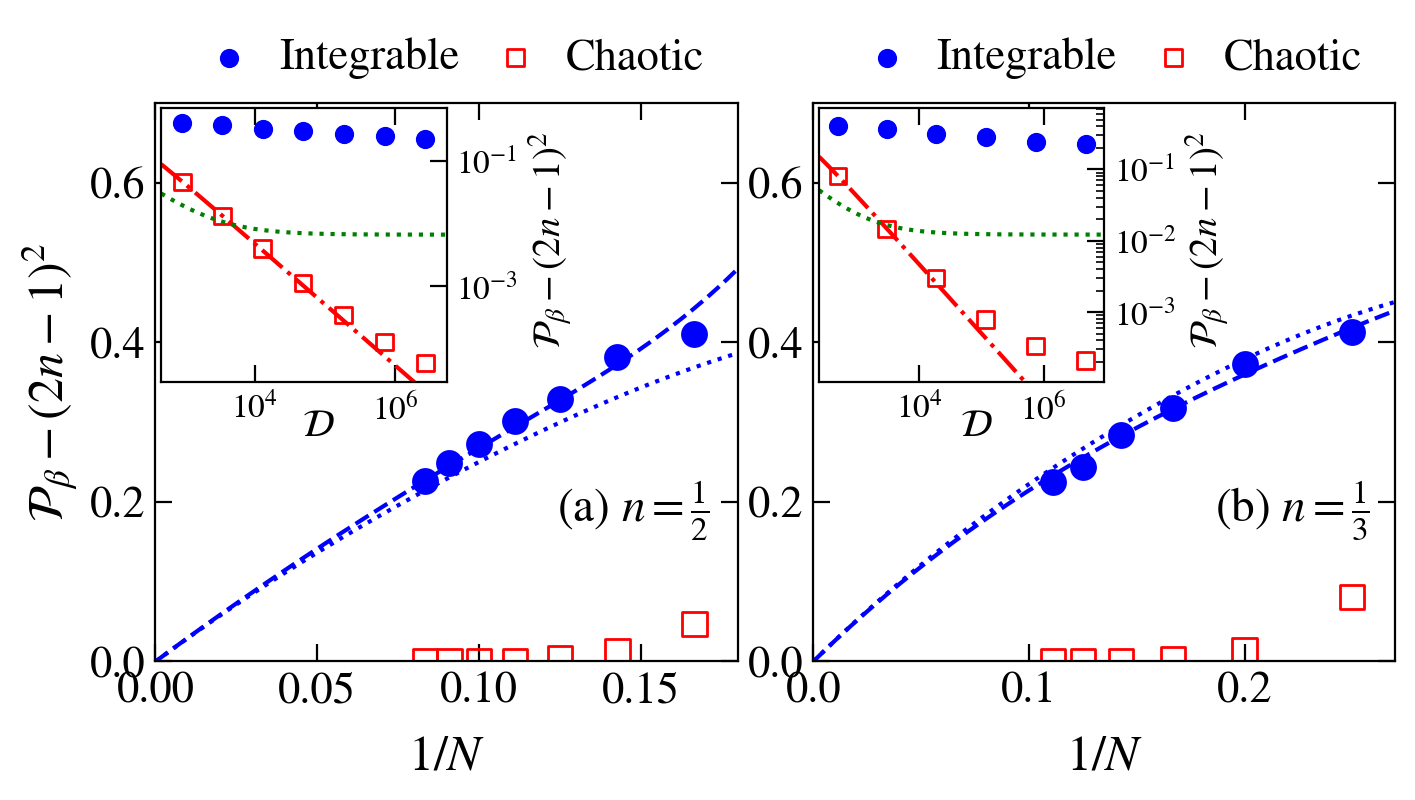

In [209]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=1, ncols=2, figsize=(8,3.7), dpi = 200, sharex=False)

for iin, n in enumerate([1/2, 1/3]):

    ax2 = axa[iin].inset_axes([0.01, 0.5, 0.49, 0.49])
    # axis = [ax2, axa[iin]]
    axis = [axa[iin], ax2]

    f = 1
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)

    Purity_int = np.zeros(sizes.shape)
    Purity_ch = np.zeros(sizes.shape)
    Purity_ch2 = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    # Pinf = 4*n * (1-n)
    Pinf = (2 * n - 1)**2
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                
                dim = binom(L, N)#Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = int( min([1000, dim//10]) )
                P = np.array(file.get('Purity'))[idx] / LA - Pinf# - 4 * L * n * (1-n) / binom(L, n*L)
                P = P[10:-10] if dim > 7e4 else P[idxE - num//2 : idxE + num//2]
                if P.size > 1000:
                    print(idxE, idxE - 500, Ex.size)
                    P = P[idxE - 500 : idxE + 500]
                # if dim > 7e4:
                Purity_int[iiL] += np.mean(P)
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = binom(L, N)#Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = int( min([1000, dim//10]) )
                P = np.array(file.get('Purity'))[idx] / LA - Pinf# - 4 * L * n * (1-n) / binom(L, N)
                # print(idxE, L, P.size)
                P = P[1:-1] if dim > 7e4 else P[idxE - num//2 : idxE + num//2]
                if P.size > 1000 and dim > 7e4:
                    P = P[idxE - 500 : idxE + 500]
                Purity_ch[iiL] += np.mean(P)# if dim > 7e4 else np.mean(P[idxE - num//2 : idxE + num//2])
                Purity_ch2[iiL] += np.exp( np.mean(np.log(P)) )
        else:
            print(name)
        
    Chaotic_GOE = 9 / (2 + dims/4)
    Chaotic_GUE = 4 / (1 + dims/4)

    particle_num = sizes * n
    axis[0].scatter(1/particle_num, Purity_int, s=75, color='blue')
    axis[1].scatter(binom(sizes, particle_num), Purity_int, s=35, color='blue', label='Integrable')
    # axis[1].scatter(2**(sizes), Purity_int, s=35, color='blue', label='Integrable')

    axis[0].scatter(1/particle_num, Purity_ch, s=75, color='red', marker='s', facecolor='None')
    axis[1].scatter(binom(sizes, particle_num), Purity_ch, s=35, color='red', label='Chaotic', marker='s', facecolor='None')
    # axis[1].scatter(2**(sizes), Purity_ch, s=35, color='red', label='Chaotic', marker='s', facecolor='None')
    # axis[1].scatter(binom(sizes, particle_num), Purity_ch2, s=35, color='red', label='Chaotic', marker='v', facecolor='None')
    # print(Purity_ch - Purity_ch2)
    z = np.linspace(0, 0.1, 1000)
    # axis[0].plot(z, 9 / (2 + 1.5/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
    # # axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # axis[0].plot(z, 9 / (2 + 1/z), ls='--', lw=2, color='gray', label=r"$O(V)$")
    # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
    # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # def fit_purity(x, a, b):
    #     dim = binom(x, x*n)
    #     return 3 * (1 - Pinf) / (2 + b * x)# + a / dim**0.5
        
    def fit_purity(x: float, a: int, b: int):
        dim = binom(x, x*n)
        prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * n * x))
        return 3 * (1 - Pinf) / (2 + (b + n * x)) + prob

    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = sizes,
                            ydata = Purity_int,
                            full_output=True, maxfev=10000)
    print("Int", *pars)
    xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[0].plot( xx / n, fit_purity(1/xx, *pars), ls='--',  color = 'blue')
    axis[0].plot( xx / n, fit_purity(1/xx, 0, 0), ls=':',  color = 'blue')
    
    def fit_purity(x: float, a: int, b: int):
        dim = binom(x, x*n)
        prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * dim))
        return 3 * (1 - Pinf) / (2 + b * dim) + prob


    xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = sizes,
                            ydata = Purity_ch,
                            full_output=True, maxfev=10000)
    print("Ch", *pars)
    xx = np.linspace(min(sizes)-2, max(sizes)+1, 10000)
    # xx = np.linspace(binom(min(sizes), min(sizes) * n)/2, binom(max(sizes), max(sizes) * n)*200, 10000)
    # xx = binom(xx, xx*n)
    axis[1].plot(binom(xx, xx*n), fit_purity(xx, *pars), ls='-.',  color = 'red')
    # axis[1].plot(2**(xx), fit_purity(xx, *pars), ls='-.',  color = 'red')


    def fit_purity(x, a, b, alf):
        dim = binom(x, x*n)
        prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * dim))
        return 3 * (1 - Pinf) / (2 + b * dim) + prob + a
    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = sizes,
                            ydata = Purity_ch,
                            full_output=True, maxfev=10000)
    print("Ch2", *pars)
    axis[1].plot(binom(xx, xx*n), fit_purity(xx, *pars), ls=':',  color = 'green')

    xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
    Ns = xx*n
    dims = binom(xx, Ns)
    # prob = 1 - np.exp(-binom(dims/20, ))
    # axis[1].plot(dims, 4 * xx * n * (1-n) / dims, ls='-', color='k')
    # b = 1
    # prob = 4 * xx * n * (1-n) / dims * (1 - 3 / (2 + b * dims))
    # axis[1].plot(dims, 3 * (1 - Pinf) / (2 + b * dims) + prob, ls='-', color='k')
    # axis[1].plot(dims, 0.5*(2 * xx - 1) / dims, ls=':', color='green')
    
    # xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
    # pars, pconv, fit_info, msg, _ = fit(fit_purity,
    #                         xdata = dims[1:]**0.5,
    #                         ydata = Purity_ch[1:],
    #                         full_output=True, maxfev=10000)
    # print(*pars)
    # xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
    # xx = binom(xx, xx*n)
    # axis[1].plot(xx, fit_purity(xx**0.5, *pars), ls=':',  color = 'red')

    # fig_help.set_plot_elements(axis[0], ylabel=r"$P-(2n-1)^2$", xlabel=r"$1/N$", font_size=12, set_legend=True, xlim=(0, 0.09/n), xscale='linear', yscale='linear')
    # fig_help.set_plot_elements(axis[1], ylabel="" if iin else r"$P-(2n-1)^2$", xlabel=r"$\mathcal{D}$", font_size=16, set_legend=True, xscale='log', yscale='log')
    fig_help.set_plot_elements(axa[iin], ylabel="" if iin else r"$\mathcal{P}_\beta-(2n-1)^2$", xlabel=r"$1/N$", font_size=16, set_legend=True, xlim=(0, 0.09/n), xscale='linear', yscale='linear')
    fig_help.set_plot_elements(ax2, ylabel=r"$\mathcal{P}_\beta-(2n-1)^2$", xlabel=r"$\mathcal{D}$", font_size=12, set_legend=True, xscale='log', yscale='log')
    
    fig_help.set_legend(axis[1], fontsize=16, loc = 'lower left', ncol=2, columnspacing=0.4, frameon=False, anchor=(-.04, 0.96))
    axis[0].set_ylim(0, 0.7)
    ax2.set_ylim(min(Purity_ch) / 2, None)
    axis[1].set_xlim(binom(min(sizes), min(sizes) * n)/2, binom(max(sizes), max(sizes) * n)*2)


    # ax2.xaxis.set_label_position("top")
    # ax2.xaxis.tick_top()
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    ax2.xaxis.set_label_coords(0.55, -0.1)
    ax2.yaxis.set_label_coords(1.28, .52)

fig.subplots_adjust(wspace = 0.13, hspace=0.02)
axa[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
axa[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


Int 0.5 1.0 1.0
Ch 0.5 1.0 1.0
993 493 2000
Int 0.3333333333333333 1.0 1.0
Ch 0.3333333333333333 1.0 1.0


Text(0.69, 0.25, '(b) $n=\\frac{1}{3}$')

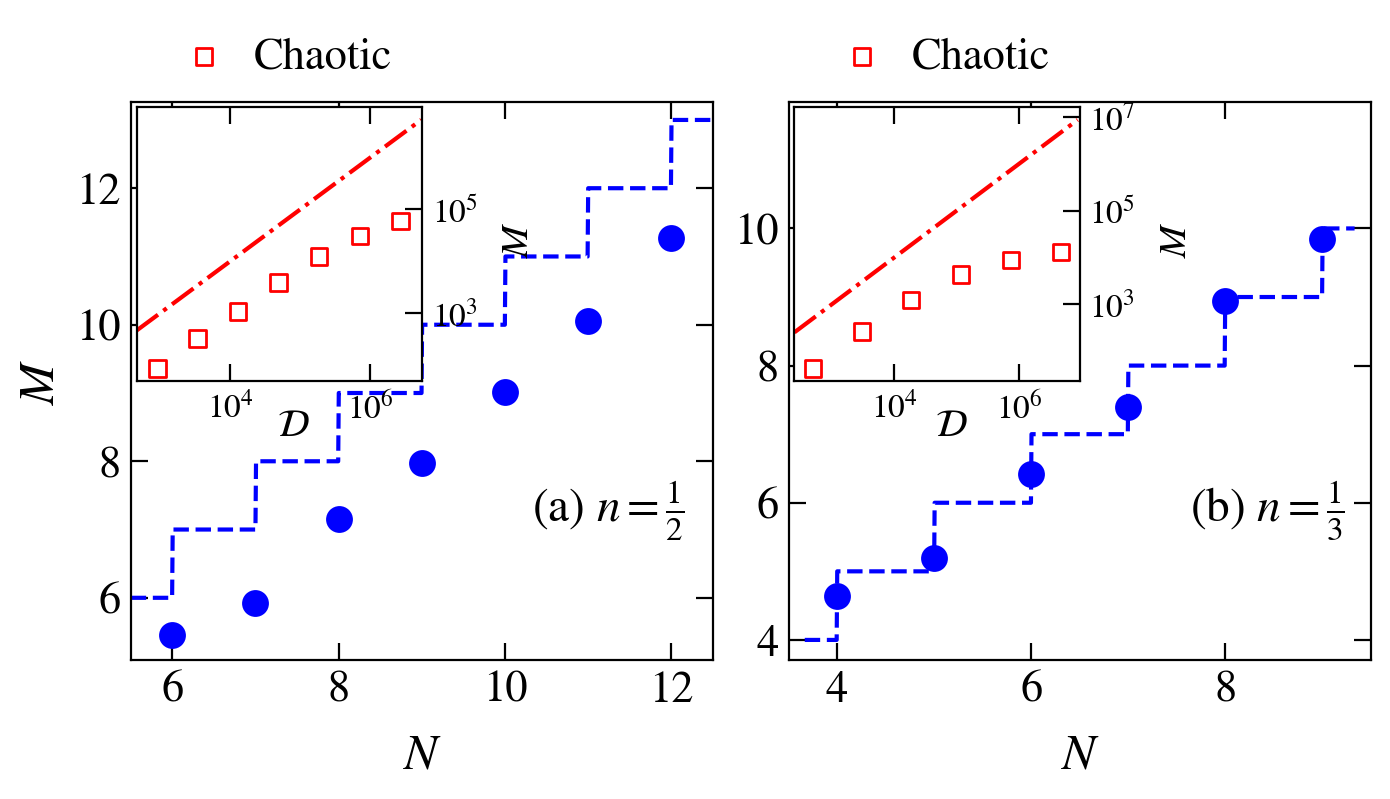

In [212]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=1, ncols=2, figsize=(8,3.7), dpi = 200, sharex=False)

for iin, n in enumerate([1/2, 1/3]):

    ax2 = axa[iin].inset_axes([0.01, 0.5, 0.49, 0.49])
    # axis = [ax2, axa[iin]]
    axis = [axa[iin], ax2]

    f = 1
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)

    Purity_int = np.zeros(sizes.shape)
    Purity_ch = np.zeros(sizes.shape)
    Purity_ch2 = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    # Pinf = 4*n * (1-n)
    Pinf = (2 * n - 1)**2
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                
                dim = binom(L, N)#Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = int( min([1000, dim//10]) )
                P = np.array(file.get('Purity'))[idx] / LA - Pinf# - 4 * L * n * (1-n) / binom(L, n*L)
                P = P[10:-10] if dim > 7e4 else P[idxE - num//2 : idxE + num//2]
                if P.size > 1000:
                    print(idxE, idxE - 500, Ex.size)
                    P = P[idxE - 500 : idxE + 500]
                # if dim > 7e4:
                Purity_int[iiL] += np.mean(P)
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = binom(L, N)#Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = int( min([1000, dim//10]) )
                P = np.array(file.get('Purity'))[idx] / LA - Pinf# - 4 * L * n * (1-n) / binom(L, N)
                # print(idxE, L, P.size)
                P = P[1:-1] if dim > 7e4 else P[idxE - num//2 : idxE + num//2]
                if P.size > 1000 and dim > 7e4:
                    P = P[idxE - 500 : idxE + 500]
                Purity_ch[iiL] += np.mean(P)# if dim > 7e4 else np.mean(P[idxE - num//2 : idxE + num//2])
                Purity_ch2[iiL] += np.exp( np.mean(np.log(P)) )
        else:
            print(name)
        
    Chaotic_GOE = 9 / (2 + dims/4)
    Chaotic_GUE = 4 / (1 + dims/4)

    
    particle_num = sizes * n
    beta = 0.5
    dims = binom(sizes, particle_num)
    M_int = (Purity_int - 4*sizes*n*(1-n) / dims) / ( 4*n*(1-n) * (1 - sizes / dims))
    M_int = ( (beta + 1) / M_int - 1 ) / beta
    
    M_ch = (Purity_ch - 4*sizes*n*(1-n) / dims) / ( 4*n*(1-n) * (1 - sizes / dims))
    M_ch = ( (beta + 1) / M_ch - 1 ) / beta
    
    axis[0].scatter(particle_num, M_int, s=75, color='blue')
    # axis[1].scatter(dims, M_int, s=35, color='blue', label='Integrable')
    # axis[1].scatter(2**(sizes), Purity_int, s=35, color='blue', label='Integrable')

    # axis[0].scatter(particle_num, M_ch, s=75, color='red', marker='s', facecolor='None')
    axis[1].scatter(dims, M_ch, s=35, color='red', label='Chaotic', marker='s', facecolor='None')
    
    x = np.linspace(min(sizes)-1, max(sizes)+1, 1000) * n
    # axis[0].plot(x, x-1, ls='--', color='green')
    # axis[0].plot(x*n, n*x, ls=':', color='green')
    # # axis[1].scatter(2**(sizes), Purity_ch, s=35, color='red', label='Chaotic', marker='s', facecolor='None')
    # axis[1].scatter(binom(sizes, particle_num), Purity_ch2, s=35, color='red', label='Chaotic', marker='v', facecolor='None')
    # print(Purity_ch - Purity_ch2)
    # z = np.linspace(0, 0.1, 1000)
    # # axis[0].plot(z, 9 / (2 + 1.5/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
    # # # axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # # axis[0].plot(z, 9 / (2 + 1/z), ls='--', lw=2, color='gray', label=r"$O(V)$")
    # # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
    # # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # def fit_purity(x, a, b):
    #     dim = binom(x, x*n)
    #     return 3 * (1 - Pinf) / (2 + b * x)# + a / dim**0.5
        
    def fit_purity(x, a, b):
        return (a * x + b).astype(int)

    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = particle_num,
                            ydata = M_int,
                            full_output=True, maxfev=10000)
    print("Int", n, *pars)
    # xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[0].plot( x, fit_purity(x, *pars), ls='--',  color = 'blue')
    # axis[0].plot( xx / n, fit_purity(1/xx, 0, 1), ls=':',  color = 'blue')
    
    # def fit_purity(x, a, b):
    #     return a * x**b


    # xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
    pars, pconv, fit_info, msg, _ = fit(fit_purity,
                            xdata = dims[:-2],
                            ydata = M_ch[:-2],
                            full_output=True, maxfev=10000)
    print("Ch", n, *pars)
    xx = np.linspace(min(sizes)-2, max(sizes)+1, 10000)
    # # xx = np.linspace(binom(min(sizes), min(sizes) * n)/2, binom(max(sizes), max(sizes) * n)*200, 10000)
    xx = binom(xx, xx*n)
    axis[1].plot(xx, pars[0] * xx + pars[1], ls='-.',  color = 'red')
    # # axis[1].plot(2**(xx), fit_purity(xx, *pars), ls='-.',  color = 'red')


    # def fit_purity(x, a, b, alf):
    #     dim = binom(x, x*n)
    #     prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * dim))
    #     return 3 * (1 - Pinf) / (2 + b * dim) + prob + a
    # pars, pconv, fit_info, msg, _ = fit(fit_purity,
    #                         xdata = sizes,
    #                         ydata = Purity_ch,
    #                         full_output=True, maxfev=10000)
    # print("Ch2", *pars)
    # axis[1].plot(binom(xx, xx*n), fit_purity(xx, *pars), ls=':',  color = 'green')

    # xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
    # Ns = xx*n
    # dims = binom(xx, Ns)
    # prob = 1 - np.exp(-binom(dims/20, ))
    # axis[1].plot(dims, 4 * xx * n * (1-n) / dims, ls='-', color='k')
    # b = 1
    # prob = 4 * xx * n * (1-n) / dims * (1 - 3 / (2 + b * dims))
    # axis[1].plot(dims, 3 * (1 - Pinf) / (2 + b * dims) + prob, ls='-', color='k')
    # axis[1].plot(dims, 0.5*(2 * xx - 1) / dims, ls=':', color='green')
    
    # xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
    # pars, pconv, fit_info, msg, _ = fit(fit_purity,
    #                         xdata = dims[1:]**0.5,
    #                         ydata = Purity_ch[1:],
    #                         full_output=True, maxfev=10000)
    # print(*pars)
    # xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
    # xx = binom(xx, xx*n)
    # axis[1].plot(xx, fit_purity(xx**0.5, *pars), ls=':',  color = 'red')

    # fig_help.set_plot_elements(axis[0], ylabel=r"$P-(2n-1)^2$", xlabel=r"$1/N$", font_size=12, set_legend=True, xlim=(0, 0.09/n), xscale='linear', yscale='linear')
    # fig_help.set_plot_elements(axis[1], ylabel="" if iin else r"$P-(2n-1)^2$", xlabel=r"$\mathcal{D}$", font_size=16, set_legend=True, xscale='log', yscale='log')
    fig_help.set_plot_elements(axa[iin], ylabel="" if iin else r"$M$", xlabel=r"$N$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
    fig_help.set_plot_elements(ax2, ylabel=r"$M$", xlabel=r"$\mathcal{D}$", font_size=12, set_legend=True, xscale='log', yscale='log')
    
    fig_help.set_legend(axis[1], fontsize=16, loc = 'lower left', ncol=2, columnspacing=0.4, frameon=False, anchor=(-.04, 0.96))
    axis[0].set_ylim(None, max(M_int) + 2)
    axis[0].set_xlim(min(particle_num)-0.5, max(particle_num)+0.5)
    # ax2.set_ylim(min(Purity_ch)/1.1, None)
    axis[1].set_xlim(binom(min(sizes), min(sizes) * n)/2, binom(max(sizes), max(sizes) * n)*2)


    # ax2.xaxis.set_label_position("top")
    # ax2.xaxis.tick_top()
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    ax2.xaxis.set_label_coords(0.55, -0.1)
    ax2.yaxis.set_label_coords(1.28, .52)

fig.subplots_adjust(wspace = 0.13, hspace=0.02)
axa[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
axa[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

5 5
0.5 10 113 121 136
6 6
0.5 12 409 451 499
7 7
0.5 14 1526 1680 1867
8 8
0.5 16 6074 6301 6572
9 9
0.5 18 23600 23828 24098
4 4
0.3333333333333333 12 223 244 270
5 5
0.3333333333333333 15 1344 1486 1642
6 6
0.3333333333333333 18 8962 9202 9460


Text(0.69, 0.05, '(b) $n=\\frac{1}{3}$')

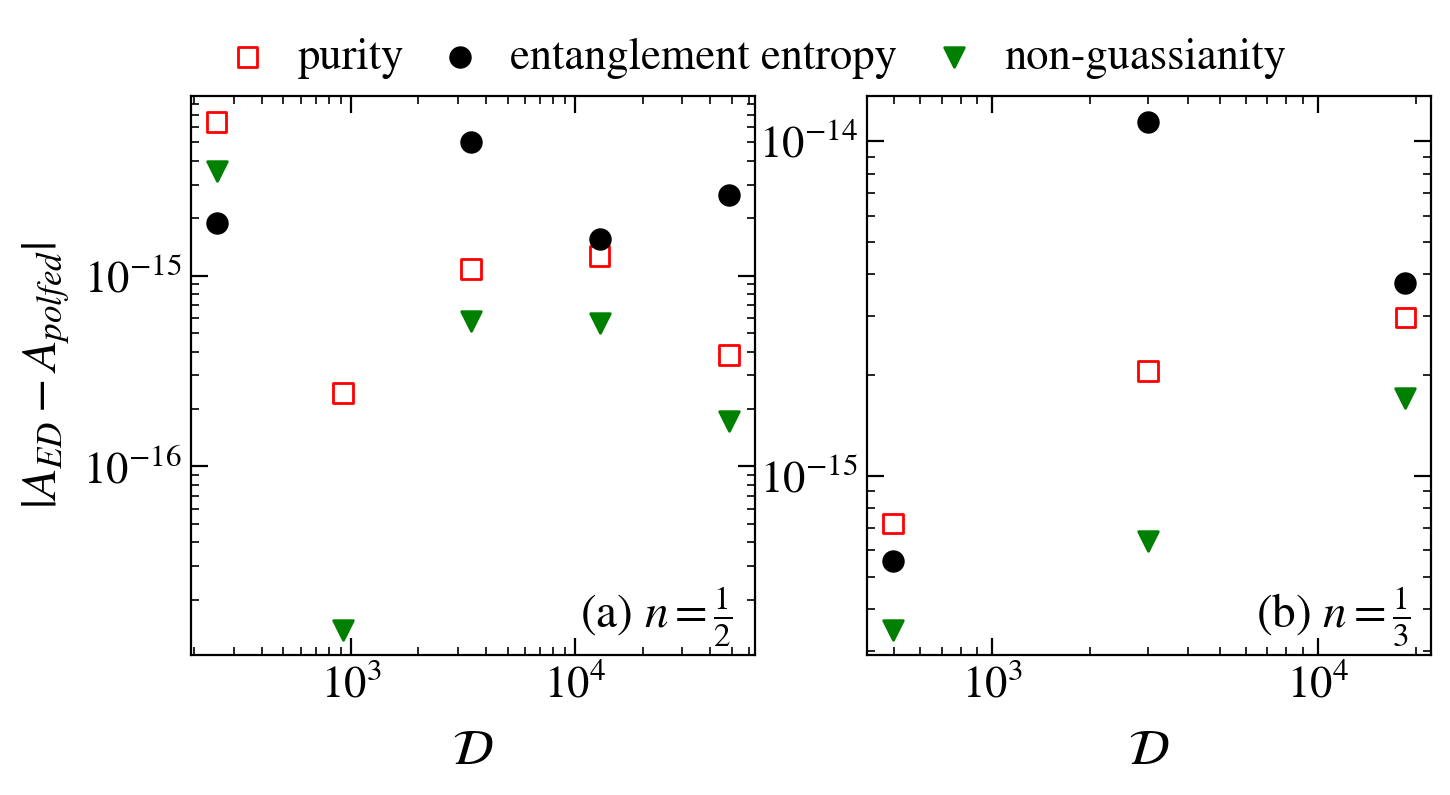

In [73]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8,3.7), dpi = 200, sharex=False)

for iin, n in enumerate([1/2, 1/3]):

    f = n
    sizes = np.arange(10, 19, 2) if n == 1/2 else np.arange(12, 19, 3)

    Purity_ch = np.zeros(sizes.shape)
    Purity_ch2 = np.zeros(sizes.shape)
    NonGauss = np.zeros(sizes.shape)
    NonGauss2 = np.zeros(sizes.shape)
    entanglement = np.zeros(sizes.shape)
    entanglement2 = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    Hn = -(n) * np.log(n) - (1-n) * np.log(1-n)
    # Pinf = 4*n * (1-n)
    Pinf = (2 * n - 1)**2
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        print(LA, subsystem[idx])
        V1=0.55
        V2 = 2
        t2 = 2
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate2/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                dims[iiL] = binom(L, N)
                Ex = np.array(file.get('energies')[0])[1:-1]
                dim = binom(L, N)#Ex.size
                Ex1 = Ex
                
                P2 = np.array(file.get('Purity'))[-1,1:-1] / L - Pinf
                Purity_ch2[iiL] += np.mean(P2)
                
                Svn2 = np.array(file.get('entropy')[idx, 1:-1]) / (LA * Hn)
                entanglement2[iiL] += np.mean(Svn2)
                
                NG2 = np.array(file.get('Non-Gaussianity')[0,1:-1]) / (L)
                NonGauss2[iiL] = Hn - np.mean(NG2)
        else:
            print(name)
            
            
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                dims[iiL] = binom(L, N)
                Ex = np.array(file.get('energies')[0])
                dim = binom(L, N)#Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                idxE1 = np.argmin(np.abs(Ex - Ex1[0]))
                idxE2 = np.argmin(np.abs(Ex - Ex1[-1]))+1
                num = int( min([500, dim//10]) ) - 2
                
                print(n, L, idxE1, idxE, idxE2)
                P = ( np.array(file.get('Purity'))[-1] / L - Pinf )[idxE1 : idxE2]
                # print(L, P - P2)
                Purity_ch[iiL] += np.mean(P)
                
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * Hn)
                entanglement[iiL] += np.mean(Svn[idxE1 : idxE2])
                
                NG = Hn - np.array(file.get('Non-Gaussianity')[0]) / (L)
                NonGauss[iiL] = np.mean(NG[idxE1 : idxE2])
        else:
            print(name)
            
        
    Chaotic_GOE = 9 / (2 + dims/4)
    Chaotic_GUE = 4 / (1 + dims/4)

    alf = 2
    
    # print 
    particle_num = sizes * n
    # axis[iin].scatter(dims, Purity_ch, s=50, color='red', label='Chaotic', marker='s', facecolor='None')
    axis[iin].scatter(dims, np.abs(Purity_ch - Purity_ch2), s=50, color='red', label='purity', marker='s', facecolor='None')
    axis[iin].scatter(dims, np.abs(entanglement - entanglement2), s=50, color='k', label='entanglement entropy', marker='o')
    axis[iin].scatter(dims, np.abs(NonGauss - NonGauss2), s=50, color='green', label='non-guassianity', marker='v')
    # axis[iin].scatter(1/sizes, Purity_ch2, s=50, color='red', label='Chaotic', marker='o')
    # axis[iin].axhline(y=np.min(Purity_ch), ls='--', color='r')
    # xx = np.linspace(min(sizes)-1, max(sizes)+2, 10000)
    # xx = binom(xx, xx*n)
    # axis[iin].plot(xx, 0.1/xx, ls=':',  color = 'gray', label=r"$0.1/\mathcal{D}$")
    # axis[iin].plot(xx, 100/xx**2, ls='--',  color = 'k', label=r"$100/\mathcal{D}^2$")
    
    # fig_help.set_plot_elements(axis[0], ylabel=r"$P-(2n-1)^2$", xlabel=r"$1/N$", font_size=12, set_legend=True, xlim=(0, 0.09/n), xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[iin], ylabel="" if iin else r"$|A_{ED}-A_{polfed}|$", xlabel=r"$\mathcal{D}$", font_size=16, set_legend=0, xscale='log', yscale='log')
    fig_help.set_legend(axis[0], fontsize=16, loc = 'lower left', ncol=4, columnspacing=0.4, frameon=False, anchor=(-.04, 0.96))
    # axis[iin].set_ylim(0, None)
    # axis[1].set_ylim(5e-8, None)
    # axis[1].set_xlim( (min(sizes)-0.5), (max(sizes)+0.5))
    # axis[iin].set_xlim(0, 1/(min(sizes)-0.5))



axis[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.69, 0.05), xycoords='axes fraction')
axis[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.69, 0.05), xycoords='axes fraction')
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


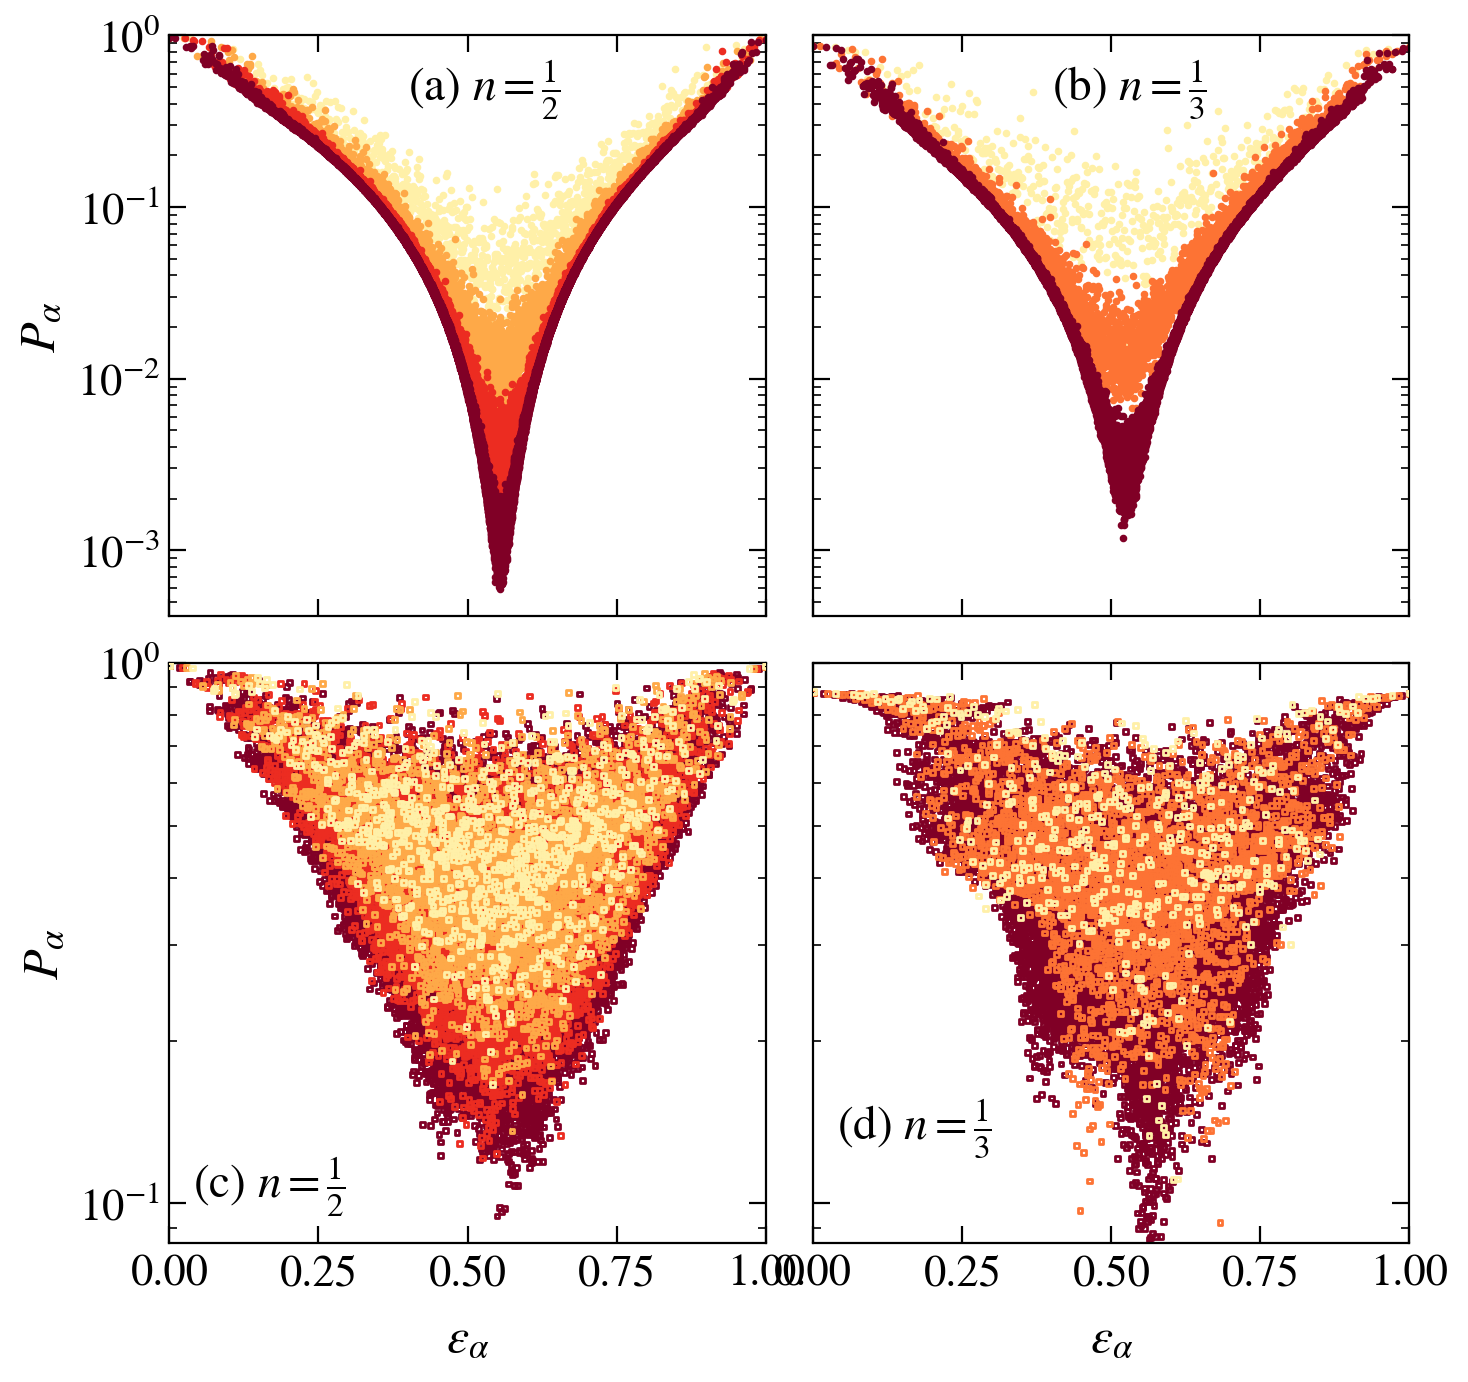

In [167]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=2, ncols=2, figsize=(8,8), dpi = 200, sharex=True, sharey='row')

LOG = 1

for iin, n in enumerate([1/2, 1/3]):
    axis = axa[0][iin]
    axis2 = axa[1][iin]

    f = 1
    sizes = np.arange(12, 19, 2) if n == 1/2 else np.arange(12, 20, 3)
    norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes))


    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

    s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m_L.set_array([])
    BOUNDARY_COND = 'ABC'

    for iiL, L in enumerate(sizes):
        col = s_m_L.to_rgba(L)
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        t2 = 2
        V2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                # Ex = (Ex - np.mean(Ex))
                # Ex = Ex / np.std(Ex)
                Ex = (Ex - Ex[0]) / (Ex[-1] - Ex[0])
                P = np.array(file.get('Purity'))[idx] / LA# - (2 * n - 1)**2
                if LOG: P = P - (2*n-1)**2
                axis.scatter(Ex, P, color = col, s=3, rasterized=True)
                
        else:
            print(name)
        V1=0.55
        V2 = 0
        t2 = 0
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                # Ex = (Ex - np.mean(Ex))
                # Ex = Ex / np.std(Ex)
                Ex = (Ex - Ex[0]) / (Ex[-1] - Ex[0])
                P = np.array(file.get('Purity'))[idx] / LA# - (2 * n - 1)**2
                # print(L, P[0])
                if LOG: P = P - (2*n-1)**2
                axis2.scatter(Ex, P, color = col, s=3, rasterized=True, marker='s', facecolor='None', zorder = sizes[-1] - L)
        else:
            print(name)
        
    fig_help.set_plot_elements(axis, ylabel="" if iin else r"$P_\alpha$", xlabel=r"", font_size=16, set_legend=True, xscale='linear', yscale='log' if LOG else 'linear')
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    fig_help.set_plot_elements(axis2, ylabel="" if iin else r"$P_\alpha$", xlabel=r"$\epsilon_\alpha$", font_size=16, set_legend=True, xscale='linear', yscale='log' if LOG else 'linear')
    axis2.set_xlim(0, 1)
    axis2.set_ylim(0, 1)
    
    z = np.linspace(0, 1,1000)
    # axis.plot(z, (2*n-1)**2 + 0.5*(2*z - 1)**2, color='blue', ls='--', lw=2)    
    if iin >= 1 and not LOG: 
        axis.axhline(y=(2*n-1)**2, ls='--', color='k')
        axis2.axhline(y=(2*n-1)**2, ls='--', color='k')
axa[0][0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.4, 0.89), xycoords='axes fraction')
axa[0][1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.4, 0.89), xycoords='axes fraction')
axa[1][0].annotate(r"(c) $n=\frac{1}{2}$", fontsize=17, xy=(0.04, 0.08), xycoords='axes fraction')
axa[1][1].annotate(r"(d) $n=\frac{1}{3}$", fontsize=17, xy=(0.04, 0.18), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.08, hspace=0.08)
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

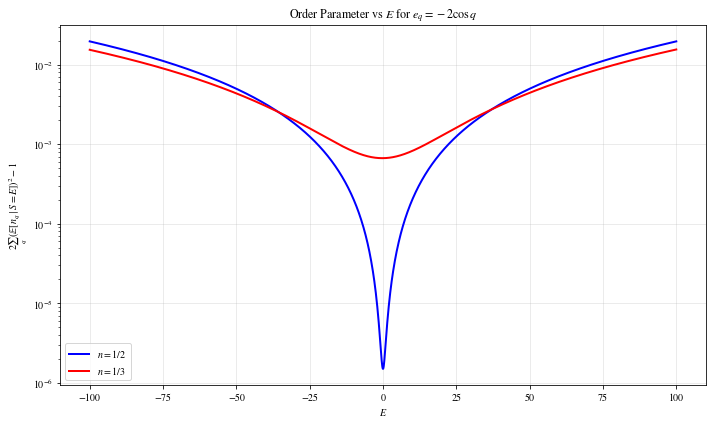

In [253]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1000
E_range = np.linspace(-100, 100, 2000)  # E from -10 to 10

# Precompute cos(q) for q = 1 to N
q = np.arange(1, N + 1)
cos_q = np.cos(q)

# Function to compute Y(E) = 2 * sum( E[n_q|S=E]^2 ) - 1
def compute_Y(E, n):
    denom = n * (1 - n) * N
    exponent = (-E * cos_q - cos_q**2) / denom
    exp_term = np.exp(exponent)
    y_q = (n * exp_term) / (n * exp_term + (1 - n))
    y_q_sq = (2*y_q - 1) ** 2
    sum_y_sq = np.sum(y_q_sq)
    return (sum_y_sq) / N - (2*n-1)**2

# Compute for both n = 1/2 and n = 1/3
Y_n_half = [compute_Y(E, 0.5) for E in E_range]
Y_n_third = [compute_Y(E, 1/3) for E in E_range]

# Plot
plt.figure(figsize=(10, 6))

plt.plot(E_range, Y_n_half, label=r'$n = 1/2$', color='blue', linewidth=2)
plt.plot(E_range, Y_n_third, label=r'$n = 1/3$', color='red', linewidth=2)

plt.xlabel(r'$E$')
plt.ylabel(r'$2 \sum_q \left( \mathbb{E}[n_q \mid S = E] \right)^2 - 1$')
plt.title(r'Order Parameter vs $E$ for $e_q = -2\cos q$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
# plt.axvline(x=0, color='k', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

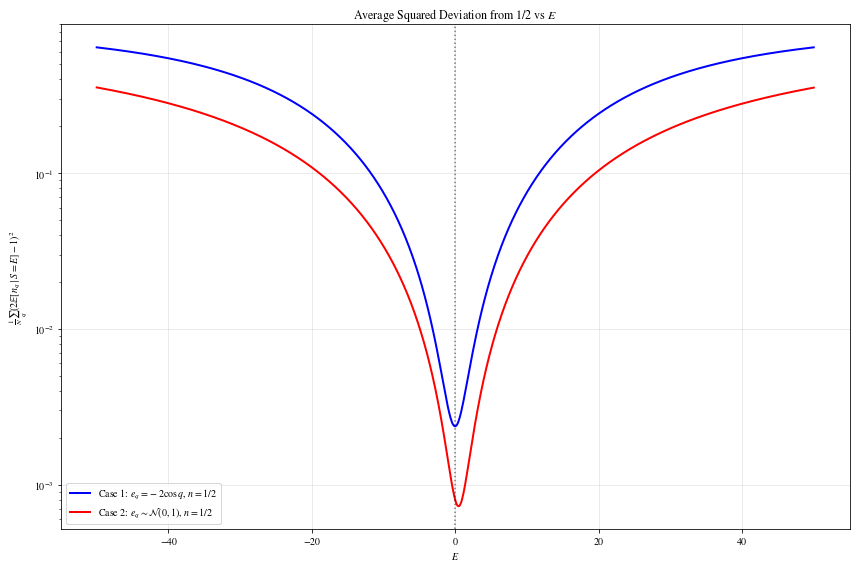

In [246]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100
E_range = np.linspace(-50, 50, 1000)

# Case 1: Deterministic e_q = -2 cos(q)
q = np.arange(1, N + 1)
cos_q = np.cos(q)
e_q = -2 * cos_q

# Case 2: Random e_q ~ N(0,1)
np.random.seed(42)  # for reproducibility
e_q_rand = np.random.randn(N)

# Function to compute average squared deviation
def compute_avg_sq_dev(E, e_q, n):
    denom = n * (1 - n) * N
    exponent = (-E * e_q - e_q**2) / denom
    exp_term = np.exp(exponent)
    y_q = (n * exp_term) / (n * exp_term + (1 - n))
    return np.mean((2 * y_q - 1)**2)

# Compute for both cases and both n
Y_case1_n_half = [compute_avg_sq_dev(E, e_q, 0.5) for E in E_range]
Y_case1_n_third = [compute_avg_sq_dev(E, e_q, 1/3) for E in E_range]

Y_case2_n_half = [compute_avg_sq_dev(E, e_q_rand, 0.5) for E in E_range]
Y_case2_n_third = [compute_avg_sq_dev(E, e_q_rand, 1/3) for E in E_range]

# Plot
plt.figure(figsize=(12, 8))

plt.plot(E_range, Y_case1_n_half, label=r'Case 1: $e_q = -2\cos q$, $n = 1/2$', color='blue', linewidth=2)
# plt.plot(E_range, Y_case1_n_third, label=r'Case 1: $e_q = -2\cos q$, $n = 1/3$', color='cyan', linewidth=2)

plt.plot(E_range, Y_case2_n_half, label=r'Case 2: $e_q \sim \mathcal{N}(0,1)$, $n = 1/2$', color='red', linewidth=2)
# plt.plot(E_range, Y_case2_n_third, label=r'Case 2: $e_q \sim \mathcal{N}(0,1)$, $n = 1/3$', color='magenta', linewidth=2)

plt.xlabel(r'$E$')
plt.ylabel(r'$\frac{1}{N} \sum_q \left(2 \mathbb{E}[n_q \mid S = E] - 1\right)^2$')
plt.title(r'Average Squared Deviation from 1/2 vs $E$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='k', linestyle=':', alpha=0.5)
plt.yscale('log')

plt.tight_layout()
plt.show()

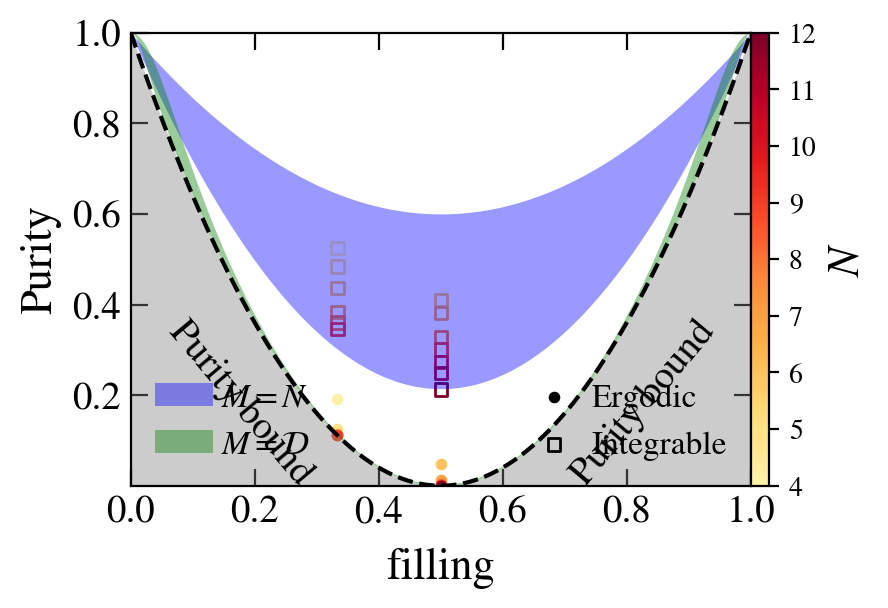

In [72]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex = True)

n = 1/2
f = 1
norm = matplotlib.colors.Normalize(
            vmin=4,
            vmax=12)


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])

for n in [1/3, 1/2]:
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    
    Purity_int = np.zeros(sizes.shape)
    Purity_ch = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                
                dim = Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                P = np.array(file.get('Purity'))[idx] / LA# - (2 * n - 1)**2
                
                Purity_int[iiL] += np.mean(P[10:-10]) if dim > 7e4 else np.mean(P[idxE - num//2 : idxE + num//2])
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                P = np.array(file.get('Purity'))[idx] / LA# - (2 * n - 1)**2
                
                Purity_ch[iiL] += np.mean(P[10:-10]) if dim > 7e4 else np.mean(P[idxE - num//2 : idxE + num//2])
        else:
            print(name)
            
        # for M in [2, L/2, binom(L, L//2)]:
        #     ns = np.linspace(0, 1, int(1e4))
        #     tmp = (2*ns - 1)**2
        #     p = axis.plot(ns, tmp + (1 - tmp) * 3 / (M + 2), color=s_m_L.to_rgba(L))
    
    for iiL, L in enumerate(sizes):
        N = int(L * n)
        axis.scatter(n, Purity_ch[iiL], color=s_m_L.to_rgba(N), s=10)
        axis.scatter(n, Purity_int[iiL], color=s_m_L.to_rgba(N), s=20, marker='s', facecolor='None')

L=1e4
ns = np.linspace(1/L, 1-1/L, int(L)+1)
tmp = (2*ns - 1)**2
axis.plot(ns, tmp, color = 'k', ls='--')
axis.fill_between(ns, 0, tmp, color='gray', lw=0, alpha=0.4)
axis.annotate(r"Purity bound", fontsize=14, xy=(0.05, 5e-3), xycoords='data', color='k', rotation=-50)
axis.annotate(r"Purity bound", fontsize=14, xy=(0.7, 5e-3), xycoords='data', color='k', rotation=50)

handles = []
sc = axis.scatter(np.nan, np.nan, color='k', label = r"Ergodic", s=10); handles.append(sc)
sc = axis.scatter(np.nan, np.nan, color='k', label = r"Integrable", s=20, marker='s', facecolor='None'); handles.append(sc)

# fil = axis.fill_between(ns, tmp + (1 - tmp) * 3 / (12/2 + 2), tmp + (1 - tmp) * 3 / (27/2 + 2), color='blue', lw=0, alpha=0.2, label=r"$M=V/2$")
fil = axis.fill_between(ns, tmp + (1 - tmp) * 3 / (3 + 2), tmp + (1 - tmp) * 3 / (12 + 2), color='blue', lw=0, alpha=0.4, label=r"$M=N$")
handles.append(fil)
fil = axis.fill_between(ns, tmp + (1 - tmp) * 3 / (binom(12, 12*ns)/1 + 2), tmp + (1 - tmp) * 3 / (binom(27, 27*ns)/1 + 2), color='green', lw=0, alpha=0.4, label=r"$M=\mathcal{D}$")
handles.append(fil)

fig_help.set_plot_elements(axis, ylabel=r"Purity", xlabel = r"filling", font_size=14, set_legend=True, xlim=(0,1), ylim=(0.9*min(Purity_ch),1), xscale='linear', yscale='linear')
leg1 = fig_help.set_legend(axis, fontsize=12, loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, anchor=(-0.01, -0.01), handles = handles[-2:])
fig_help.set_legend(axis, fontsize=12, loc = 'lower right', ncol=1, columnspacing=0.4, frameon=False, anchor=(1.01, -0.01), handles = handles[:2])
fig.add_artist(leg1)

cbar_ax = axis.inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m_L, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$N$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')


fig.subplots_adjust(wspace = 0.3, hspace=0.05)
fig.savefig("plots_mixing/Fig_intro.pdf", bbox_inches = 'tight', pad_inches=0.02)

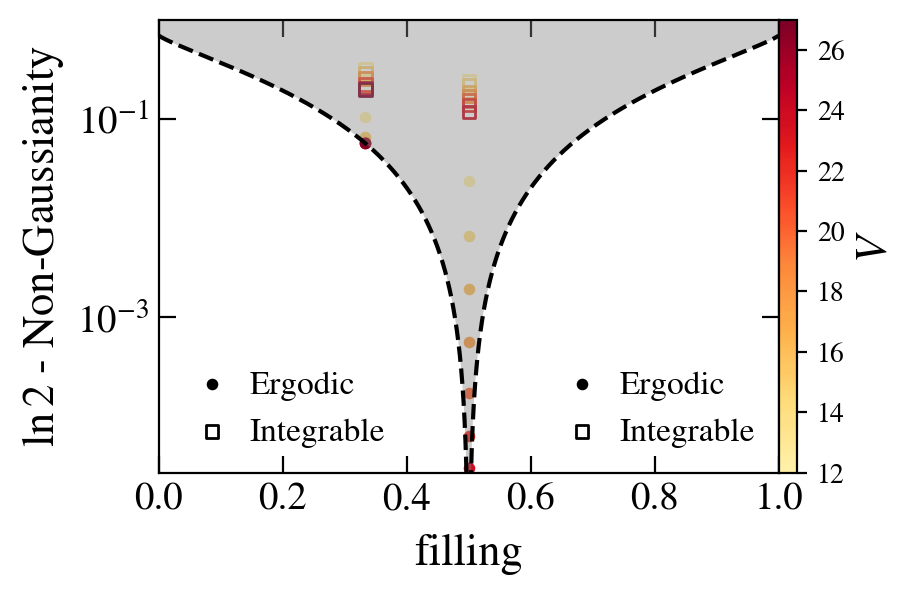

In [40]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex = True)

n = 1/2
f = 1
norm = matplotlib.colors.Normalize(
            vmin=12,
            vmax=27)


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])

for n in [1/3, 1/2]:
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    
    NG_int = np.zeros(sizes.shape)
    NG_ch = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                
                dim = Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                NG = np.array(file.get('Non-Gaussianity'))[0] / L# - (2 * n - 1)**2
                
                NG_int[iiL] += np.mean(NG[10:-10]) if dim > 7e4 else np.mean(NG[idxE - num//2 : idxE + num//2])
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                NG = np.array(file.get('Non-Gaussianity'))[0] / L# - (2 * n - 1)**2
                
                NG_ch[iiL] += np.mean(NG[10:-10]) if dim > 7e4 else np.mean(NG[idxE - num//2 : idxE + num//2])
        else:
            print(name)
            
        # for M in [2, L/2, binom(L, L//2)]:
        #     ns = np.linspace(0, 1, int(1e4))
        #     tmp = (2*ns - 1)**2
        #     p = axis.plot(ns, tmp + (1 - tmp) * 3 / (M + 2), color=s_m_L.to_rgba(L))
    
    for iiL, L in enumerate(sizes):
        axis.scatter(n, np.log(2) - NG_ch[iiL], color=s_m_L.to_rgba(L), s=10)
        axis.scatter(n, np.log(2) - NG_int[iiL], color=s_m_L.to_rgba(L), s=20, marker='s', facecolor='None')

L=1e4
ns = np.linspace(0, 1, int(L)+1)
tmp = np.log(2) + ns*np.log(ns) + (1-ns)*np.log(1-ns)
axis.plot(ns, tmp, color = 'k', ls='--')
axis.fill_between(ns, 1, tmp, color='gray', lw=0, alpha=0.4)
# axis.annotate(r"Purity bound", fontsize=14, xy=(0.05, 5e-3), xycoords='data', color='k', rotation=-50)
# axis.annotate(r"Purity bound", fontsize=14, xy=(0.7, 5e-3), xycoords='data', color='k', rotation=50)

handles = []
sc = axis.scatter(np.nan, np.nan, color='k', label = r"Ergodic", s=10); handles.append(sc)
sc = axis.scatter(np.nan, np.nan, color='k', label = r"Integrable", s=20, marker='s', facecolor='None'); handles.append(sc)

# fil = axis.fill_between(ns, tmp + (1 - tmp) * 3 / (12/2 + 2), tmp + (1 - tmp) * 3 / (27/2 + 2), color='blue', lw=0, alpha=0.2, label=r"$M=V/2$")
# fil = axis.fill_between(ns, tmp + (1 - tmp) * 3 / (12 + 2), tmp + (1 - tmp) * 3 / (27 + 2), color='blue', lw=0, alpha=0.4, label=r"$M=V$")
# handles.append(fil)
# fil = axis.fill_between(ns, tmp + (1 - tmp) * 3 / (binom(12, 12*ns)**1 + 2), tmp + (1 - tmp) * 3 / (binom(27, 27*ns)**1 + 2), color='green', lw=0, alpha=0.4, label=r"$M=\mathcal{D}$")
# handles.append(fil)

fig_help.set_plot_elements(axis, ylabel=r"$\ln{2}$ - Non-Gaussianity", xlabel = r"filling", font_size=14, set_legend=True, xlim=(0,1), ylim=(0.9*min(np.log(2) - NG_ch),1), xscale='linear', yscale='log')
leg1 = fig_help.set_legend(axis, fontsize=12, loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, anchor=(-0.01, -0.01), handles = handles[-2:])
fig_help.set_legend(axis, fontsize=12, loc = 'lower right', ncol=1, columnspacing=0.4, frameon=False, anchor=(1.01, -0.01), handles = handles[:2])
fig.add_artist(leg1)

cbar_ax = axis.inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m_L, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$V$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')


fig.subplots_adjust(wspace = 0.3, hspace=0.05)
# fig.savefig("plots_mixing/Fig_intro.pdf", bbox_inches = 'ti /ght', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


Text(0.69, 0.25, '(b) $n=\\frac{1}{3}$')

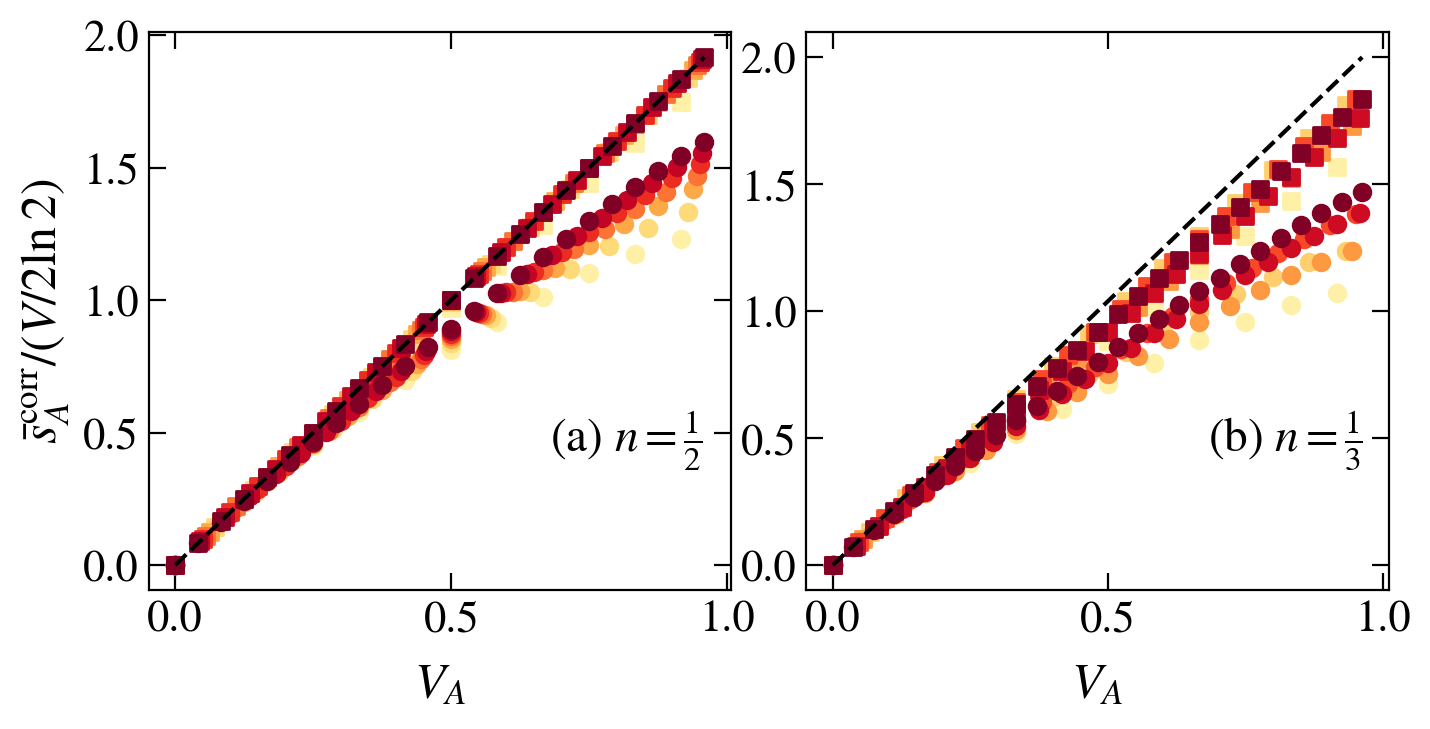

In [60]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8,3.7), dpi = 200, sharex=False)

for iin, n in enumerate([1/2, 1/3]):

    f = n
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)

    norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes))


    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

    s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m_L.set_array([])
    Purity_int = np.zeros(sizes.shape)
    Purity_ch = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    
    term1 = n * np.log(n)
    term2 = (1-n) * np.log(1-n)
    Hn = -term1 - term2
    for iiL, L in enumerate(sizes):
        col = s_m_L.to_rgba(L)
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                
                dim = Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                ind = np.arange(idxE - num//2, idxE + num//2, 1)
                if dim > 500:
                    ind = np.arange(idxE - 250, idxE + 250, 1)
                # S = Hn - np.mean(np.array(file.get('entropy_corr_mat'))[:, ind], axis=1) / subsystem
                S = np.mean(np.array(file.get('entropy_corr_mat'))[:, ind], axis=1) / (L//2 * np.log(2))
                axis[iin].scatter(subsystem / L, S, color=col)
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                ind = np.arange(idxE - num//2, idxE + num//2, 1)
                if dim > 500:
                    ind = np.arange(idxE - 250, idxE + 250, 1)
                S = np.mean(np.array(file.get('entropy_corr_mat'))[:, ind], axis=1) / (L//2 * np.log(2))
                axis[iin].scatter(subsystem / L, S, color=col, marker='s')
                # axis[iin].scatter(subsystem / L, S)
                # Purity_ch[iiL] = np.mean(S)
        else:
            print(name)
    
    # print(Purity_int)
    # axis[iin].scatter((n*sizes), Purity_int)
    # axis[iin].scatter((n*sizes), Purity_ch)
    # axis[iin].set_ylim(0, 0.7)
    
    axis[iin].plot(subsystem / L, subsystem / (L//2), ls='--', color='k')
    fig_help.set_plot_elements(axis[iin], ylabel="" if iin else r"$\bar{s}_A^{\rm corr}/(V/2\ln{2})$", xlabel=r"$V_A$", font_size=16, set_legend=True, xscale='linear', yscale='linear')

fig.subplots_adjust(wspace = 0.13, hspace=0.02)
axis[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
axis[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.5 [2.01915182e-02 3.98961293e-03 1.10216958e-03 3.36080066e-04
 1.05357197e-04 4.27430862e-05 2.17048229e-05]
0.3333333333333333 [0.07295991 0.05911893 0.05689952 0.05646807 0.0564672  0.05647903]


Text(0.69, 0.25, '(b) $n=\\frac{1}{3}$')

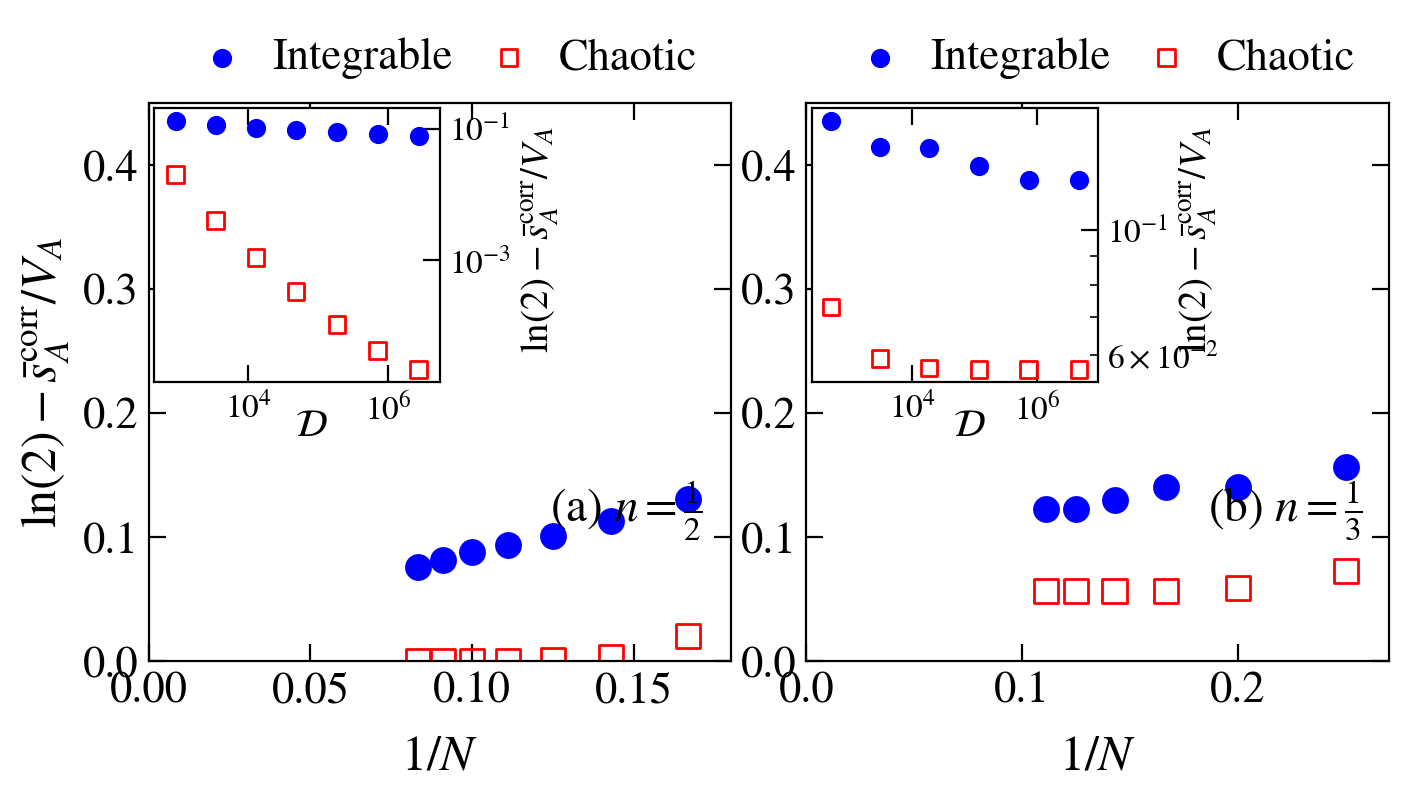

In [30]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=1, ncols=2, figsize=(8,3.7), dpi = 200, sharex=False)

for iin, n in enumerate([1/2, 1/3]):

    ax2 = axa[iin].inset_axes([0.01, 0.5, 0.49, 0.49])
    # axis = [ax2, axa[iin]]
    axis = [axa[iin], ax2]

    f = n
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)

    Scorr_int = np.zeros(sizes.shape)
    Scorr_ch = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    # Pinf = 4*n * (1-n)
    # Sleading = -n*np.log(n) - (1-n)*np.log(1-n)
    # print(f, Sinf)
    
    term2 = (1-n) * np.log(1-n)
    Hn = -(n) * np.log(n) - (1-n) * np.log(1-n)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                gaps = np.diff(Ex)
                
                dim = Ex.size
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                ind = np.arange(idxE - num//2, idxE + num//2, 1)
                if dim > 500:
                    ind = np.arange(idxE - 250, idxE + 250, 1)
                Scorr_int[iiL] += np.log(2) - np.mean(np.array(file.get('entropy_corr_mat'))[idx][ind]) / (LA)
                
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = Ex.size
                
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([500, dim//10])
                ind = np.arange(idxE - num//2, idxE + num//2, 1)
                if dim > 500:
                    ind = np.arange(idxE - 250, idxE + 250, 1)
                Scorr_ch[iiL] += np.log(2) - np.mean(np.array(file.get('entropy_corr_mat'))[idx][ind]) / (LA)
        else:
            print(name)
        
    Chaotic_GOE = 9 / (2 + dims/4)
    Chaotic_GUE = 4 / (1 + dims/4)

    particle_num = sizes * n
    axis[0].scatter(1/particle_num, Scorr_int, s=75, color='blue')
    axis[1].scatter(binom(sizes, particle_num), Scorr_int, s=35, color='blue', label='Integrable')

    axis[0].scatter(1/particle_num, Scorr_ch, s=75, color='red', marker='s', facecolor='None')
    axis[1].scatter(binom(sizes, particle_num), Scorr_ch, s=35, color='red', label='Chaotic', marker='s', facecolor='None')
    
    print(n, Scorr_ch)
    z = np.linspace(0, 0.1, 1000)
    # axis[0].plot(z, 9 / (2 + 1.5/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
    # # axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # axis[0].plot(z, 9 / (2 + 1/z), ls='--', lw=2, color='gray', label=r"$O(V)$")
    # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
    # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
    # def fit_purity(x, a, b):
    #     dim = binom(x, x*n)
    #     return 3 * (1 - Pinf) / (2 + b * x)# + a / dim**0.5
        
    # def fit_purity(x: float, a: int, b: int):
    #     dim = binom(x, x*n)
    #     prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * n * x))
    #     return 3 * (1 - Pinf) / (2 + b * n * x) + prob

    # pars, pconv, fit_info, msg, _ = fit(fit_purity,
    #                         xdata = sizes[1:],
    #                         ydata = Purity_int[1:],
    #                         full_output=True, maxfev=10000)
    # print("Int", *pars)
    # xx = np.linspace(0, max(1/(sizes-1)), 10000)
    # axis[0].plot( xx / n, fit_purity(1/xx, *pars), ls='--',  color = 'blue')
    # axis[0].plot( xx / n, fit_purity(1/xx, 0, 1), ls=':',  color = 'blue')
    
    # def fit_purity(x: float, a: int, b: int):
    #     dim = binom(x, x*n)
    #     prob = 4 * x * n * (1-n) / dim * (1 - 3 / (2 + b * dim))
    #     return 3 * (1 - Pinf) / (2 + b * dim) + prob


    # xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
    # pars, pconv, fit_info, msg, _ = fit(fit_purity,
    #                         xdata = sizes[1:],
    #                         ydata = Purity_ch[1:],
    #                         full_output=True, maxfev=10000)
    # print("Ch", *pars)
    # xx = np.linspace(min(sizes)-2, max(sizes)+2, 10000)
    # # xx = np.linspace(binom(min(sizes), min(sizes) * n)/2, binom(max(sizes), max(sizes) * n)*200, 10000)
    # # xx = binom(xx, xx*n)
    # axis[1].plot(binom(xx, xx*n), fit_purity(xx, *pars), ls='-.',  color = 'red')

    # xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
    # Ns = xx*n
    # dims = binom(xx, Ns)
    # prob = 1 - np.exp(-binom(dims/20, ))
    # axis[1].plot(dims, 4 * xx * n * (1-n) / dims, ls='-', color='k')
    
    fig_help.set_plot_elements(axa[iin], ylabel="" if iin else r"$\ln(2)-\bar{s}_A^{\rm corr}/V_A$", xlabel=r"$1/N$", font_size=16, set_legend=True, xlim=(0, 0.09/n), xscale='linear', yscale='linear')
    fig_help.set_plot_elements(ax2, ylabel=r"$\ln(2)-\bar{s}_A^{\rm corr}/V_A$", xlabel=r"$\mathcal{D}$", font_size=12, set_legend=True, xscale='log', yscale='log')
    
    fig_help.set_legend(axis[1], fontsize=16, loc = 'lower left', ncol=2, columnspacing=0.4, frameon=False, anchor=(-.04, 0.96))
    axis[0].set_ylim(0, 0.45)
    # axis[1].set_ylim(5e-8, None)
    axis[1].set_xlim(binom(min(sizes), min(sizes) * n)/2, binom(max(sizes), max(sizes) * n)*2)


    # ax2.xaxis.set_label_position("top")
    # ax2.xaxis.tick_top()
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    ax2.xaxis.set_label_coords(0.55, -0.1)
    ax2.yaxis.set_label_coords(1.28, .52)

fig.subplots_adjust(wspace = 0.13, hspace=0.02)
axa[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')
axa[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.69, 0.25), xycoords='axes fraction')

No handles with labels found to put in legend.
No handles with labels found to put in legend.


[Text(12, 0, '12'),
 Text(14, 0, '14'),
 Text(16, 0, '16'),
 Text(18, 0, '18'),
 Text(20, 0, '20'),
 Text(22, 0, '22'),
 Text(24, 0, '24')]

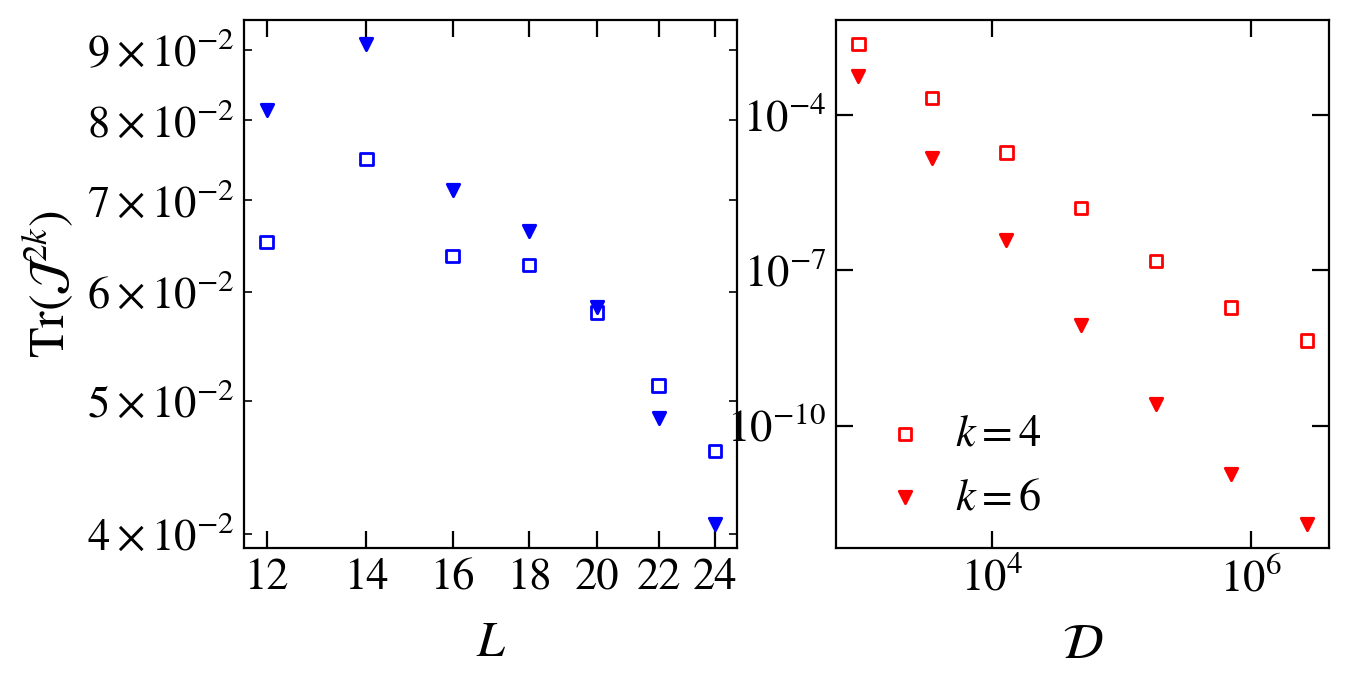

In [15]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(7,3.5), dpi = 200, sharex=False)
# ax2 = ax.inset_axes([0.065, 0.04, 0.49, 0.49])
# axis = [ax2, ax]

n = 1/2
f = 1
sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)

Purity_int = np.zeros(sizes.shape)
Purity_ch = np.zeros(sizes.shape)
Trace4_int = np.zeros(sizes.shape)
Trace4_ch = np.zeros(sizes.shape)
Trace6_int = np.zeros(sizes.shape)
Trace6_ch = np.zeros(sizes.shape)

dims = np.zeros(sizes.shape)
BOUNDARY_COND = 'ABC'

for iiL, L in enumerate(sizes):
    subsystem = np.arange(0, L, 1)
    N = int(n * L)
    LA = int(f * L) if f > 0 else 1
    idx = np.argmin( np.abs(subsystem - LA) )
    if LA == L: idx = -1
    
    V1 = 0.55
    V2 = 0
    t2 = 0
    
    name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energies')[0])
            gaps = np.diff(Ex)
            
            dim = Ex.size
            dims[iiL] = binom(L, N)
            E_av = np.mean(Ex)
            idxE = np.argmin(np.abs(Ex - E_av))
            num = min([500, dim//10])
            P = np.array(file.get('Purity'))[idx] / LA# - (2 * n - 1)**2
            Purity_int[iiL] += np.mean(P[10:-10]) if dim > 7e4 else np.mean(P[idxE - num//2 : idxE + num//2])
            
            x = np.array(file.get('Trace4'))[idx] / LA - P**2
            Trace4_int[iiL] += np.mean(x[10:-10]) if dim > 7e4 else np.mean(x[idxE - num//2 : idxE + num//2])
            x = np.array(file.get('Trace6'))[idx] / LA - P**3
            Trace6_int[iiL] += np.mean(x[10:-10]) if dim > 7e4 else np.mean(x[idxE - num//2 : idxE + num//2])
            
    else:
        print(name)
    V1=0.55
    V2 = 2
    t2 = 2
    name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energies')[0])
            dim = Ex.size
            
            E_av = np.mean(Ex)
            idxE = np.argmin(np.abs(Ex - E_av))
            num = min([500, dim//10])
            P = np.array(file.get('Purity'))[idx] / LA 
            Purity_ch[iiL] += np.mean(P[10:-10]) if dim > 7e4 else np.mean(P[idxE - num//2 : idxE + num//2])
            
            x = np.array(file.get('Trace4'))[idx] / LA - P**2
            Trace4_ch[iiL] += np.mean(x[10:-10]) if dim > 7e4 else np.mean(x[idxE - num//2 : idxE + num//2])
            x = np.array(file.get('Trace6'))[idx] / LA - P**3
            Trace6_ch[iiL] += np.mean(x[10:-10]) if dim > 7e4 else np.mean(x[idxE - num//2 : idxE + num//2])
    else:
        print(name)
    
Chaotic_GOE = 9 / (2 + dims/4)
Chaotic_GUE = 4 / (1 + dims/4)

# axis[0].scatter(sizes, Purity_int, s=20, color='blue', marker='o', label=r'$k=2$')
axis[0].scatter(sizes, Trace4_int, s=20, color='blue', marker='s', facecolor='None')
axis[0].scatter(sizes, Trace6_int, s=20, color='blue', marker='v')

# axis[1].scatter(binom(sizes, sizes*n), Purity_ch, s=20, color='red', marker='o')
axis[1].scatter(binom(sizes, sizes*n), Trace4_ch, s=20, color='red', label=r'$k=4$', marker='s', facecolor='None')
axis[1].scatter(binom(sizes, sizes*n), Trace6_ch, s=20, color='red', label=r'$k=6$', marker='v')

# z = np.linspace(0, 0.1, 1000)
# # axis[0].plot(z, 9 / (2 + 1.5/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
# # # axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
# # axis[0].plot(z, 9 / (2 + 1/z), ls='--', lw=2, color='gray', label=r"$O(V)$")
# # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
# # axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
# def fit_purity(x: float, a: int, b: int):
#     return 9 / (2 + b * x)

# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = sizes[2:],
#                         ydata = Purity_int[2:],
#                         full_output=True, maxfev=10000)
# print("Int", *pars)
# xx = np.linspace(0, max(1/(sizes-1)), 10000)
# # axis[0].plot( xx, fit_purity(1/xx, *pars), ls='--',  color = 'blue')


# xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = dims[1:],
#                         ydata = Purity_ch[1:],
#                         full_output=True, maxfev=10000)
# print(*pars)
# xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
# xx = binom(xx, xx*n)
# # axis[1].plot(xx, fit_purity(xx, *pars), ls='-.',  color = 'red')

fig_help.set_plot_elements(axis[0], ylabel=r"${\rm Tr}(\mathcal{J}^{2k})$", xlabel=r"$L$", font_size=16, set_legend=True, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$\mathcal{D}$", font_size=16, set_legend=True, xscale='log', yscale='log')
fig_help.set_legend(axis[0], fontsize=16, loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False)
fig_help.set_legend(axis[1], fontsize=16, loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False)
# axis[0].set_ylim(0, None)
# axis[1].set_ylim(5e-8, None)
# axis[1].set_xlim(binom(min(sizes), min(sizes) * n)/1.5, binom(max(sizes), max(sizes) * n)*1.5)

axis[0].set_xticks([12, 14, 16, 18, 20, 22, 24])
axis[0].set_xticklabels(["12", "14", "16", "18", "20", "22", "24"])

# axis[0].xaxis.set_label_position("top")
# axis[0].xaxis.tick_top()
# axis[0].yaxis.set_label_position("right")
# axis[0].yaxis.tick_right()
# axis[0].xaxis.set_label_coords(.3, 1.15)
# axis[0].yaxis.set_label_coords(1.19, .52)

# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/_L=24,J=1_N=12.hdf5
12 570
14 570
16 570
18 570
20 570
22 570
24 570
26 464
28 500
../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/_L=27,J=1_N=9.hdf5
12 570
15 570
18 570
21 570
24 570
27 530
30 88


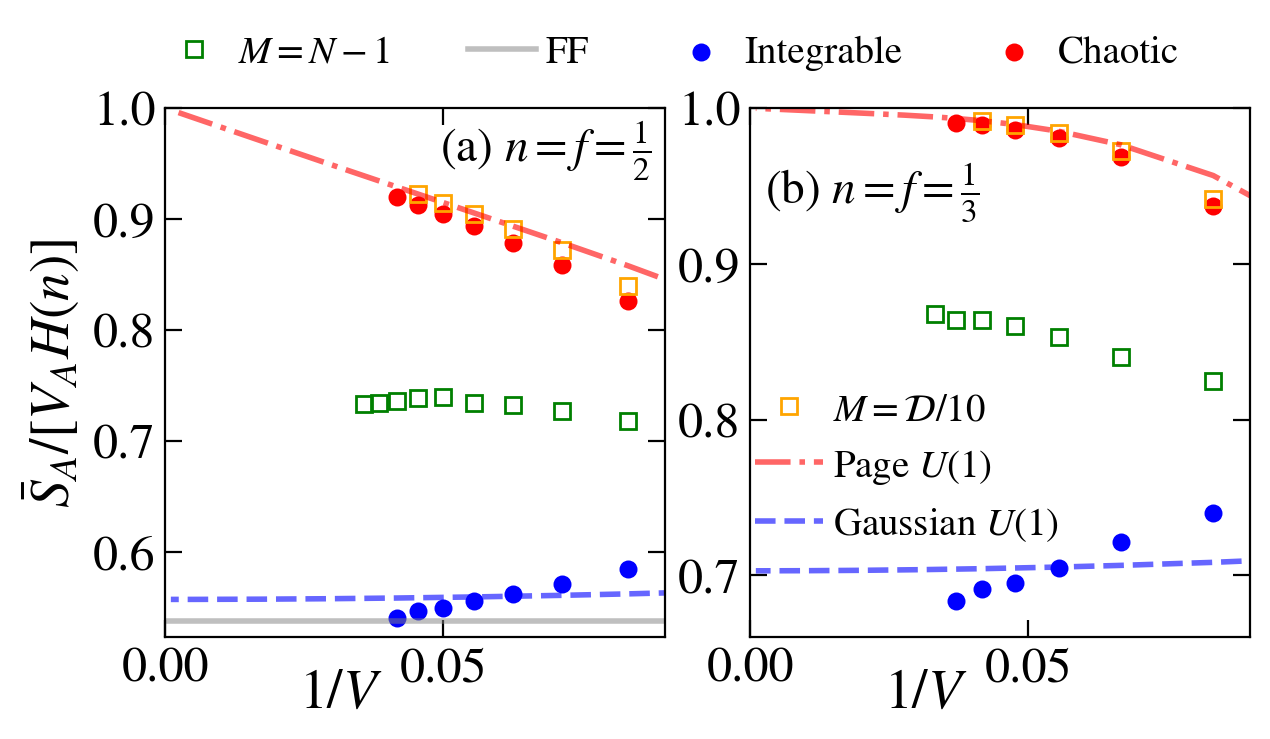

In [204]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(7,3.5), dpi = 200, sharex=True)

BOUNDARY_COND = 'ABC'
n = 1/2
handles_ = []
for iin, n in enumerate([1/2, 1/3]):
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    sizes2 = np.arange(12, 31 if n == 1/3 else 29, int(1/n))

    Svn_int = np.zeros(sizes.shape)
    Svn_ch = np.zeros(sizes.shape)
    Svn_int_var = np.zeros(sizes.shape)
    Svn_ch_var = np.zeros(sizes.shape)
    dims = np.zeros(sizes.shape)
    
    Svn_mixture_N = np.zeros(sizes2.shape); Svn_mixture_N.fill(np.nan)
    Svn_mixture_D = np.zeros(sizes.shape); Svn_mixture_D.fill(np.nan)
    
    Svn_mixture_N_var = np.zeros(sizes2.shape); Svn_mixture_N_var.fill(np.nan)
    Svn_mixture_D_var = np.zeros(sizes.shape); Svn_mixture_D_var.fill(np.nan)
    
    Hn = -(n) * np.log(n) - (1-n) * np.log(1-n)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        # LA = 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V2 = 0
        t2 = 0
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * Hn)
                
                dim = int(binom(L, N))
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                # idxE = np.argmax(Svn)
                
                num = min([1000, dim//10])
                if dim > 7e4 and Svn.size > 1000: Svn = Svn[500:-500]
                
                # print("INT", L, N, num, Ex.size, Svn.size)
                Svn_int[iiL] += np.mean(Svn[10:-10]) if dim > 7e4 else np.mean(Svn[idxE - num//2 : idxE + num//2])
                Svn_int_var[iiL] += np.var(Svn[10:-10]) if dim > 7e4 else np.var(Svn[idxE - num//2 : idxE + num//2])
        else:
            print(name)
            
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * Hn)
                
                dim = int(binom(L, N))
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                # idxE = np.argmax(Svn)
                
                num = min([1000, dim//10])
                if dim > 7e4 and Svn.size > 1000: Svn = Svn[500:-500]
                
                # print("CH", L, N, num, Ex.size, Svn.size)
                Svn_ch[iiL] += np.mean(Svn[10:-10]) if dim > 7e4 else np.mean(Svn[idxE - num//2 : idxE + num//2])
                Svn_ch_var[iiL] += np.var(Svn[10:-10]) if dim > 7e4 else np.var(Svn[idxE - num//2 : idxE + num//2])
        else:
            print(name)
        # print(dim_tot, binom(L, N))
        prefix = "../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/"
        # prefix = "../../Quadratic/results/SYK2/GOE/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/"
        name = prefix + f"_L=%d,J=1_N=%d.hdf5"%(L,N)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                # print(L, gams)
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(L, gams[2])
                # Svn_mixture_N[iiL] = np.array(file.get('entropy'))[idx, 3] / (LA * Hn)
                Svn_mixture_D[iiL] = np.array(file.get('entropy'))[idx, 10] / (LA * Hn)
                Svn_mixture_D_var[iiL] = np.sqrt(np.array(file.get('entropy_var'))[idx, 10]) / (LA * Hn)# / np.sqrt(R)
        else:
            print(name)
    for iiL, L in enumerate(sizes2):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        # LA = 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        prefix = "../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
        # prefix = "../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
        name = prefix + f"_L=%d,J=1_N=%d.hdf5"%(L,N)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                R = np.array(file.get('realisations'))
                print(L, R)
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(L, N, gams[3], gams[4])
                Svn_mixture_N[iiL] = np.array(file.get('entropy'))[idx, 3] / (LA * Hn)
                Svn_mixture_N_var[iiL] = np.sqrt(np.array(file.get('entropy_var'))[idx, 3]) / (LA * Hn)# / np.sqrt(R)
        else:
            print(name)
    axis[iin].scatter(1/sizes, Svn_int, s=30, label='Integrable' if iin==0 else "", color='blue', marker='o')#'s' if iin else 'o')#, facecolor='None' if iin else 'blue')
    # axis[iin].errorbar(x=1/sizes, y=Svn_int, yerr=Svn_int_var, markersize=4, label='Integrable' if iin==0 else "", color='blue', marker='o', ls='None', capsize=2)
    # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')

    p = axis[iin].scatter(1/sizes, Svn_ch, s=30, label='Chaotic' if iin==0 else "", color='red', marker='o')#'s' if iin else 'o')#, facecolor='None' if iin else 'red')
    # p = axis[iin].errorbar(x=1/sizes, y=Svn_ch, yerr=Svn_ch_var, markersize=4, label='Chaotic' if iin==0 else "", color='red', marker='o', ls='None', capsize=2)
    
    # axis[iin].errorbar(x=1/sizes2, y=Svn_mixture_N, yerr=Svn_mixture_N_var, markersize=6, label='$M=0.9N$' if iin==0 else "", color='Green', marker='s', markerfacecolor='None', capsize=2, ls='None')
    # line = axis[iin].errorbar(x=1/sizes, y=Svn_mixture_D, yerr=Svn_mixture_D_var, markersize=6, label='$M=\mathcal{D}/10$' if iin==1 else "", color='Orange', marker='s', markerfacecolor='None', capsize=2, ls='None')
    # handles_.append(line)
    axis[iin].plot(1/sizes2, Svn_mixture_N, markersize=6, label='$M=N-1$' if iin==0 else "", color='Green', marker='s', markerfacecolor='None', lw=0)
    line, = axis[iin].plot(1/sizes, Svn_mixture_D, markersize=6, label='$M=\mathcal{D}/10$' if iin==1 else "", color='Orange', marker='s', markerfacecolor='None', lw=0)
    handles_.append(line)
    # axis.scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')

    # z = np.array([*np.logspace(-3, -1, 2000), 1/np.arange(12, 100, int(1/n))])
    Lz = np.arange(6, 1000, int(1/n) )
    yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * Hn)
    line, = axis[iin].plot(1/Lz, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $U(1)$" if iin else "")
    handles_.append(line)
    line, = axis[iin].plot(1/Lz, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * Hn) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$" if iin else "")
    handles_.append(line)
    fig_help.set_plot_elements(axis[iin], ylabel=r"$\bar{S}_A/[V_AH(n)]$" if iin==0 else"", xlabel=r"$1/V$", font_size=18, set_legend=True, xlim=(0,0.09), xscale='linear', yscale='linear')
    axis[iin].set_ylim(0.94 * min(yy[~np.isnan(yy)]), 1)
# axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")
axis[0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF")

fig_help.set_legend(axis[0], fontsize=14, loc='lower left', ncol=4, anchor=(-0.08, 1.005))
fig_help.set_legend(axis[1], fontsize=14, loc='lower left', ncol=1, anchor=(-0.06, 0.11), handles = [handles_[3], handles_[5], handles_[4]])

axis[0].annotate(r"(a) $n=f=\frac{1}{2}$", fontsize=17, xy=(0.55, 0.9), xycoords='axes fraction')
axis[1].annotate(r"(b) $n=f=\frac{1}{3}$", fontsize=17, xy=(0.03, 0.82), xycoords='axes fraction')
axis[0].xaxis.set_label_coords(0.35, -0.06)
axis[1].xaxis.set_label_coords(0.35, -0.06)

fig.subplots_adjust(wspace = 0.17, hspace=0.02)

fig.savefig("plots_mixing/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)

../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/_L=24,J=1_N=12.hdf5
12 825
14 825
16 500
18 489
20 747
22 787
24 600
12 825
14 825
16 500
18 496
20 753
22 782
24 600
12 825
14 825
16 500
18 496
20 739
22 784
24 600
../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/_L=24,J=1_N=12.hdf5
12 825
14 825
16 500
18 489
20 747
22 787
24 600


No handles with labels found to put in legend.
No handles with labels found to put in legend.


12 825
14 825
16 500
18 496
20 753
22 782
24 600
12 825
14 825
16 500
18 496
20 739
22 784
24 600


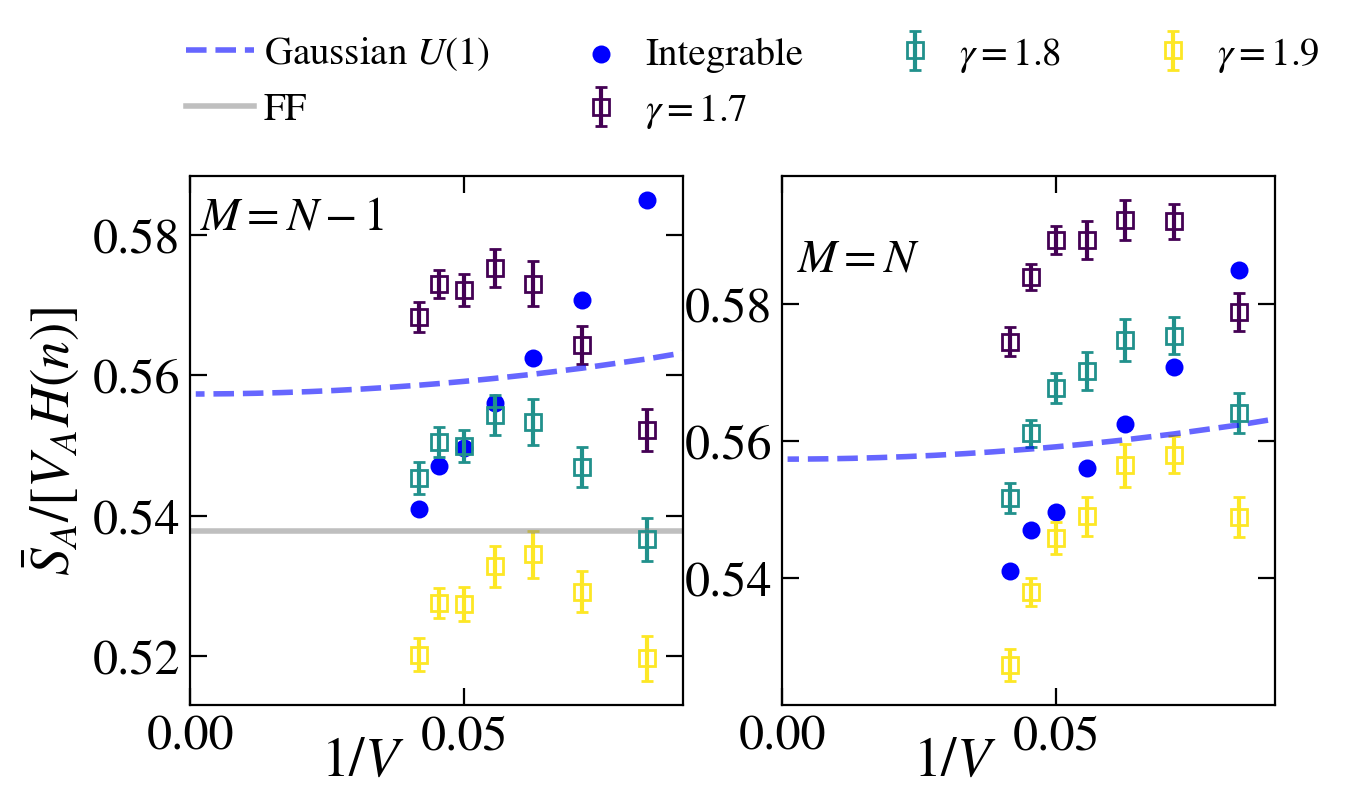

In [202]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(7,3.5), dpi = 200, sharex=True)

BOUNDARY_COND = 'ABC'
n = 1/2
handles_ = []
# for iin, n in enumerate([1/2]):
for iin, Midx in enumerate([3, 5]):
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    sizes2 = np.arange(12, 31 if n == 1/3 else 25, int(1/n))

    Svn_int = np.zeros(sizes.shape)
    Svn_ch = np.zeros(sizes.shape)
    Svn_int_var = np.zeros(sizes.shape)
    Svn_ch_var = np.zeros(sizes.shape)
    dims = np.zeros(sizes.shape)
    
    Svn_mixture_N = np.zeros(sizes2.shape); Svn_mixture_N.fill(np.nan)
    Svn_mixture_D = np.zeros(sizes.shape); Svn_mixture_D.fill(np.nan)
    
    Svn_mixture_N_var = np.zeros(sizes2.shape); Svn_mixture_N_var.fill(np.nan)
    Svn_mixture_D_var = np.zeros(sizes.shape); Svn_mixture_D_var.fill(np.nan)
    
    Hn = -(n) * np.log(n) - (1-n) * np.log(1-n)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        # LA = 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V2 = 0
        t2 = 0
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * Hn)
                
                dim = int(binom(L, N))
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                # idxE = np.argmax(Svn)
                
                num = min([1000, dim//10])
                if dim > 7e4 and Svn.size > 1000: Svn = Svn[500:-500]
                
                # print("INT", L, N, num, Ex.size, Svn.size)
                Svn_int[iiL] += np.mean(Svn[10:-10]) if dim > 7e4 else np.mean(Svn[idxE - num//2 : idxE + num//2])
                Svn_int_var[iiL] += np.var(Svn[10:-10]) if dim > 7e4 else np.var(Svn[idxE - num//2 : idxE + num//2])
        else:
            print(name)
            
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * Hn)
                
                dim = int(binom(L, N))
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                # idxE = np.argmax(Svn)
                
                num = min([1000, dim//10])
                if dim > 7e4 and Svn.size > 1000: Svn = Svn[500:-500]
                
                # print("CH", L, N, num, Ex.size, Svn.size)
                Svn_ch[iiL] += np.mean(Svn[10:-10]) if dim > 7e4 else np.mean(Svn[idxE - num//2 : idxE + num//2])
                Svn_ch_var[iiL] += np.var(Svn[10:-10]) if dim > 7e4 else np.var(Svn[idxE - num//2 : idxE + num//2])
        else:
            print(name)
        # print(dim_tot, binom(L, N))
        prefix = "../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/"
        # prefix = "../../Quadratic/results/RP/GOE/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/"
        # prefix = "../../Quadratic/results/SYK2/GOE/Entropy/MixingExpMany_um/RandomChoice/SameHamiltonian/"
        name = prefix + f"_L=%d,J=1_N=%d.hdf5"%(L,N)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                # print(L, gams)
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(L, gams[2])
                # Svn_mixture_N[iiL] = np.array(file.get('entropy'))[idx, 3] / (LA * Hn)
                Svn_mixture_D[iiL] = np.array(file.get('entropy'))[idx, 10] / (LA * Hn)
                Svn_mixture_D_var[iiL] = np.sqrt(np.array(file.get('entropy_var'))[idx, 10]) / (LA * Hn)# / np.sqrt(R)
        else:
            print(name)
            
    gammas = np.arange(1.7, 1.91, 0.1)
    s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(
        vmin=min(gammas),
        vmax=max(gammas)))
    s_m.set_array([])
    for gx in gammas:
        cols = s_m.to_rgba(gx)
        for iiL, L in enumerate(sizes2):
            subsystem = np.arange(0, L, 1)
            N = int(L * n)
            LA = int(n * L)
            # LA = 1
            idx = np.argmin( np.abs(subsystem - LA) )
            if LA == L: idx = -1
            # prefix = "../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
            # # prefix = "../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
            # name = prefix + f"_L=%d,J=1_N=%d.hdf5"%(L,N)
            
            prefix = "../../Quadratic/results/RP/GOE/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
            
            # gx = 1.8
            name = prefix + f"_L=%d,J=1,g=%g_N=%d.hdf5"%(L,gx,N)
            if exists(name):
                with h5py.File(name, "r") as file:
                    gams = np.array(file.get('Gammas'))
                    R = np.array(file.get('realisations'))
                    print(L, R)
                    subsystem = np.array(file.get('subsystem_sizes'))
                    idx = np.argmin( np.abs(subsystem - LA) )
                    # print(L, N, gams[3], gams[4])
                    Svn_mixture_N[iiL] = np.array(file.get('entropy'))[idx, Midx] / (LA * Hn)
                    Svn_mixture_N_var[iiL] = np.sqrt(np.array(file.get('entropy_var'))[idx, Midx]) / (LA * Hn) / np.sqrt(R)
            else:
                print(name)
        axis[iin].errorbar(x=1/sizes2, y=Svn_mixture_N, yerr=Svn_mixture_N_var, markersize=6, label=r'$\gamma=%g$'%gx if iin==0 else "", color=cols, marker='s', markerfacecolor='None', capsize=2, ls='None')
        # axis[iin].plot(1/sizes2, Svn_mixture_N, markersize=6, label=r'$\gamma=%g$'%gx if iin==0 else "", color=cols, marker='s', markerfacecolor='None', lw=0)
    axis[iin].scatter(1/sizes, Svn_int, s=30, label='Integrable' if iin==0 else "", color='blue', marker='o')#'s' if iin else 'o')#, facecolor='None' if iin else 'blue')
    # axis[iin].errorbar(x=1/sizes, y=Svn_int, yerr=Svn_int_var, markersize=4, label='Integrable' if iin==0 else "", color='blue', marker='o', ls='None', capsize=2)
    # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')

    # p = axis[iin].scatter(1/sizes, Svn_ch, s=30, label='Chaotic' if iin==0 else "", color='red', marker='o')#'s' if iin else 'o')#, facecolor='None' if iin else 'red')
    # p = axis[iin].errorbar(x=1/sizes, y=Svn_ch, yerr=Svn_ch_var, markersize=4, label='Chaotic' if iin==0 else "", color='red', marker='o', ls='None', capsize=2)
    
    # axis[iin].errorbar(x=1/sizes2, y=Svn_mixture_N, yerr=Svn_mixture_N_var, markersize=6, label='$M=0.9N$' if iin==0 else "", color='Green', marker='s', markerfacecolor='None', capsize=2, ls='None')
    # line = axis[iin].errorbar(x=1/sizes, y=Svn_mixture_D, yerr=Svn_mixture_D_var, markersize=6, label='$M=\mathcal{D}/10$' if iin==1 else "", color='Orange', marker='s', markerfacecolor='None', capsize=2, ls='None')
    # handles_.append(line)
    # axis[iin].plot(1/sizes2, Svn_mixture_N, markersize=6, label='$M=0.9N$' if iin==0 else "", color='Green', marker='s', markerfacecolor='None', lw=0)
    # line, = axis[iin].plot(1/sizes, Svn_mixture_D, markersize=6, label='$M=\mathcal{D}/10$' if iin==1 else "", color='Orange', marker='s', markerfacecolor='None', lw=0)
    # handles_.append(line)
    # axis.scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')

    # z = np.array([*np.logspace(-3, -1, 2000), 1/np.arange(12, 100, int(1/n))])
    Lz = np.arange(6, 1000, int(1/n) )
    yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * Hn)
    line, = axis[iin].plot(1/Lz, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $U(1)$" if 1-iin else "")
    handles_.append(line)
    # line, = axis[iin].plot(1/Lz, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * Hn) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$" if iin else "")
    # handles_.append(line)
    fig_help.set_plot_elements(axis[iin], ylabel=r"$\bar{S}_A/[V_AH(n)]$" if iin==0 else"", xlabel=r"$1/V$", font_size=18, set_legend=True, xlim=(0,0.09), xscale='linear', yscale='linear')
    # axis[iin].set_ylim(0.64 * min(yy[~np.isnan(yy)]), 1)
# axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")
axis[0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF")

fig_help.set_legend(axis[0], fontsize=14, loc='lower left', ncol=4, anchor=(-0.08, 1.02))
fig_help.set_legend(axis[1], fontsize=14, loc='lower left', ncol=1, anchor=(-0.06, 0.11))#, handles = [handles_[3], handles_[5], handles_[4]])

axis[0].annotate(r"$M=N-1$", fontsize=17, xy=(0.02, 0.9), xycoords='axes fraction')
axis[1].annotate(r"$M=N$", fontsize=17, xy=(0.03, 0.82), xycoords='axes fraction')
axis[0].xaxis.set_label_coords(0.35, -0.06)
axis[1].xaxis.set_label_coords(0.35, -0.06)

fig.subplots_adjust(wspace = 0.2, hspace=0.02)

# fig.savefig("plots_mixing/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)

## $\bar{x} = \frac{1}{N}\sum_{i=1}^N x_i$
## $\sigma^2 = {\rm var}[x_i] = \frac{1}{N}\sum_{i=1}^N (x_i-\bar{x})^2$
## $\sigma_{\bar{x}}^2 = {\rm var}[\frac{1}{N}\sum_{i=1}^N x_i] = \frac{1}{N^2}\sum_{i=1}^N {\rm var}[x_i] = \frac{\sigma_{\bar{x}}^2}{{N}}$

12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=28,J=1_N=14.hdf5


No handles with labels found to put in legend.


12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=28,J=1_N=14.hdf5


No handles with labels found to put in legend.


12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=28,J=1_N=14.hdf5
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=28,J=1_N=14.hdf5
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8
20 10 9 9
22 11 10 9
24 12 11 10
26 13 12 11
28 14 13 12
12 6 5 5
14 7 6 6
16 8 7 7
18 9 8 8


...

No handles with labels found to put in legend.


12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
30 10 9 9
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=30,J=1_N=10.hdf5
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=30,J=1_N=10.hdf5


No handles with labels found to put in legend.


12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
30 10 9 9
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=30,J=1_N=10.hdf5
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=30,J=1_N=10.hdf5
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
30 10 9 9
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=30,J=1_N=10.hdf5
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/_L=30,J=1_N=10.hdf5
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
30 10 9 9
12 4 3 3
15 5 4 4
18 6 5 5
21 7 6 6
24 8 7 7
27 9 8 8
../../Quadratic/results/FreeFermions/dim=1/OBC/Ent

No handles with labels found to put in legend.


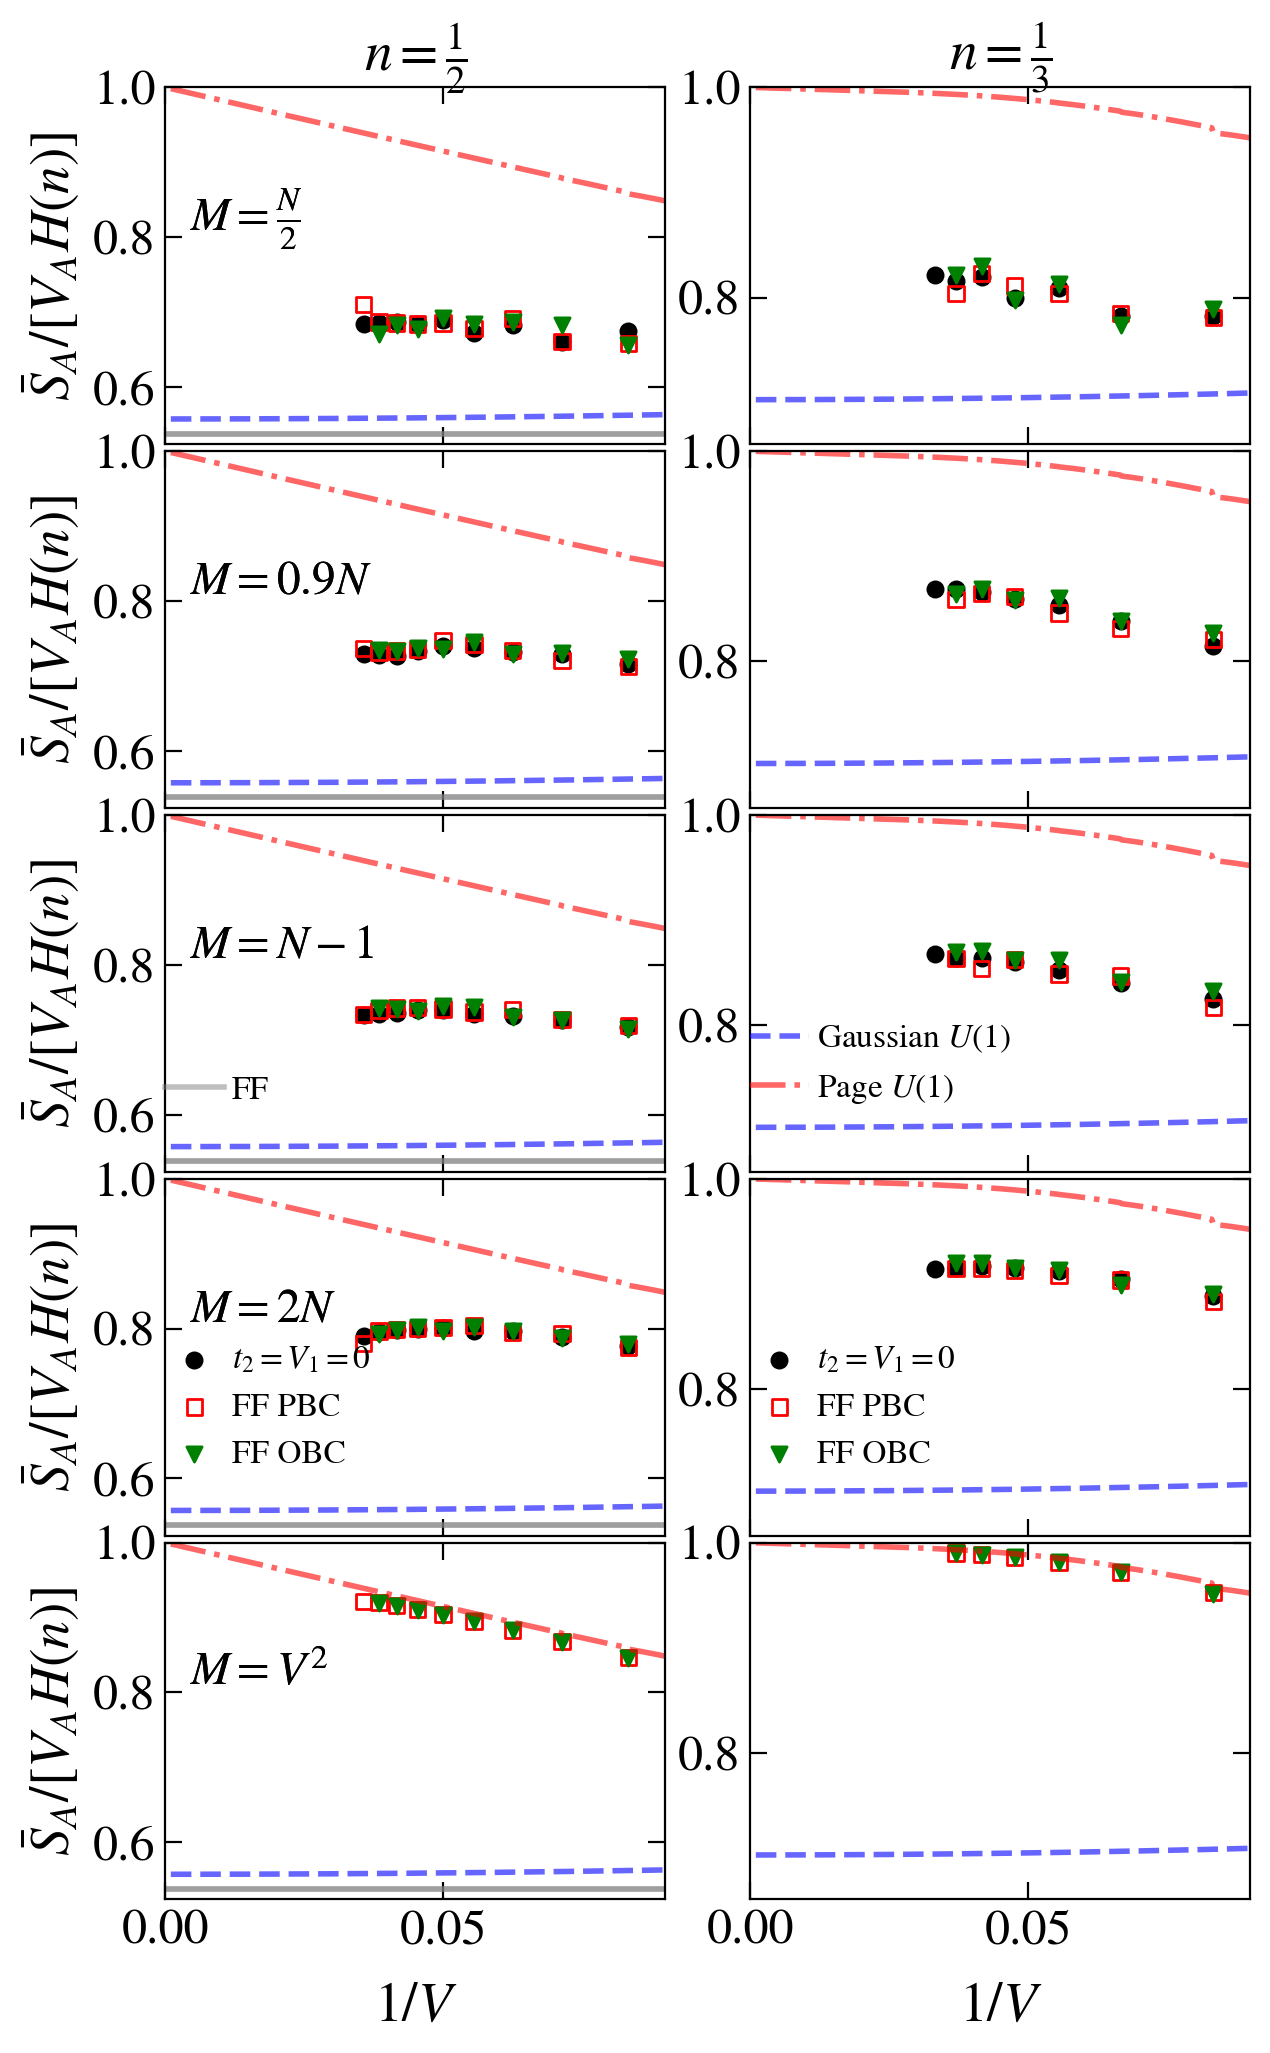

In [120]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=5, ncols=2, figsize=(7,12), dpi = 200, sharex=True)

BOUNDARY_COND = 'ABC'
n = 1/2
for iin, n in enumerate([1/2, 1/3]):
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    sizes2 = np.arange(12, 31 if n == 1/3 else 29, int(1/n))

    Hn = -(n) * np.log(n) - (1-n) * np.log(1-n)
    
    prefix1 = "../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
    prefix3 = "../../Quadratic/results/FreeFermions/dim=1/PBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
    prefix2 = "../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/MixingExpMany_um2/RandomChoice/SameHamiltonian/"
    marks = ['o', 's', 'v']
    cols = ['k', 'red', 'green']
    labs = [r'$t_2=V_1=0$', 'FF PBC', 'FF OBC']
    names = [r"$M=\frac{N}{2}$", r"$M=0.9N$", r"$M=N-1$", r"$M=2N$", r"$M=V^2$"]
    for iiM, Midx in enumerate([2, 4, 3, 6, -1]):
        for iip, prefix in enumerate([prefix1, prefix2, prefix3]):
            Svn = np.zeros(sizes2.shape)
            for iiL, L in enumerate(sizes2):
                subsystem = np.arange(0, L, 1)
                N = int(L * n)
                LA = int(n * L)
                # LA = 1
                idx = np.argmin( np.abs(subsystem - LA) )
                if LA == L: idx = -1
                name = prefix + f"_L=%d,J=1_N=%d.hdf5"%(L,N)
                if exists(name):
                    with h5py.File(name, "r") as file:
                        gams = np.array(file.get('Gammas'))
                        # print(L, gams)
                        subsystem = np.array(file.get('subsystem_sizes'))
                        idx = np.argmin( np.abs(subsystem - LA) )
                        print(L, N, gams[3], gams[4])
                        Svn[iiL] = np.array(file.get('entropy'))[idx, Midx] / (LA * Hn)
                else:
                    print(name)
            axis[iiM][iin].scatter(1/sizes2, Svn, s=30, color=cols[iip], marker=marks[iip], facecolor='None' if iip == 1 else cols[iip], label = labs[iip] if iiM == 3 else "")
    
        z = np.logspace(-3, 0, 2000)
        Lz = 1/z
        yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * Hn)
        axis[iiM][iin].plot(z, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $U(1)$" if iin and iiM == 2 else "")
        axis[iiM][iin].plot(z, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * Hn) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$" if iin and iiM == 2 else "")

        fig_help.set_plot_elements(axis[iiM][iin], ylabel=r"$\bar{S}_A/[V_AH(n)]$" if iin==0 else"", xlabel=r"$1/V$", font_size=18, set_legend=False, xlim=(0,0.09), xscale='linear', yscale='linear')
        axis[iiM][iin].set_ylim(0.94 * min(yy[~np.isnan(yy)]), 1)
    # axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")
        axis[iiM][0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF" if iiM == 2 else "") 

        fig_help.set_legend(axis[iiM][iin], fontsize=12, loc='lower left', ncol=1, anchor=(-0.06, 0.1))
# fig_help.set_legend(axis[1], fontsize=14, loc='lower left', ncol=1, anchor=(-0.06, 0.12))

        axis[iiM][0].annotate(names[iiM], fontsize=17, xy=(0.05, 0.6), xycoords='axes fraction')
# axis[1].annotate(r"(b) $n=f=\frac{1}{3}$", fontsize=17, xy=(0.03, 0.82), xycoords='axes fraction')
# axis[0].xaxis.set_label_coords(0.35, -0.06)
# axis[1].xaxis.set_label_coords(0.35, -0.06)
axis[0][0].set_title(r"$n=\frac{1}{2}$", fontsize=20)
axis[0][1].set_title(r"$n=\frac{1}{3}$", fontsize=20)

fig.subplots_adjust(wspace = 0.17, hspace=0.02)


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


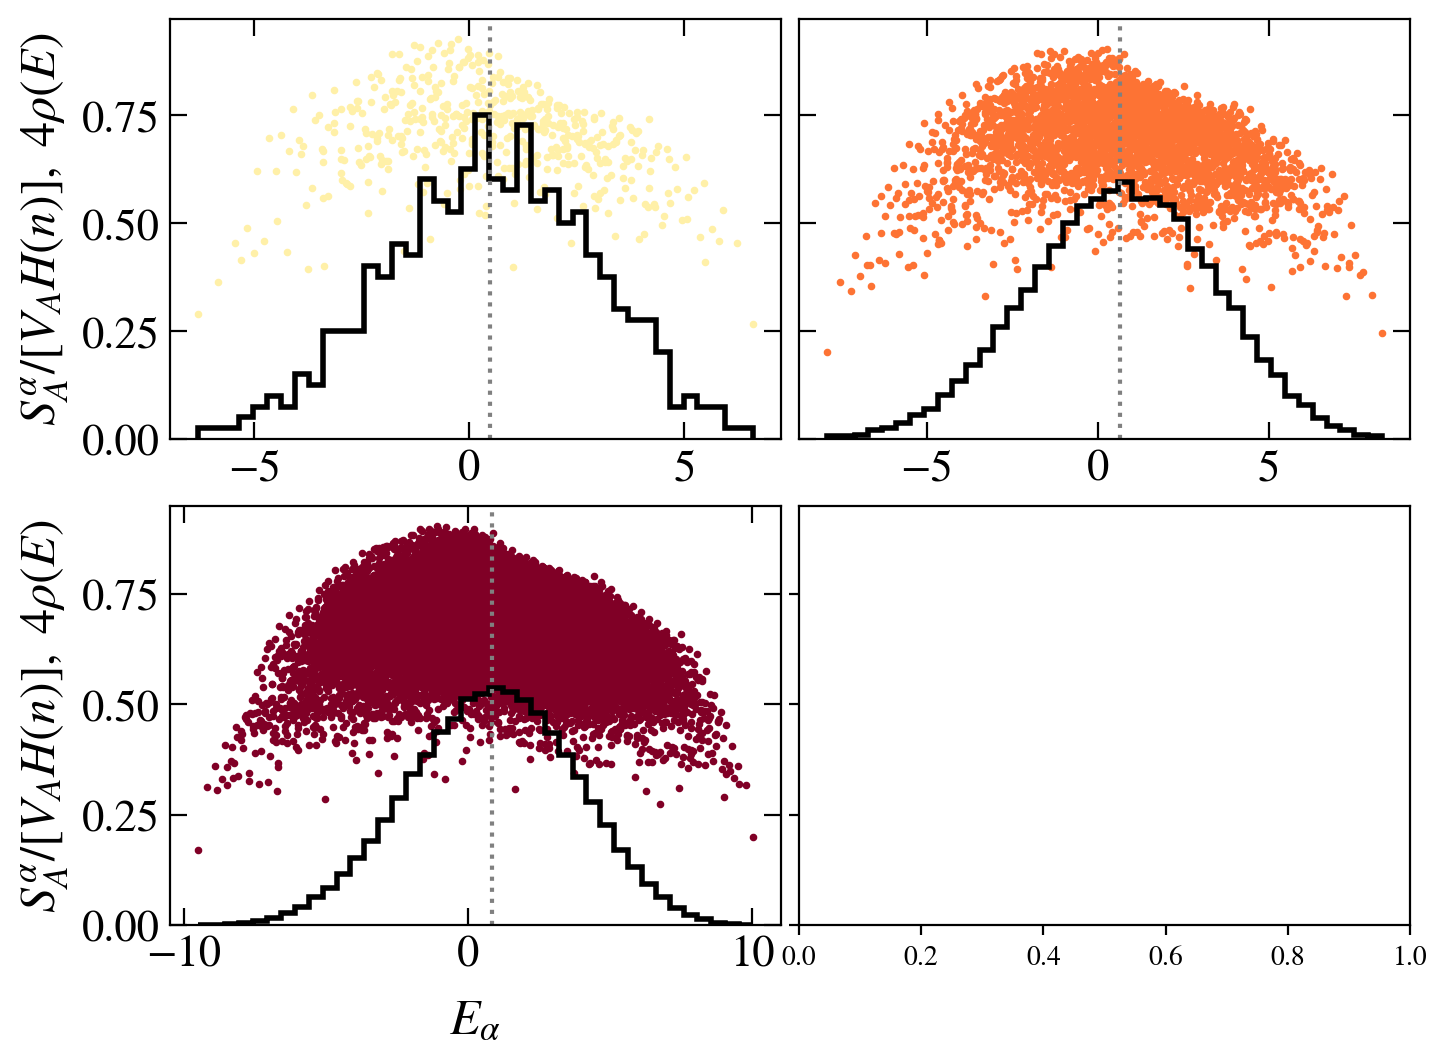

In [109]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

LOG = 0
INTEGRABLE = 1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(8,6), dpi = 200, sharex=False, sharey='row')

axis = axis.flatten()

f = 1
n = 1/3

sizes = np.arange(12, 19, 2) if n == 1/2 else np.arange(12, 20, 3)
norm = matplotlib.colors.Normalize(
            vmin=min(sizes),
            vmax=max(sizes))


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])
BOUNDARY_COND = 'ABC'


term1 = n * np.log(n)
term2 = (1-n) * np.log(1-n)

Hn = - term1 - term2
for iiL, L in enumerate(sizes):
    col = s_m_L.to_rgba(L)
    subsystem = np.arange(0, L, 1)
    N = int(n * L)
    f = n
    LA = int(f * L) if f > 0 else 1
    idx = np.argmin( np.abs(subsystem - LA) )
    if LA == L: idx = -1
    
    V1 = 0.55
    t2 = 0 if INTEGRABLE else 2
    V2 = 0 if INTEGRABLE else 2
    name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energies')[0])
            # Ex = (Ex - np.mean(Ex))
            # Ex = Ex / np.std(Ex)
            # Ex = (Ex - Ex[0]) / (Ex[-1] - Ex[0])
            hist, bins = np.histogram(Ex, bins=40, density=True)
            axis[iiL].stairs(4 * hist, bins, color='k', lw=2)
            
            Svn = np.array(file.get('entropy')[idx, :]) / (LA)
            if LOG: Svn = Hn - Svn
            else:   Svn = Svn / Hn
            axis[iiL].scatter(Ex, Svn, color = col, s=3, rasterized=True)
            axis[iiL].axvline(x = np.mean(Ex), ls=':', color='gray')
    else:
        print(name)
    
    ylab = r"$H(n) - {S}^\alpha_A$" if LOG else r"${S}^\alpha_A/[V_AH(n)],\ 4\rho(E)$"
    fig_help.set_plot_elements(axis[iiL], ylabel="" if iiL%2 else ylab, xlabel=r"$E_\alpha$" if iiL > 1 else "", font_size=16, set_legend=True, xscale='linear', yscale='log' if LOG else 'linear')
    # axis[iiL].set_xlim(0, 1)
    # axis[iiL].set_ylim(None, 1)

    # if iin: 
    #     z = np.linspace(0, 1,1000)
    #     # axis.plot(z, (2*z - 1)**2, color='blue', ls='--', lw=2)
    #     # axis2.plot(z, (2*z - 1)**2, color='blue', ls='--', lw=2)
    #     axis.axhline(y=(2*n-1)**2, ls='--', color='k')
    #     axis2.axhline(y=(2*n-1)**2, ls='--', color='k')
# axa[0][0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
# axa[0][1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
# axa[1][0].annotate(r"(c) $n=\frac{1}{2}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')
# axa[1][1].annotate(r"(d) $n=\frac{1}{3}$", fontsize=17, xy=(0.05, 0.05), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.03, hspace=0.16)
# fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

12 92 924
14 343 3432
16 1000 12870
18 1000 48620
20 1000 1000
22 1000 1000
24 1000 1000
12 49 495
15 300 3003
18 1000 18564
21 1000 2000
24 1000 1000
27 1000 1000


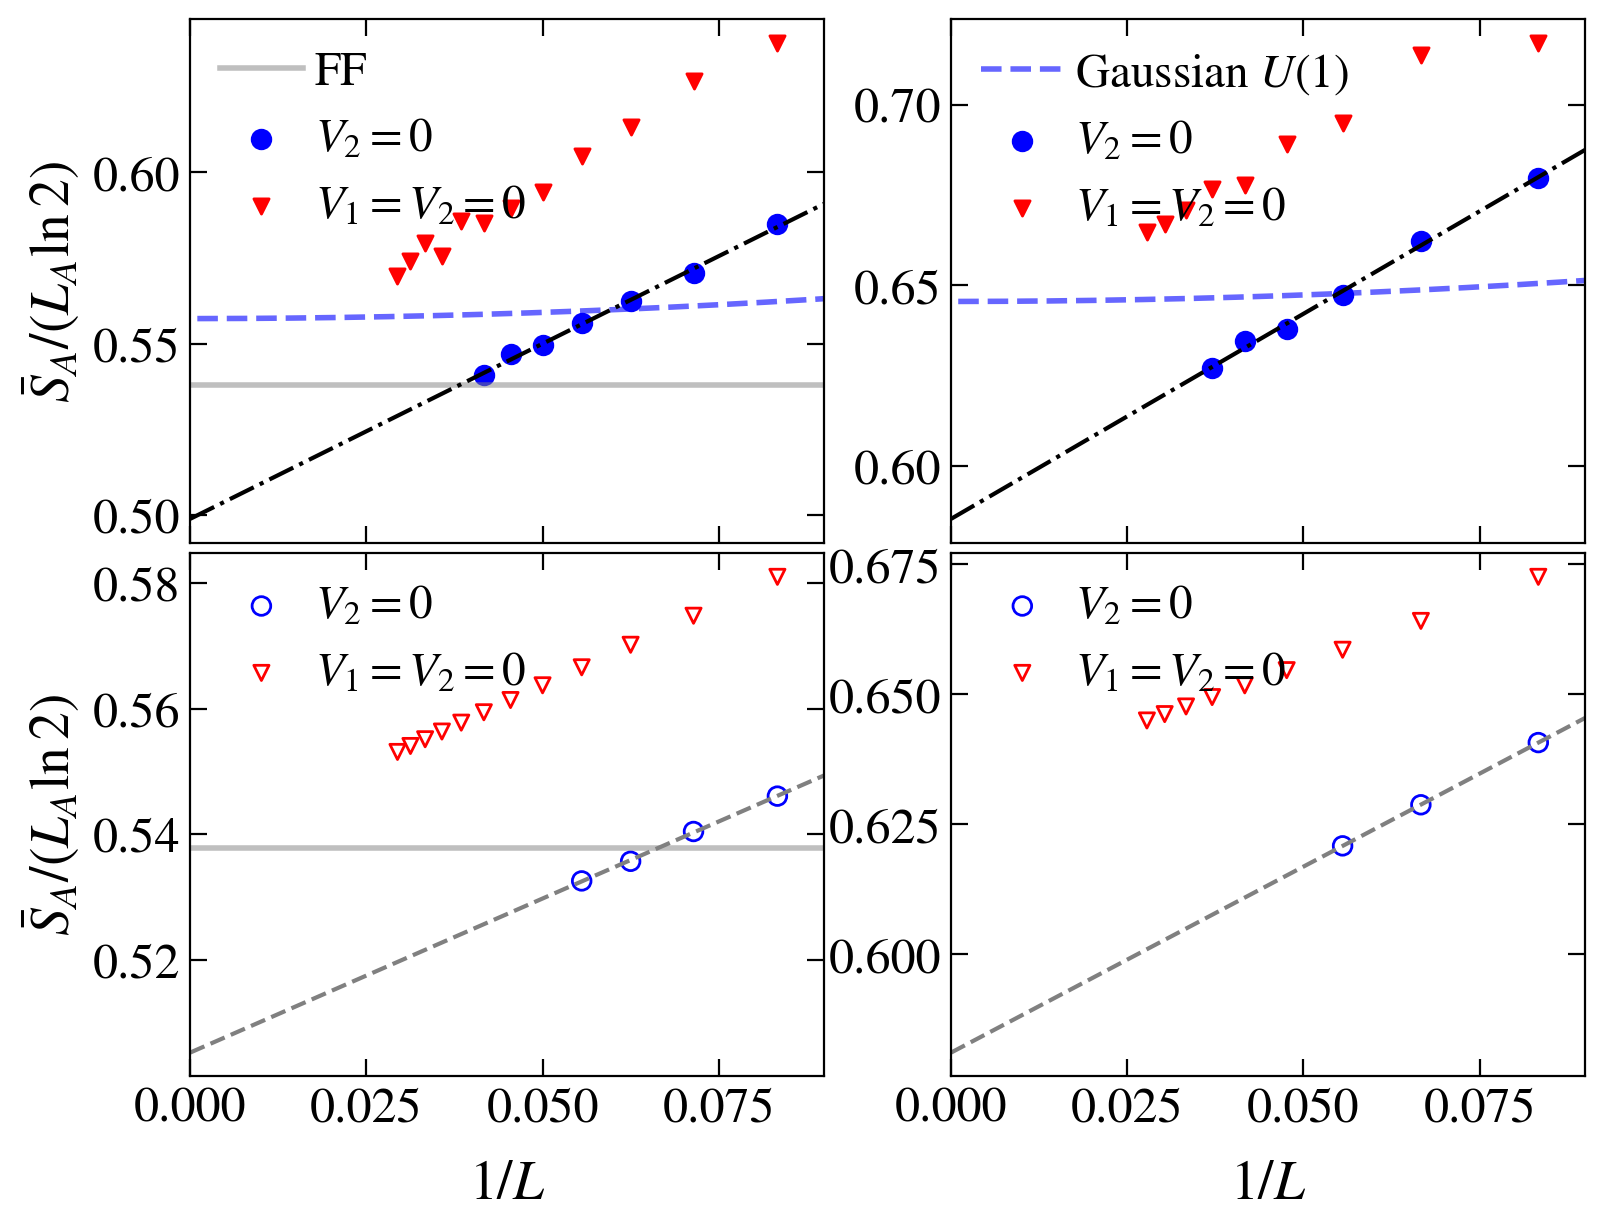

In [296]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(9,7), dpi = 200, sharex=True)
# axis = [ax]

BOUNDARY_COND = 'ABC'
n = 1/2

for iin, n in enumerate([1/2, 1/3]):
        
    handles1 = []
    handles2 = []
    if iin==0:
        line = axis[0][0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF")
        handles1.append(line)
        line = axis[1][0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF")
        
    z = np.linspace(1e-3, 0.1, 1000)
    Lz = 1/z
    yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * np.log(2))
    line, = axis[0][iin].plot(z, yy, ls='--', color='blue', lw=2, alpha=0.6, label="" if iin==0 else r"Gaussian $U(1)$")
    # axis[iin].plot(z, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * np.log(2)) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$" if iin else "")
    handles1.append(line)
    
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    sizes2 = np.arange(12, 35, 2) if n == 1/2 else np.arange(12, 37, 3)

    Svn_int = np.zeros(sizes.shape);    Svn_int.fill(np.nan)
    Svn_int_full = np.zeros(sizes.shape);   Svn_int_full.fill(np.nan)
    
    Svn_FF = np.zeros(sizes2.shape);     Svn_FF.fill(np.nan)
    Svn_FF_full = np.zeros(sizes2.shape);    Svn_FF_full.fill(np.nan)
    
    Svn_FF_bound = np.zeros(sizes2.shape);          Svn_FF_bound.fill(np.nan)
    Svn_FF_bound_full = np.zeros(sizes2.shape);     Svn_FF_bound_full.fill(np.nan)
    dims = np.zeros(sizes.shape)
    
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V2 = 0
        t2 = 0
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                dim = int(binom(L, N))
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                num = min([1000, dim//10])
                print(L, num, Ex.size)
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * np.log(2))
                if dim > 7e4 and Svn.size > 1000: Svn = Svn[500:-500]
                Svn_int[iiL] = np.mean(Svn) if dim > 7e4 else np.mean(Svn[idxE - num//2 : idxE + num//2])
                if L < 20: Svn_int_full[iiL] = np.mean(Svn)
        else:
            print(name)
            
    line1 = axis[0][iin].scatter(1/sizes, Svn_int, s=45, color='blue', marker='o', label = r"$V_2=0$")
    line2 = axis[1][iin].scatter(1/sizes, Svn_int_full, s=45, color='blue', marker='o', facecolor='None', label = r"$V_2=0$")
    # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')
    handles1.append(line1)
    handles2.append(line2)
    
    for iiL, L in enumerate(sizes2):
        subsystem = np.arange(0, L//2, 1)
        N = int(L * n)
        LA = int(n * L)
        if LA == L: idx = -1
        
        V2 = 0
        t2 = 0
        # name = '../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=0.5_N=%d.hdf5"%(L, N)
        # if not exists(name):
        name = '../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=1_N=%d.hdf5"%(L, N)
        if exists(name):
            with h5py.File(name, "r") as file:
                subsystem = np.array(file.get('VA')[0])
                
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(idx, LA, subsystem[idx])
                Svn_FF[iiL] = np.array(file.get('entropy_nu0')[0][idx]) / (LA * np.log(2))
                Svn_FF_full[iiL] = np.array(file.get('entropy')[0][idx]) / (LA * np.log(2))
        else:
            print(name)
            
        # name = '../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=0.5_N=%d.hdf5"%(L, N)
        # if not exists(name):
        name = '../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=1_N=%d.hdf5"%(L, N)
        if exists(name):
            with h5py.File(name, "r") as file:
                subsystem = np.array(file.get('VA')[0])
                
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(idx, LA, subsystem[idx])
                Svn_FF_bound[iiL] = np.array(file.get('entropy_nu0')[0][idx]) / (LA * np.log(2))
                Svn_FF_bound_full[iiL] = np.array(file.get('entropy')[0][idx]) / (LA * np.log(2))
        else:
            print(name)
    # line1 = axis[0][iin].scatter(1/sizes2, Svn_FF, s=15, color='green', marker='s', label = r"FF OBC")
    # line2 = axis[1][iin].scatter(1/sizes2, Svn_FF_full, s=15, color='green', marker='s', facecolor='None', label = r"FF OBC")
    # # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')
    # handles1.append(line1)
    # handles2.append(line2)
    line1 = axis[0][iin].scatter(1/sizes2, Svn_FF_bound, s=30, color='red', marker='v', label = r"$V_1=V_2=0$")
    line2 = axis[1][iin].scatter(1/sizes2, Svn_FF_bound_full, s=30, color='red', marker='v', facecolor='None', label = r"$V_1=V_2=0$")
    handles1.append(line1)
    handles2.append(line2)
    # p = axis[iin].scatter(1/sizes, Svn_ch, s=10, label='Chaotic' if iin==0 else "", color='red', marker='o')#'s' if iin else 'o')#, facecolor='None' if iin else 'red')
    # axis.scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')

    def fit_S(L: float, a: int, b: int):
        return a + b / L

    pars, pconv, fit_info, msg, _ = fit(fit_S,
                            xdata = sizes[~np.isnan(Svn_int)],
                            ydata = Svn_int[~np.isnan(Svn_int)],
                            full_output=True, maxfev=10000)
    # print("Int", *pars)
    xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[0][iin].plot( xx, fit_S(1/xx, *pars), ls='-.',  color = 'k')
    pars, pconv, fit_info, msg, _ = fit(fit_S,
                            xdata = sizes[~np.isnan(Svn_int_full)],
                            ydata = Svn_int_full[~np.isnan(Svn_int_full)],
                            full_output=True, maxfev=10000)
    # print("Int", *pars)
    xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[1][iin].plot( xx, fit_S(1/xx, *pars), ls='--',  color = 'gray')
    
    fig_help.set_plot_elements(axis[0][iin], ylabel=r"$\bar{S}_A/(L_A\ln{2})$" if iin==0 else "", xlabel=r"", font_size=18, set_legend=True, xlim=(0.0,0.09), xscale='linear', yscale='linear')
    fig_help.set_plot_elements(axis[1][iin], ylabel=r"$\bar{S}_A/(L_A\ln{2})$" if iin==0 else "", xlabel=r"$1/L$", font_size=18, set_legend=True, xlim=(0.0,0.09), xscale='linear', yscale='linear')
    # axis[iin].set_ylim(0.94 * min(yy[~np.isnan(yy)]), 1)
    # axis[iin].set_ylim(0.45, None)
# axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")


    # leg = fig_help.set_legend(axis[0][iin], fontsize=14, loc='lower right', handles=handles[1:-1])
    fig_help.set_legend(axis[0][iin], fontsize=17, loc='upper left', handles=handles1)
    fig_help.set_legend(axis[1][iin], fontsize=17, loc='upper left', handles=handles2)
    # fig.add_artist(leg)
# fig_help.set_legend(axis[1], fontsize=14, loc='lower right')

# axis[0].annotate(r"(a) $n=f=\frac{1}{2}$", fontsize=16, xy=(0.04, 0.88), xycoords='axes fraction')
# axis[1].annotate(r"(b) $n=f=\frac{1}{3}$", fontsize=16, xy=(0.04, 0.88), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.2, hspace=0.02)

fig.savefig("plots_mixing/FigA2.pdf", bbox_inches = 'tight', pad_inches=0.02)

INtEGRable 0.5 0.4988044498717731 0.001715653625428116 0.5051864233565041 0.0006483883431454119
FerMioNs 0.5 0.533752423482244 0.002162752132531997 0.5378718801158673 1.4509510734909132e-05 0.5170558257251253
INtEGRable 0.3333333333333333 0.6373883577020942 0.0023406496282272955 0.6327745277335123 0.00013907231465790803
FerMioNs 0.3333333333333333 0.6940566922022224 0.004231697365365719 0.6872144131921525 9.176635099691498e-05 0.5405675216029616


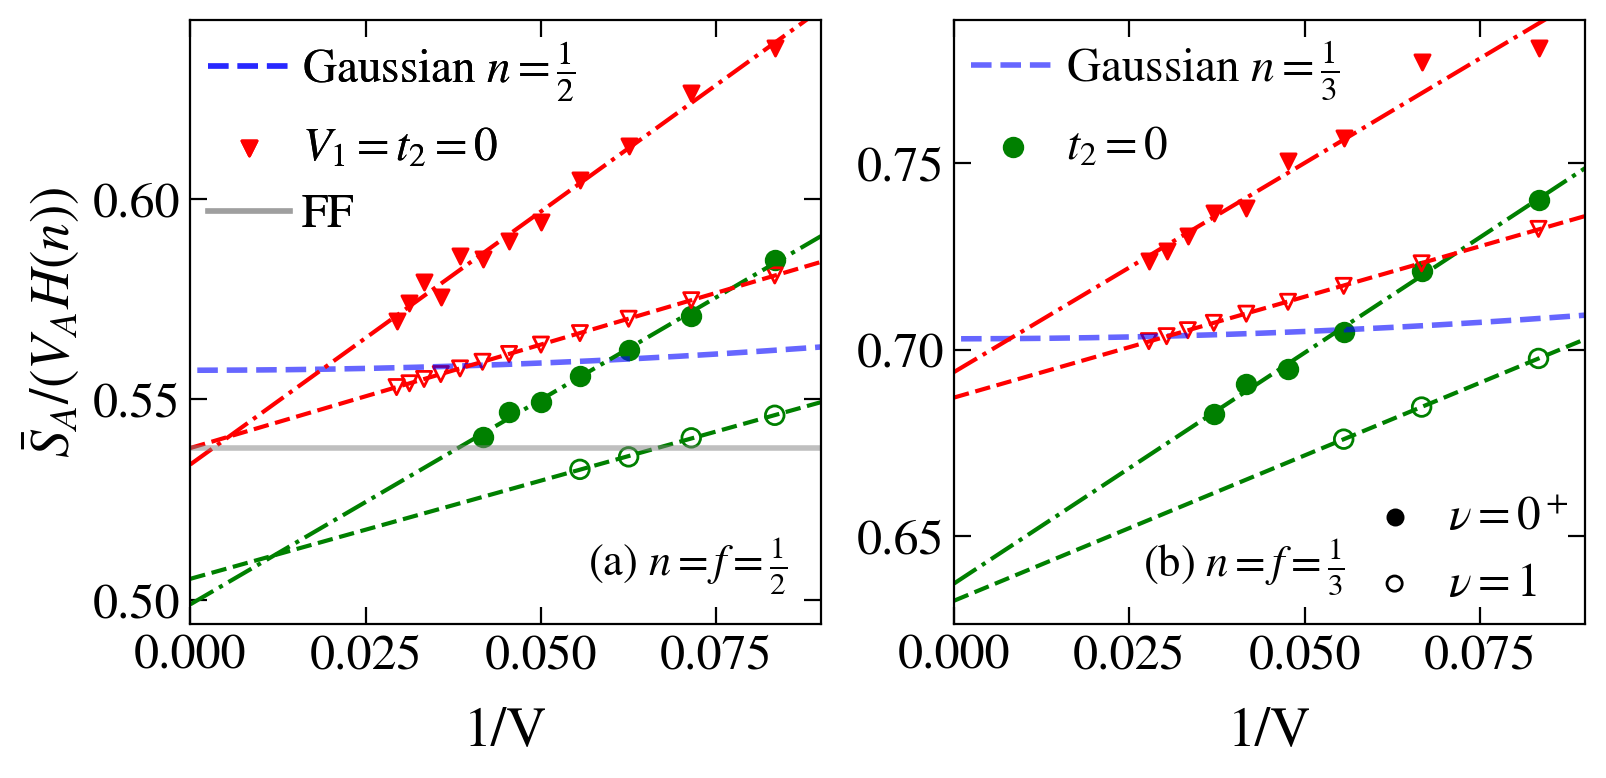

In [115]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(9,4), dpi = 200, sharex=True)
# axis = [ax]

BOUNDARY_COND = 'ABC'
n = 1/2

for iin, n in enumerate([1/2, 1/3]):
    Hn = -(n) * np.log(n) - (1-n) * np.log(1-n)
    
    handles1 = []
    handles2 = []
    z = np.linspace(1e-3, 0.1, 1000)
    Lz = 1/z
    yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * Hn)
    line, = axis[iin].plot(z, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $n=\frac{1}{2}$" if iin==0 else r"Gaussian $n=\frac{1}{3}$")
    # axis[iin].plot(z, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * np.log(2)) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$" if iin else "")
    handles1.append(line)
    
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)
    sizes2 = np.arange(12, 35, 2) if n == 1/2 else np.arange(12, 37, 3)

    Svn_int = np.zeros(sizes.shape);    Svn_int.fill(np.nan)
    Svn_int2 = np.zeros(sizes.shape);    Svn_int2.fill(np.nan)
    Svn_int_full = np.zeros(sizes.shape);   Svn_int_full.fill(np.nan)
    
    Svn_FF = np.zeros(sizes2.shape);     Svn_FF.fill(np.nan)
    Svn_FF_full = np.zeros(sizes2.shape);    Svn_FF_full.fill(np.nan)
    
    Svn_FF_bound = np.zeros(sizes2.shape);          Svn_FF_bound.fill(np.nan)
    Svn_FF_bound_full = np.zeros(sizes2.shape);     Svn_FF_bound_full.fill(np.nan)
    dims = np.zeros(sizes.shape)
    
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V2 = 0
        t2 = 0
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Svn = np.array(file.get('entropy')[idx, :]) / (LA * Hn)
                
                dim = int(binom(L, N))
                dims[iiL] = binom(L, N)
                E_av = np.mean(Ex)
                idxE = np.argmin(np.abs(Ex - E_av))
                idxE2 = np.argmax(Svn)
                
                num = min([1000, dim//10])
                # print(L, num, Ex.size)
                if dim > 7e4 and Svn.size > 1000: Svn = Svn[500:-500]
                Svn_int[iiL] = np.mean(Svn) if dim > 7e4 else np.mean(Svn[idxE - num//2 : idxE + num//2])
                Svn_int2[iiL] = np.mean(Svn) if dim > 7e4 else np.mean(Svn[idxE2 - num//2 : idxE + num//2])
                
                if L < 20: Svn_int_full[iiL] = np.mean(Svn)
        else:
            print(name)
            
    line1 = axis[iin].scatter(1/sizes, Svn_int, s=45, color='green', marker='o', label = r"$t_2=0$" if iin else "")
    # axis[iin].scatter(1/sizes, Svn_int2, s=45, color='green', marker='s', facecolor='None')
    line2 = axis[iin].scatter(1/sizes, Svn_int_full, s=45, color='green', marker='o', facecolor='None', label = r"$t_2=0$")
    # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')
    handles1.append(line1)
    # handles2.append(line2)
    
    for iiL, L in enumerate(sizes2):
        subsystem = np.arange(0, L//2, 1)
        N = int(L * n)
        LA = int(n * L)
        if LA == L: idx = -1
        
        V2 = 0
        t2 = 0
        # name = '../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=0.5_N=%d.hdf5"%(L, N)
        # if not exists(name):
        name = '../../Quadratic/results/FreeFermions/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=1_N=%d.hdf5"%(L, N)
        if exists(name):
            with h5py.File(name, "r") as file:
                subsystem = np.array(file.get('VA')[0])
                
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(idx, LA, subsystem[idx])
                Svn_FF[iiL] = np.array(file.get('entropy_nu0')[0][idx]) / (LA * Hn)
                Svn_FF_full[iiL] = np.array(file.get('entropy')[0][idx]) / (LA * Hn)
        else:
            print(name)
            
        # name = '../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=0.5_N=%d.hdf5"%(L, N)
        # if not exists(name):
        name = '../../Quadratic/results/FreeFermions_BOUNDARY/dim=1/OBC/Entropy/Eigenstate/AllStates/realisation=0/' + "_L=%d,J=1_N=%d.hdf5"%(L, N)
        if exists(name):
            with h5py.File(name, "r") as file:
                subsystem = np.array(file.get('VA')[0])
                
                idx = np.argmin( np.abs(subsystem - LA) )
                # print(idx, LA, subsystem[idx])
                Svn_FF_bound[iiL] = np.array(file.get('entropy_nu0')[0][idx]) / (LA * Hn)
                Svn_FF_bound_full[iiL] = np.array(file.get('entropy')[0][idx]) / (LA * Hn)
        else:
            print(name)
    # line1 = axis[0][iin].scatter(1/sizes2, Svn_FF, s=15, color='green', marker='s', label = r"FF OBC")
    # line2 = axis[1][iin].scatter(1/sizes2, Svn_FF_full, s=15, color='green', marker='s', facecolor='None', label = r"FF OBC")
    # # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')
    # handles1.append(line1)
    # handles2.append(line2)
    line1 = axis[iin].scatter(1/sizes2, Svn_FF_bound, s=30, color='red', marker='v', label = "" if iin else r"$V_1=t_2=0$")
    line2 = axis[iin].scatter(1/sizes2, Svn_FF_bound_full, s=30, color='red', marker='v', facecolor='None', label = r"$V_1=t_2=0$")
    handles1.append(line1)
    # handles2.append(line2)
    # p = axis[iin].scatter(1/sizes, Svn_ch, s=10, label='Chaotic' if iin==0 else "", color='red', marker='o')#'s' if iin else 'o')#, facecolor='None' if iin else 'red')
    # axis.scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')

    def fit_S(L: float, a: int, b: int):
        return a + b / L

    pars, pconv, fit_info, msg, _ = fit(fit_S,
                            xdata = sizes[~np.isnan(Svn_int)],
                            ydata = Svn_int[~np.isnan(Svn_int)],
                            full_output=True, maxfev=10000)
    # print("Int", *pars)
    a1 = pars[0]
    a1_err = np.sqrt(np.diag(pconv))[0]
    xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[iin].plot( xx, fit_S(1/xx, *pars), ls='-.',  color = 'green')
    pars, pconv, fit_info, msg, _ = fit(fit_S,
                            xdata = sizes[~np.isnan(Svn_int_full)],
                            ydata = Svn_int_full[~np.isnan(Svn_int_full)],
                            full_output=True, maxfev=10000)
    # print("Int", *pars)
    a2 = pars[0]
    a2_err = np.sqrt(np.diag(pconv))[0]
    xx = np.linspace(0, max(1/(sizes-1)), 10000)
    axis[iin].plot( xx, fit_S(1/xx, *pars), ls='--',  color = 'green')
    
    print("INtEGRable", n, a1, a1_err, a2, a2_err)
    
    # def fit_S(L: float, a: int, b: int):
    #     return a + n / L + (4*n - 6*n**2) / 30 / L**2
    
    axis[iin].set_ylim(0.99*min([a1, a2]), None)
    
    pars, pconv, fit_info, msg, _ = fit(fit_S,
                            xdata = sizes2[~np.isnan(Svn_FF_bound)],
                            ydata = Svn_FF_bound[~np.isnan(Svn_FF_bound)],
                            full_output=True, maxfev=10000)
    # print("Int", *pars)
    a1 = pars[0]
    a1_err = np.sqrt(np.diag(pconv))[0]
    xx = np.linspace(0, max(1/(sizes2-1)), 10000)
    axis[iin].plot( xx, fit_S(1/xx, *pars), ls='-.',  color = 'red')
    pars, pconv, fit_info, msg, _ = fit(fit_S,
                            xdata = sizes2[~np.isnan(Svn_FF_bound_full)],
                            ydata = Svn_FF_bound_full[~np.isnan(Svn_FF_bound_full)],
                            full_output=True, maxfev=10000)
    # print("Int", *pars)
    a2 = pars[0]
    a2_err = np.sqrt(np.diag(pconv))[0]
    xx = np.linspace(0, max(1/(sizes2-1)), 10000)
    axis[iin].plot( xx, fit_S(1/xx, *pars), ls='--',  color = 'red')
    
    print("FerMioNs", n, a1, a1_err, a2, a2_err, pars[1])
    if iin==0:
        line = axis[0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF")
        handles1.append(line)
        # line = axis[1][0].axhline(y = 0.5378, color='gray', lw=2, alpha=0.5, label=r"FF")
        
    fig_help.set_plot_elements(axis[iin], ylabel=r"$\bar{S}_A/(V_A H(n))$" if iin==0 else "", xlabel=r"1/V", font_size=18, set_legend=True, xlim=(0.0,0.09), xscale='linear', yscale='linear')
    
    # fig_help.set_plot_elements(axis[1][iin], ylabel=r"$\bar{S}_A/(L_A\ln{2})$" if iin==0 else "", xlabel=r"$1/L$", font_size=18, set_legend=True, xlim=(0.0,0.09), xscale='linear', yscale='linear')
    # axis[iin].set_ylim(0.94 * min(yy[~np.isnan(yy)]), 1)
    # axis[iin].set_ylim(0.45, None)
# axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")


    # leg = fig_help.set_legend(axis[0][iin], fontsize=14, loc='lower right', handles=handles[1:-1])
    leg = fig_help.set_legend(axis[iin], fontsize=17, loc='upper left', handles = handles1, anchor=(-0.04, 1.04))
    # fig_help.set_legend(axis[1][iin], fontsize=17, loc='upper left', handles=handles2)
    fig.add_artist(leg)
# fig_help.set_legend(axis[1], fontsize=14, loc='lower right')

line1 = axis[iin].scatter(np.nan, np.nan, s=30, color='k', marker='o', label = r"$\nu=0^+$")
line2 = axis[iin].scatter(np.nan, np.nan, s=30, color='k', marker='o', facecolor='None', label = r"$\nu=1$")
handles2.append(line1)
handles2.append(line2)
fig_help.set_legend(axis[1], fontsize=17, loc='lower right', handles = handles2, anchor=(1.04, -0.04))

axis[0].annotate(r"(a) $n=f=\frac{1}{2}$", fontsize=16, xy=(0.63, 0.08), xycoords='axes fraction')
axis[1].annotate(r"(b) $n=f=\frac{1}{3}$", fontsize=16, xy=(0.3, 0.08), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.21, hspace=0.02)

fig.savefig("plots_mixing/FigA2.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [11]:
binom(27,9) / binom(26, 13)

0.45063025210084034

INT 18 0.38949690360388994
CH 18 0.5326847160057013


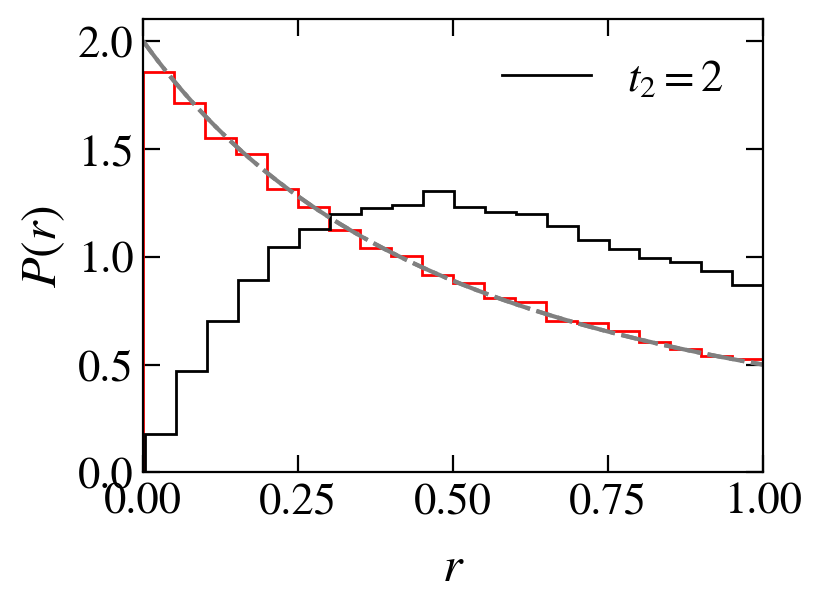

In [30]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True)
# ax2 = ax.inset_axes([0.065, 0.04, 0.49, 0.49])
# axis = [ax2, ax]

n = 1/2
f = 1
sizes = np.arange(12, 19, 2) if n == 1/2 else np.arange(12, 20, 3)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

BOUNDARY_COND = 'ABC'

L=18
# for iiL, L in enumerate(sizes):
col = s_m.to_rgba(L)
subsystem = np.arange(0, L, 1)
N = int(n * L)
LA = int(f * L) if f > 0 else 1
idx = np.argmin( np.abs(subsystem - LA) )
if LA == L: idx = -1

V1 = 0.55
V2 = 0
t2 = 0

name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energies')[0])
        gaps = np.diff(Ex)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        hist, bins = np.histogram(ratio_tmp, bins=20, density=True)
        axis.stairs(hist, bins, color='red')
        # axis.scatter((bins[1:] + bins[:-1])/2, hist, color='blue', s=5, marker='o')
        print('INT', L, np.mean(ratio_tmp))
        
else:
    print(name)
V1=0.55
V2 = 2
t2 = 2
name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energies')[0])
        gaps = np.diff(Ex)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        hist, bins = np.histogram(ratio_tmp, bins=20, density=True)
        axis.stairs(hist, bins, color='k', label=r"$t_2=2$")
        # axis.scatter((bins[1:] + bins[:-1])/2, hist, color='k', s=10, marker='s', facecolor='None')
        # axis[1].scatter(Ex[1:-1] / L, ratio_tmp, color=col, s=2)
        print('CH', L, np.mean(ratio_tmp))
else:
    print(name)

z = np.linspace(0,1,1000)
axis.plot(z, 2/(1+z)**2, ls='--', color='gray')
axis.plot(z, 2/(1+z)**2, ls='-.', color='gray')
# fig_help.set_plot_elements(axis[0], ylabel=r"$P(r)$", xlabel=r"", font_size=16, set_legend=True, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis, ylabel=r"$P(r)$", xlabel=r"$r$", font_size=16, set_legend=True, xscale='linear', yscale='linear', xlim=(0,1))
# fig_help.set_legend(axis, fontsize=16, loc = 'upper right', ncol=1, columnspacing=0.4, frameon=False, anchor=(1.02, 0.93))


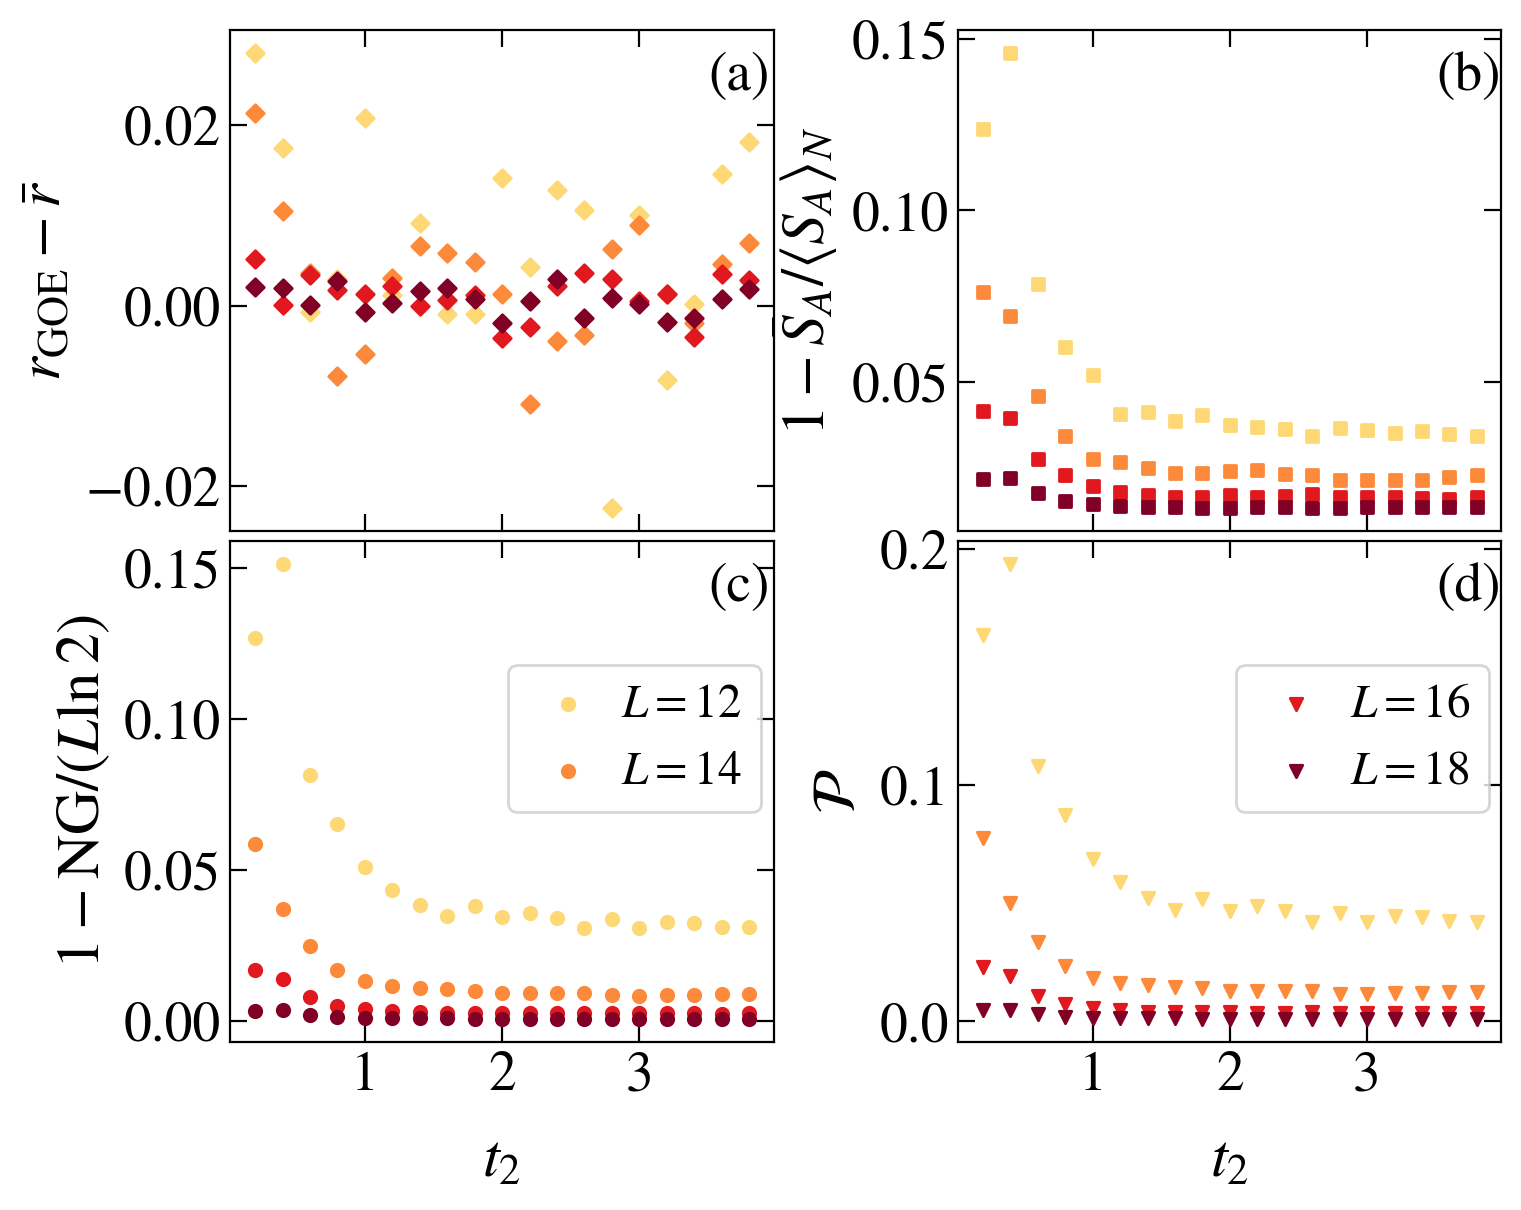

In [294]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(8.2,6.7), dpi = 200, sharex=True)
axis = axis.flatten()

L = 20

BOUNDARY_COND = 'ABC'

sizes = np.arange(12, 19, 2)
norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.25, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

for sth in range(0, 1):
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L) if sizes.size > 1 else 'k'
        
        N = L//2
        LA = L//2

        subsystem = np.arange(0, L, 1)
        idx_LA = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx_LA = -1
                
        t2_vals = np.arange(0.2, 4, 0.2)
        Svn = np.zeros(t2_vals.shape)
        NG = np.zeros(t2_vals.shape)
        P = np.zeros(t2_vals.shape)
        r = np.zeros(t2_vals.shape)
            
        for iit, t2 in enumerate(t2_vals):
            V2 = 0.55*t2 if sth else t2
            
            name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        print(L, t2)
                    else:
                        Eav = np.mean(Ex)
                        idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                        num = int(min([dim//10, 500]))
                        
                        # print(np.array(file.get('entropy')).shape, np.array(file.get('entropy'))[-1].shape, np.array(file.get('Non-Gaussianity')[0]).shape, np.array(file.get('Purity')[-1]).shape, idx - num//2, idx + num//2)
                        Svn[iit] = np.mean(np.array(file.get('entropy')[idx_LA][idx - num//2 : idx + num//2])) / ent.page_U1(LA, L - LA, N)
                        NG[iit] = np.mean(np.array(file.get('Non-Gaussianity')[0])[idx - num//2 : idx + num//2]) / (L * np.log(2))
                        P[iit] = np.mean(np.array(file.get('Purity')[-1][idx - num//2 : idx + num//2])) / L
                        
                        
                        gaps = np.diff(Ex)
                        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                        r[iit] = np.mean(ratio_tmp)
            else:
                print(name)
            
        axis[1].scatter(t2_vals, 1 - Svn,    s=20, color=col, facecolor = 'None' if sth else col, marker='s')
        axis[2].scatter(t2_vals, 1 - NG,     s=20, color=col, facecolor = 'None' if sth else col, marker='o', label=r"$L=%d$"%L if L < 16 else "")
        axis[3].scatter(t2_vals, P,          s=20, color=col, facecolor = 'None' if sth else col, marker='v', label=r"$L=%d$"%L if L > 14 else "")
        axis[0].scatter(t2_vals, 0.5307 - r, s=20, color=col, facecolor = 'None' if sth else col, marker='D')

fig_help.set_plot_elements(axis[1], ylabel=r"$1-\bar{S}_A/\langle S_A\rangle_N$", xlabel="", font_size=20, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[2], ylabel=r"$1-{\rm NG}/(L\ln{2})$", xlabel=r"$t_2$", font_size=20, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[3], ylabel=r"$\mathcal{P}$", xlabel=r"$t_2$", font_size=20, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_plot_elements(axis[0], ylabel=r"$r_{\rm GOE}-\bar{r}$", xlabel=r"$t_2$", font_size=20, set_legend=False, xscale='linear', yscale='linear')

fig_help.set_legend(axis[2], fontsize=17, loc = 'upper right', ncol=1, columnspacing=0.4, frameon=True, anchor=(1.02, 0.8))
fig_help.set_legend(axis[3], fontsize=17, loc = 'upper right', ncol=1, columnspacing=0.4, frameon=True, anchor=(1.02, 0.8))
axis[0].annotate(r"(a)", fontsize=20, xy=(0.88, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=20, xy=(0.88, 0.88), xycoords='axes fraction')
axis[2].annotate(r"(c)", fontsize=20, xy=(0.88, 0.88), xycoords='axes fraction')
axis[3].annotate(r"(d)", fontsize=20, xy=(0.88, 0.88), xycoords='axes fraction')

# fig.subplots_adjust(right=0.95)
# cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
# cbar.set_label(r"$L$", fontsize=16)
# cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.34, hspace=0.02)
fig.savefig("plots_mixing/FigA1.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
name=ent
fun=1
dx=3
arr_end=0
arr_step=1

y=1.0
dim=1
model=0
ens=3

doSFF=0


sizes=(28 30 32 34 36 38 40 44 48 52) #dim = 2
cpus=(28 30 32 34 36 38 40 44 48 52)

Lmin=${sizes[0]}
dL=$(echo ${sizes[1]} ${sizes[0]} | awk '{printf "%d", ($1 - $2)}')

# sizes=(10)
#sizes=(6 7 8 9 10 11 12 13 14)
#sizes=(15 16 17 18)
#sizes=(15 16 17 18)

r=1 #for d=4 used r=100 for large sizes
for realis in {0..0}; do
 id=$(echo $r $realis | awk '{printf "%d", $1 * $2}') # 2nd try for d=3 jobid=2000 + ... # 2nd try for d=4 jobid=5000 + ...# 2nd try for d=5 jobid=10000 + ...
 time=$(echo $realis | awk '{printf "%d", 2 + ($1) * 2 }')
 random_num=$RANDOM
 for idx2 in "${!sizes[@]}"; do
      L=${sizes[$idx2]}
      idx=$(echo $L $Lmin $dL | awk '{printf "%d", ($1 - $2) / $3}')
      V=$(echo $L $dim | awk '{printf "%d",  $1**$2}')
      cpu=$(echo ${cpus[idx]}| awk '{printf "%d", 3*$1}')
      echo $L, $dim, $V, "RANDOM NUM = ", $random_num, "CPUS=", ${cpus[idx]}
      sbatch --job-name="${name}_d=${dim}_L=${L}" --output=logs/${name}_log-%A-%a.out --cpus-per-task=$cpu --mem-per-cpu=2000 --partition=cpu --time=2-00:00:00 --array=0-${arr_end}%${arr_step} runner_script.sh $L $dx $fun ${cpus[idx]} $random_num $id $y $dim 1 $model $ens
done
done

In [ ]:
for L in np.arange(28, 37, 2):
    dim = binom(L, L//2)
    print(L, dim, dim*8 / 1e9)
    
print("---------------------")
for L in np.arange(30, 43, 3):
    dim = binom(L, L//3)
    print(L, dim, dim*8 / 1e9)

28 40116600.0 0.3209328
30 155117520.0 1.24094016
32 601080390.0 4.80864312
34 2333606220.0 18.66884976
36 9075135300.0 72.6010824
---------------------
30 30045015.0 0.24036012
33 193536720.0 1.54829376
36 1251677700.0 10.0134216
39 8122425444.000001 64.97940355200001
42 52860229080.00001 422.8818326400001


Text(0.04, 0.88, '(b) $n=\\frac{1}{3}$')

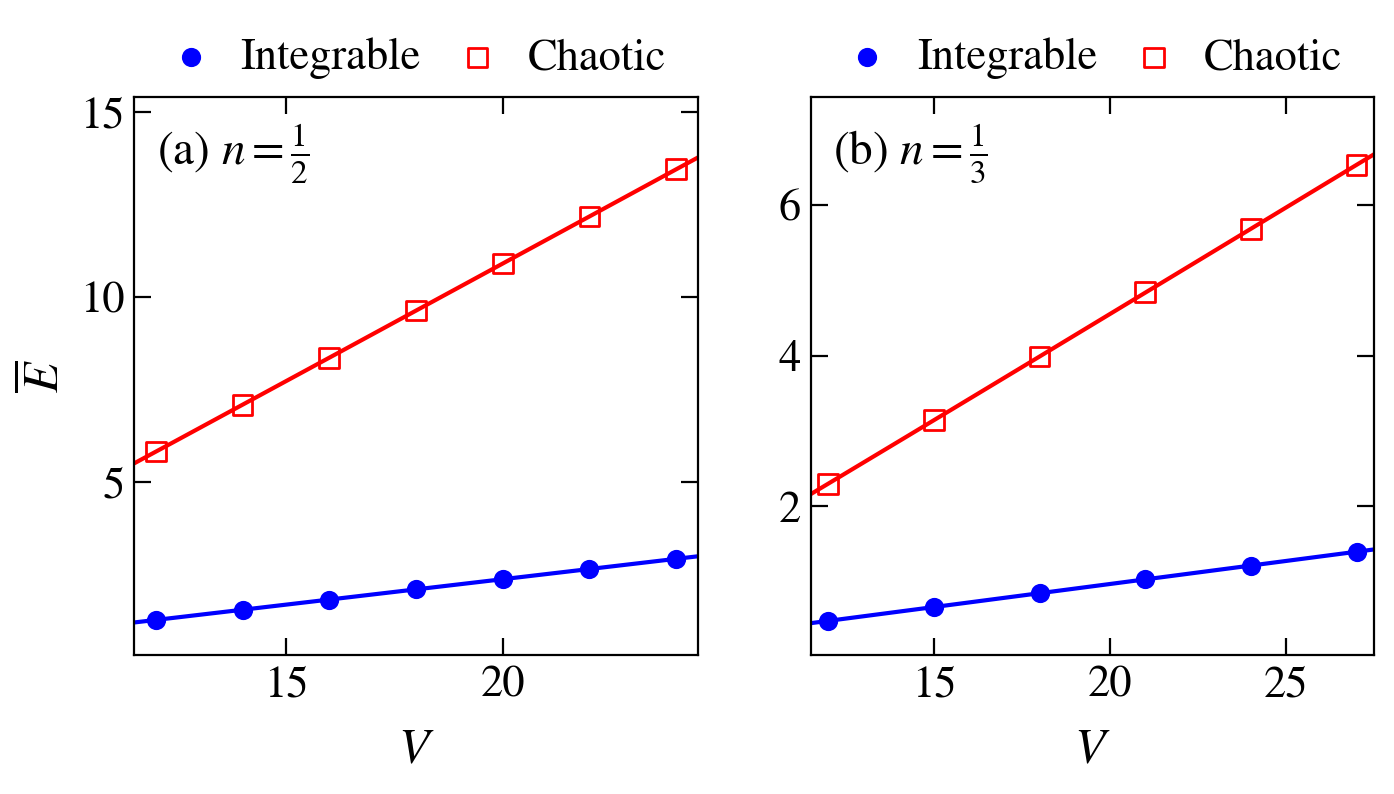

In [104]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

# fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)
fig, axa = plt.subplots( nrows=1, ncols=2, figsize=(8,3.7), dpi = 200, sharex=False)

for iin, n in enumerate([1/2, 1/3]):
    axis = axa[iin]

    f = 1
    sizes = np.arange(12, 25, 2) if n == 1/2 else np.arange(12, 28, 3)

    Eav_int = np.zeros(sizes.shape)
    Eav_ch = np.zeros(sizes.shape)

    dims = np.zeros(sizes.shape)
    BOUNDARY_COND = 'ABC'

    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(n * L)
        LA = int(f * L) if f > 0 else 1
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Eav_int[iiL] = np.mean(Ex)
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = "../results/" + BOUNDARY_COND + '/' + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                Eav_ch[iiL] = np.mean(Ex)
        else:
            print(name)
        
    Chaotic_GOE = 9 / (2 + dims/4)
    Chaotic_GUE = 4 / (1 + dims/4)

    axis.scatter(sizes, Eav_int, s=35, color='blue', label='Integrable')
    axis.scatter(sizes, Eav_ch, s=50, color='red', label='Chaotic', marker='s', facecolor='None')

    def prediction(L, N, V1, V2):
        return -0.2 * N / L + V1 * N * (N-1) / L + V2 * N * (N-1) / (L * (L-1)) * (L-2)
    
    x = np.linspace(min(sizes)-2, max(sizes)+2, 1000)
    axis.plot(x, prediction(x, x*n, V1, 0), color='blue')
    axis.plot(x, prediction(x, x*n, V1, 2), color='red')
    
    fig_help.set_plot_elements(axis, ylabel="" if iin else r"$\overline{E}$", xlabel=r"$V$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
    fig_help.set_legend(axis, fontsize=16, loc = 'lower left', ncol=2, columnspacing=0.4, frameon=False, anchor=(-.04, 0.96))
    axis.set_xlim(min(sizes)-0.5, max(sizes)+0.5)

    # axis.axhline(y = -0.2 * n + V1 * n, ls='--', color='gray')
    # axis.axhline(y = -0.2 * n + (V1 + 2*n) * n, ls=':', color='k')
axa[0].annotate(r"(a) $n=\frac{1}{2}$", fontsize=17, xy=(0.04, 0.88), xycoords='axes fraction')
axa[1].annotate(r"(b) $n=\frac{1}{3}$", fontsize=17, xy=(0.04, 0.88), xycoords='axes fraction')